In [ ]:
# ============================================================
# Google Drive의 real_emotion_dataset.zip
# → Colab 로컬로 복사
# → 압축 해제
# → train / val / test 경로 자동 설정
# ============================================================


# ============================================================
# 1. Google Drive 연결
# ============================================================

from google.colab import drive

drive.mount('/content/drive')


# ============================================================
# 2. 라이브러리
# ============================================================

import os
import shutil
import zipfile


# ============================================================
# 3. 경로 설정
# ============================================================

# Google Drive에 있는 원본 ZIP 파일
SOURCE_ZIP = "/content/drive/MyDrive/real_emotion_dataset.zip"

# Colab 로컬에 복사할 ZIP
LOCAL_ZIP = "/content/real_emotion_dataset.zip"

# 압축을 풀 위치
EXTRACT_DIR = "/content/real_emotion_dataset"


# ============================================================
# 4. ZIP 파일 존재 확인
# ============================================================

if not os.path.exists(SOURCE_ZIP):

    raise FileNotFoundError(
        f"ZIP 파일을 찾을 수 없습니다.\n"
        f"확인 경로: {SOURCE_ZIP}"
    )

print("ZIP 파일 확인 완료")
print("원본:", SOURCE_ZIP)


# ============================================================
# 5. Google Drive → Colab 로컬 복사
#
# Drive에서 직접 압축 해제하면
# Transport endpoint is not connected 오류가 발생할 수 있으므로
# 먼저 /content로 복사한다.
# ============================================================

print("\nZIP 파일을 Colab 로컬로 복사 중...")


# 이미 이전 실행에서 파일이 있다면 삭제
if os.path.exists(LOCAL_ZIP):
    os.remove(LOCAL_ZIP)


shutil.copy2(
    SOURCE_ZIP,
    LOCAL_ZIP
)


print("로컬 복사 완료")
print("복사 위치:", LOCAL_ZIP)


# ============================================================
# 6. 기존 압축 해제 폴더 삭제
#
# Notebook을 다시 실행했을 때
# 기존 파일과 섞이는 것을 방지한다.
# ============================================================

if os.path.exists(EXTRACT_DIR):

    print("\n기존 압축 해제 폴더 삭제 중...")

    shutil.rmtree(EXTRACT_DIR)


os.makedirs(
    EXTRACT_DIR,
    exist_ok=True
)


# ============================================================
# 7. ZIP 압축 해제
# ============================================================

print("\nZIP 압축 해제 중...")


with zipfile.ZipFile(
    LOCAL_ZIP,
    "r"
) as zip_ref:

    zip_ref.extractall(
        EXTRACT_DIR
    )


print("압축 해제 완료")
print("압축 해제 위치:", EXTRACT_DIR)


# ============================================================
# 8. 압축 해제된 최상위 파일 확인
# ============================================================

print("\n압축 해제된 폴더:")

for item in os.listdir(EXTRACT_DIR):
    print(" -", item)


# ============================================================
# 9. 데이터셋 ROOT 자동 탐색
#
# ZIP 구조가
#
# real_emotion_dataset.zip
# └── train/
#
# 일 수도 있고
#
# real_emotion_dataset.zip
# └── real_emotion_dataset/
#     └── train/
#
# 형태일 수도 있기 때문에 자동 탐색한다.
# ============================================================


def find_dataset_root(base_dir):

    # --------------------------------------------------------
    # 경우 1
    #
    # /content/real_emotion_dataset/train
    # /content/real_emotion_dataset/val
    # /content/real_emotion_dataset/test
    # --------------------------------------------------------

    if (
        os.path.isdir(
            os.path.join(base_dir, "train")
        )
        and
        os.path.isdir(
            os.path.join(base_dir, "val")
        )
        and
        os.path.isdir(
            os.path.join(base_dir, "test")
        )
    ):

        return base_dir


    # --------------------------------------------------------
    # 경우 2
    #
    # 한 단계 안쪽에 dataset 폴더가 존재
    # --------------------------------------------------------

    for item in os.listdir(base_dir):

        candidate = os.path.join(
            base_dir,
            item
        )

        if not os.path.isdir(candidate):
            continue


        if (
            os.path.isdir(
                os.path.join(candidate, "train")
            )
            and
            os.path.isdir(
                os.path.join(candidate, "val")
            )
            and
            os.path.isdir(
                os.path.join(candidate, "test")
            )
        ):

            return candidate


    return None


# ============================================================
# 10. Dataset ROOT 찾기
# ============================================================

DATA_ROOT = find_dataset_root(
    EXTRACT_DIR
)


if DATA_ROOT is None:

    raise RuntimeError(
        "\ntrain / val / test 폴더를 찾을 수 없습니다.\n"
        "압축 파일 내부 구조를 확인해주세요."
    )


# ============================================================
# 11. Train / Validation / Test 경로 설정
# ============================================================

TRAIN_DIR = os.path.join(
    DATA_ROOT,
    "train"
)

VAL_DIR = os.path.join(
    DATA_ROOT,
    "val"
)

TEST_DIR = os.path.join(
    DATA_ROOT,
    "test"
)


print("\n============================================")
print("데이터셋 경로 설정 완료")
print("============================================")

print("DATA_ROOT :", DATA_ROOT)
print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)

Mounted at /content/drive
ZIP 파일 확인 완료
원본: /content/drive/MyDrive/real_emotion_dataset.zip

ZIP 파일을 Colab 로컬로 복사 중...
로컬 복사 완료
복사 위치: /content/real_emotion_dataset.zip

ZIP 압축 해제 중...
압축 해제 완료
압축 해제 위치: /content/real_emotion_dataset

압축 해제된 폴더:
 - real_emotion_dataset

데이터셋 경로 설정 완료
DATA_ROOT : /content/real_emotion_dataset/real_emotion_dataset
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test


In [ ]:
# ============================================================
# 12. 클래스 확인
# ============================================================

EXPECTED_CLASSES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


train_classes = sorted(
    [
        folder
        for folder in os.listdir(TRAIN_DIR)
        if os.path.isdir(
            os.path.join(
                TRAIN_DIR,
                folder
            )
        )
    ]
)


print("\nTrain 클래스:")
print(train_classes)


print("\n클래스 개수:")
print(len(train_classes))


if train_classes == EXPECTED_CLASSES:

    print("\n8개 클래스 정상 확인")

else:

    print("\n주의: 예상 클래스와 실제 클래스가 다릅니다.")

    print("예상:")
    print(EXPECTED_CLASSES)

    print("실제:")
    print(train_classes)


Train 클래스:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

클래스 개수:
8

8개 클래스 정상 확인


In [ ]:
# ============================================================
# 이미지 확장자 정의
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


# ============================================================
# 클래스별 이미지 수 확인 함수
# ============================================================

def print_class_counts(directory, dataset_name):

    print(
        f"\n========== {dataset_name} =========="
    )

    for class_name in sorted(
        os.listdir(directory)
    ):

        class_path = os.path.join(
            directory,
            class_name
        )

        # 폴더가 아닌 경우 제외
        if not os.path.isdir(class_path):
            continue


        image_count = len(
            [
                file
                for file in os.listdir(class_path)
                if file.lower().endswith(
                    IMAGE_EXTENSIONS
                )
            ]
        )


        print(
            f"{class_name:12s}: {image_count}"
        )


# ============================================================
# Train / Validation / Test 클래스별 이미지 수 출력
# ============================================================

print_class_counts(
    TRAIN_DIR,
    "TRAIN"
)

print_class_counts(
    VAL_DIR,
    "VALIDATION"
)

print_class_counts(
    TEST_DIR,
    "TEST"
)


========== TRAIN ==========
anger       : 1275
contempt    : 1283
disgust     : 1218
fear        : 1287
happy       : 1303
neutral     : 1316
sad         : 1274
surprise    : 1295

========== VALIDATION ==========
anger       : 273
contempt    : 274
disgust     : 261
fear        : 275
happy       : 279
neutral     : 282
sad         : 273
surprise    : 277

========== TEST ==========
anger       : 274
contempt    : 276
disgust     : 261
fear        : 277
happy       : 280
neutral     : 282
sad         : 274
surprise    : 279


In [ ]:
import tensorflow as tf

# ============================================================
# Keras Dataset 다시 생성
# ============================================================

IMG_SIZE = 128
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=True,

    seed=SEED
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


class_names = train_ds.class_names

print("클래스:", class_names)

Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.
클래스: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


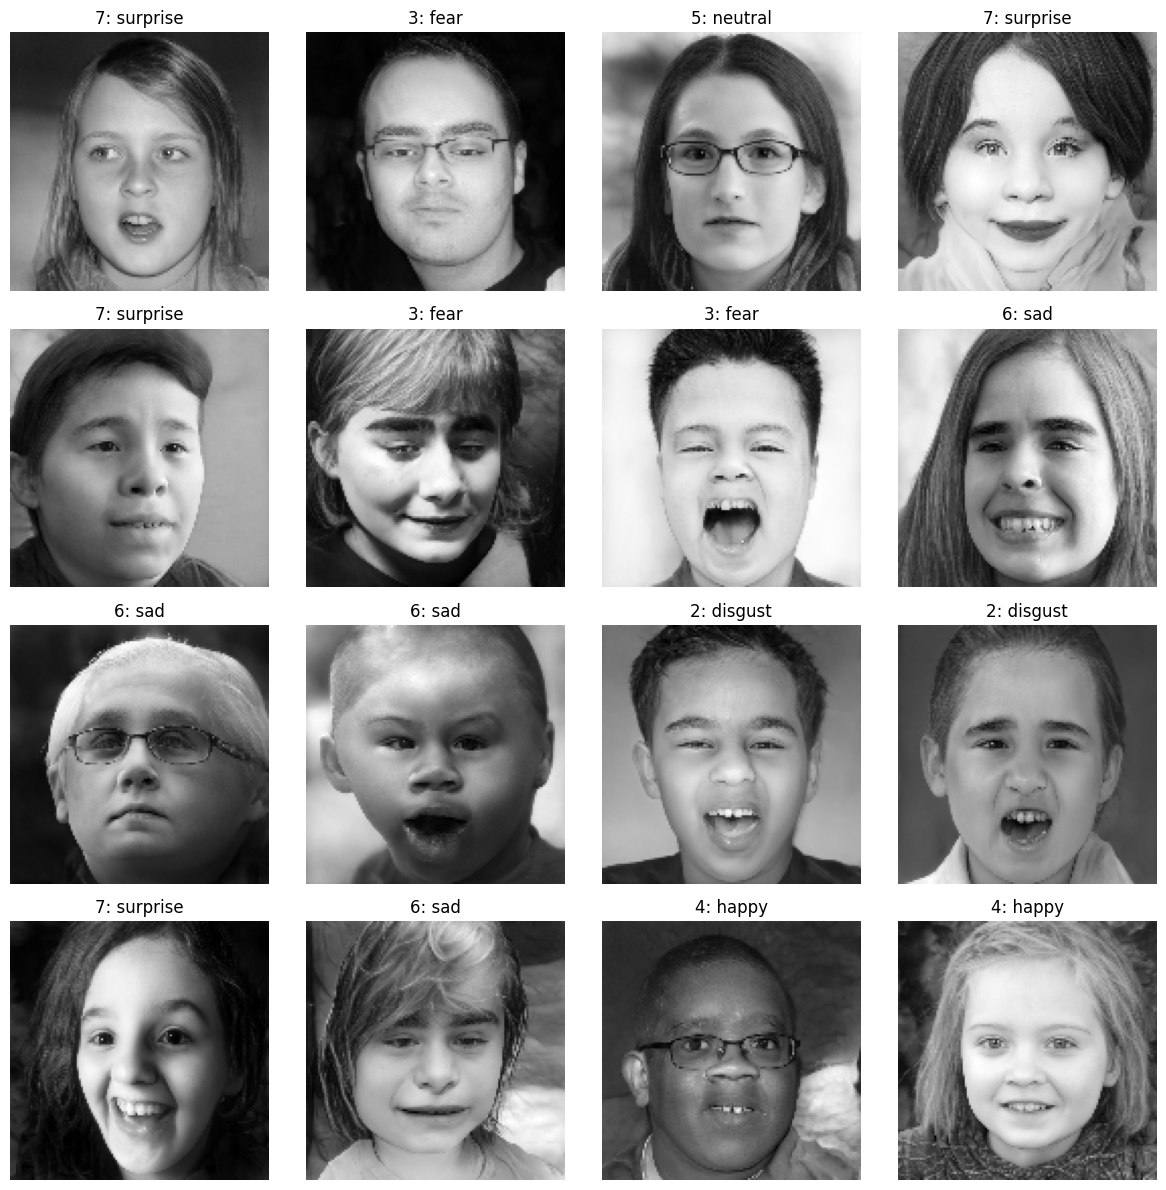

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            images[i].numpy().squeeze(),
            cmap="gray"
        )

        plt.title(
            f"{int(labels[i])}: {class_names[int(labels[i])]}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for images, labels in train_ds.take(1):

    print("Image shape :", images.shape)

    print(
        "Pixel MIN :",
        tf.reduce_min(images).numpy()
    )

    print(
        "Pixel MAX :",
        tf.reduce_max(images).numpy()
    )

    print(
        "Pixel MEAN:",
        tf.reduce_mean(images).numpy()
    )

    print(
        "Labels:",
        labels.numpy()
    )

Image shape : (32, 128, 128, 1)
Pixel MIN : 0.0
Pixel MAX : 255.0
Pixel MEAN: 109.713295
Labels: [1 2 0 7 7 6 3 3 1 3 0 6 3 3 4 4 5 1 2 5 5 0 0 6 7 5 0 6 5 6 3 2]


강제 과적합 테스트 이미지 수: 256

클래스별 이미지 수
0 - anger     : 32
1 - contempt  : 32
2 - disgust   : 32
3 - fear      : 32
4 - happy     : 32
5 - neutral   : 32
6 - sad       : 32
7 - surprise  : 32

Image Shape:
(32, 128, 128, 1)

Pixel MIN:
0.0

Pixel MAX:
1.0

Labels:
[4 3 2 3 2 6 1 2 6 3 2 1 7 7 1 2 5 7 7 3 5 0 0 1 4 5 5 1 0 7 5 3]


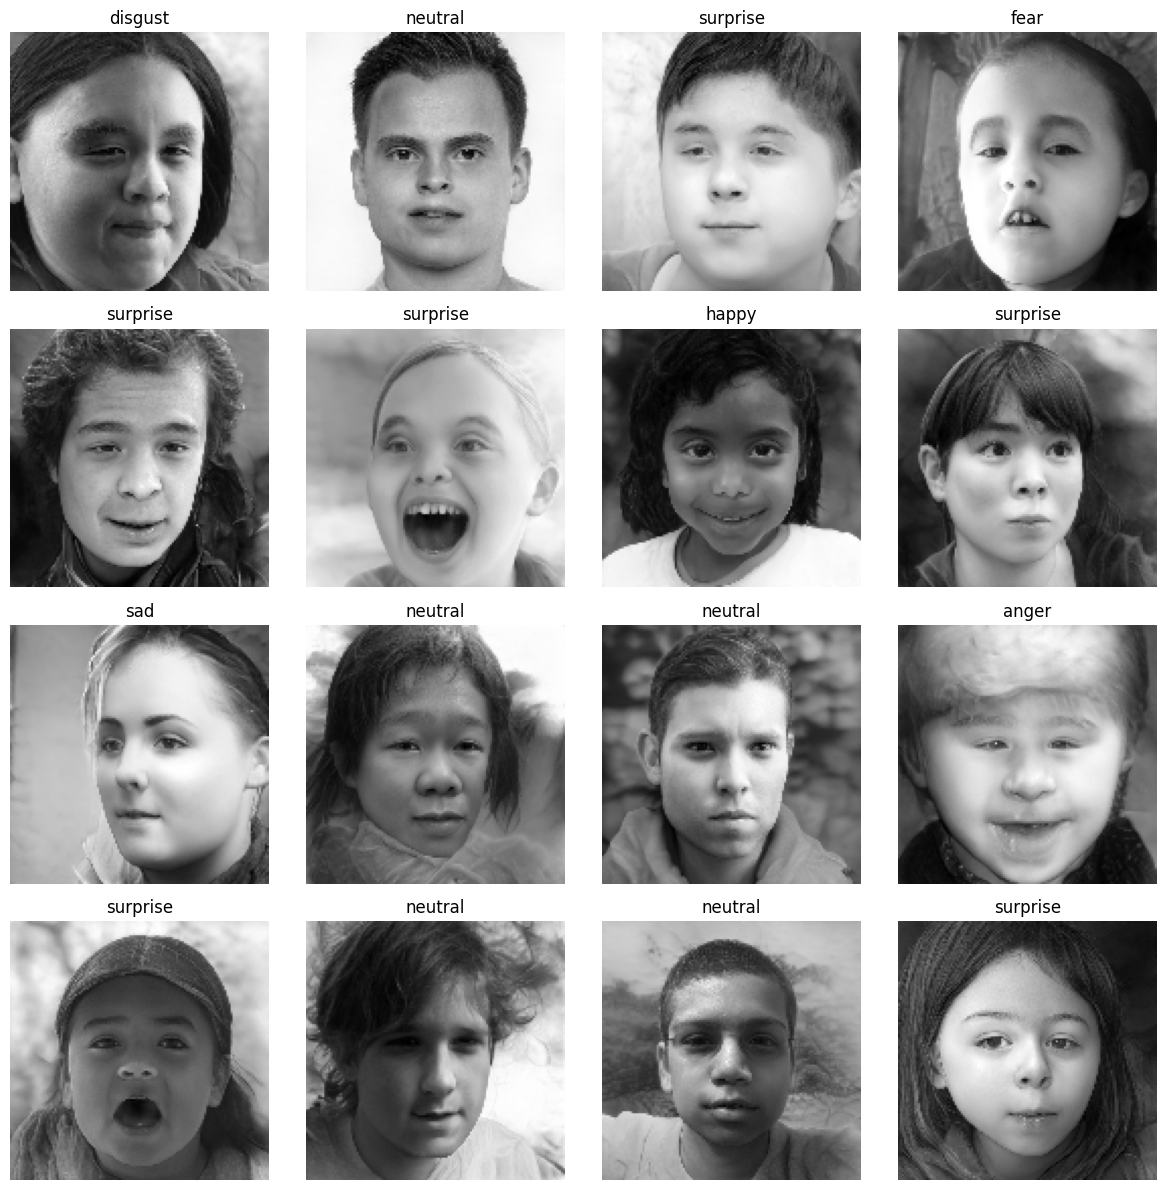

Model: "overfit_debug_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,554,376 (32.63 MB)

 Trainable params: 8,554,376 (32.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1133 - loss: 6.8499 
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1094 - loss: 4.4101
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1562 - loss: 2.5800
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1914 - loss: 2.3235
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1719 - loss: 2.2163
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1797 - loss: 2.0589
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2227 - loss: 2.0693
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2070 - loss: 2.0462
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2500 - loss: 2.0372
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2930 - loss: 1.9339
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2812 - loss: 1.9361
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2930 - loss: 1.8786
Epoch 13/50


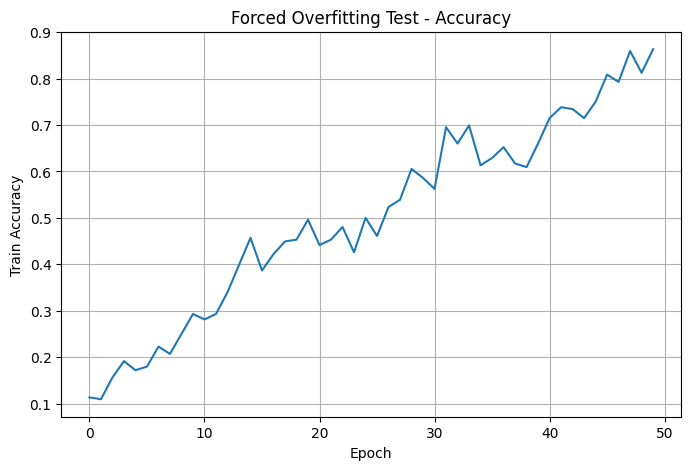

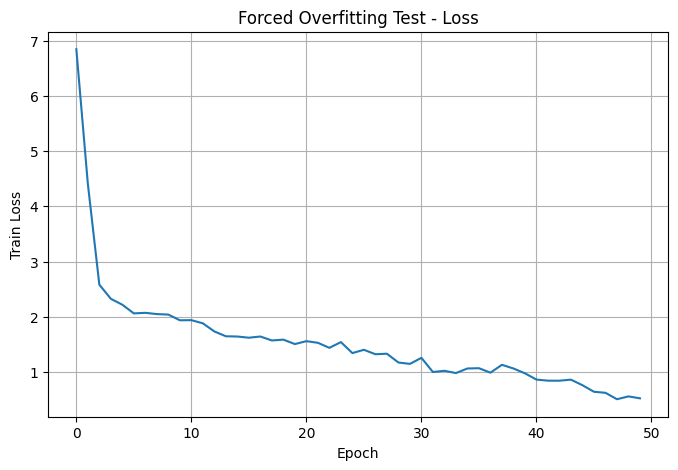

In [ ]:
# ============================================================
# 강제 과적합(Overfitting) 테스트
#
# 목적:
# 모델이 아주 작은 Train Dataset을 정상적으로 외울 수 있는지 확인
#
# 각 클래스 32장 × 8개 클래스
# = 총 256장
#
# 제거하는 것:
# - Data Augmentation
# - Dropout
# - LayerNormalization
# - EarlyStopping
# - ReduceLROnPlateau
#
# Validation / Test도 사용하지 않음
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# 2. 기본 설정
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


IMG_SIZE = 128

BATCH_SIZE = 32

NUM_CLASSES = 8

IMAGES_PER_CLASS = 32


CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ============================================================
# 3. 각 클래스에서 정확히 32장씩 가져오기
#
# 총:
# 32 × 8 = 256장
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


debug_paths = []

debug_labels = []


for label_idx, class_name in enumerate(CLASS_NAMES):

    class_dir = os.path.join(
        TRAIN_DIR,
        class_name
    )


    image_files = [

        os.path.join(
            class_dir,
            file_name
        )

        for file_name in os.listdir(class_dir)

        if file_name.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ]


    # 항상 동일한 결과를 위해 정렬
    image_files = sorted(
        image_files
    )


    # 클래스마다 랜덤 32장 선택
    random.Random(
        SEED + label_idx
    ).shuffle(
        image_files
    )


    selected_files = image_files[
        :IMAGES_PER_CLASS
    ]


    if len(selected_files) < IMAGES_PER_CLASS:

        raise ValueError(

            f"{class_name} 클래스의 이미지가 "
            f"{IMAGES_PER_CLASS}장보다 적습니다."
        )


    debug_paths.extend(
        selected_files
    )


    debug_labels.extend(
        [label_idx] * IMAGES_PER_CLASS
    )


print(
    "강제 과적합 테스트 이미지 수:",
    len(debug_paths)
)


# ============================================================
# 4. 클래스별 개수 확인
# ============================================================

unique, counts = np.unique(
    debug_labels,
    return_counts=True
)


print("\n클래스별 이미지 수")


for label, count in zip(
    unique,
    counts
):

    print(
        f"{label} - "
        f"{CLASS_NAMES[label]:10s}: "
        f"{count}"
    )


# 정상:
#
# anger       : 32
# contempt    : 32
# ...
# surprise    : 32


# ============================================================
# 5. 이미지 로딩 함수
#
# 현재 본 학습과 동일하게
#
# RGB 원본
# ↓
# Grayscale
# ↓
# 128 × 128
# ↓
# 0~1 정규화
# ============================================================

def load_debug_image(
    path,
    label
):

    # 이미지 파일 읽기
    image = tf.io.read_file(
        path
    )


    # 이미지 Decode
    #
    # channels=1
    # → Grayscale
    image = tf.io.decode_image(

        image,

        channels=1,

        expand_animations=False
    )


    # Shape 명시
    image.set_shape(
        [None, None, 1]
    )


    # 128 × 128 Resize
    image = tf.image.resize(

        image,

        [IMG_SIZE, IMG_SIZE]
    )


    # 0~255
    # ↓
    # 0~1
    image = tf.cast(
        image,
        tf.float32
    ) / 255.0


    return image, label


# ============================================================
# 6. TensorFlow Dataset 생성
# ============================================================

debug_ds = tf.data.Dataset.from_tensor_slices(
    (
        debug_paths,
        debug_labels
    )
)


# 이미지 로딩
debug_ds = debug_ds.map(

    load_debug_image,

    num_parallel_calls=tf.data.AUTOTUNE
)


# ============================================================
# 중요:
# cache()를 사용해서
# 매 Epoch마다 정확히 같은 256장을 사용
# ============================================================

debug_ds = debug_ds.cache()


# 순서 Shuffle
debug_ds = debug_ds.shuffle(

    buffer_size=len(debug_paths),

    seed=SEED,

    reshuffle_each_iteration=True
)


# Batch
debug_ds = debug_ds.batch(
    BATCH_SIZE
)


# Prefetch
debug_ds = debug_ds.prefetch(
    tf.data.AUTOTUNE
)


# ============================================================
# 7. Shape / Pixel 확인
# ============================================================

for images, labels in debug_ds.take(1):

    print("\nImage Shape:")
    print(images.shape)

    print("\nPixel MIN:")
    print(
        tf.reduce_min(images).numpy()
    )

    print("\nPixel MAX:")
    print(
        tf.reduce_max(images).numpy()
    )

    print("\nLabels:")
    print(
        labels.numpy()
    )


# 정상:
#
# Shape:
# (32, 128, 128, 1)
#
# MIN:
# 0 근처
#
# MAX:
# 1 근처


# ============================================================
# 8. 실제 Debug 이미지 확인
# ============================================================

plt.figure(
    figsize=(12, 12)
)


for images, labels in debug_ds.take(1):

    for i in range(16):

        plt.subplot(
            4,
            4,
            i + 1
        )


        plt.imshow(

            images[i]
            .numpy()
            .squeeze(),

            cmap="gray"
        )


        label_idx = int(
            labels[i]
        )


        plt.title(
            CLASS_NAMES[label_idx]
        )


        plt.axis(
            "off"
        )


plt.tight_layout()

plt.show()


# ============================================================
# 9. 강제 과적합용 DNN
#
# 일부러 Regularization을 제거함
#
# Dropout X
# LayerNorm X
# Augmentation X
#
# 모델이 Train Dataset을 외우게 만드는 것이 목적
# ============================================================

def build_overfit_model():

    inputs = tf.keras.layers.Input(

        shape=(
            IMG_SIZE,
            IMG_SIZE,
            1
        )
    )


    # 이미 Dataset에서 0~1로 정규화했으므로
    # Rescaling을 또 하지 않음


    # 128×128
    # ↓
    # 16,384
    x = tf.keras.layers.Flatten()(
        inputs
    )


    # Hidden Layer 1
    x = tf.keras.layers.Dense(

        512,

        activation="relu"
    )(x)


    # Hidden Layer 2
    x = tf.keras.layers.Dense(

        256,

        activation="relu"
    )(x)


    # Hidden Layer 3
    x = tf.keras.layers.Dense(

        128,

        activation="relu"
    )(x)


    # 8 Class
    outputs = tf.keras.layers.Dense(

        NUM_CLASSES,

        activation="softmax"
    )(x)


    model = tf.keras.Model(

        inputs=inputs,

        outputs=outputs,

        name="overfit_debug_model"
    )


    return model


# ============================================================
# 10. 모델 생성
# ============================================================

debug_model = build_overfit_model()


debug_model.summary()


# ============================================================
# 11. Compile
# ============================================================

debug_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


# ============================================================
# 12. 강제 학습
#
# Validation X
# EarlyStopping X
# Scheduler X
#
# 무조건 50 Epoch
# ============================================================

debug_history = debug_model.fit(

    debug_ds,

    epochs=50,

    verbose=1
)


# ============================================================
# 13. 최종 Train 성능
# ============================================================

debug_loss, debug_accuracy = (
    debug_model.evaluate(

        debug_ds,

        verbose=0
    )
)


print("\n")
print("=" * 60)
print("강제 과적합 테스트 최종 결과")
print("=" * 60)


print(
    f"Train Loss     : "
    f"{debug_loss:.6f}"
)


print(
    f"Train Accuracy : "
    f"{debug_accuracy:.4f}"
)


# ============================================================
# 14. 학습 그래프
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    debug_history.history[
        "accuracy"
    ]
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Train Accuracy"
)

plt.title(
    "Forced Overfitting Test - Accuracy"
)

plt.grid()

plt.show()


plt.figure(
    figsize=(8, 5)
)


plt.plot(
    debug_history.history[
        "loss"
    ]
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Train Loss"
)

plt.title(
    "Forced Overfitting Test - Loss"
)

plt.grid()

plt.show()

데이터 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.


Class 정보
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Image Shape:
(32, 128, 128, 1)

Pixel MIN:
0.0

Pixel MAX:
255.0

Pixel MEAN:
113.415085

Labels:
[4 0 7 3 1 3 6 3 6 1 0 0 2 7 7 5 6 2 7 0 6 6 6 0 1 0 1 1 7 4 0 0]


Debug DNN 구조


Model: "Debug_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,554,376 (32.63 MB)

 Trainable params: 8,554,376 (32.63 MB)

 Non-trainable params: 0 (0.00 B)



Debug DNN 학습 시작
Epoch 1/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.2072 - loss: 2.3054 - val_accuracy: 0.2384 - val_loss: 1.8476
Epoch 2/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.2924 - loss: 1.7427 - val_accuracy: 0.3241 - val_loss: 1.6614
Epoch 3/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.3155 - loss: 1.7006 - val_accuracy: 0.3227 - val_loss: 1.6577
Epoch 4/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.3510 - loss: 1.6238 - val_accuracy: 0.3532 - val_loss: 1.6693
Epoch 5/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.3551 - loss: 1.6044 - val_accuracy: 0.3733 - val_loss: 1.5716
Epoch 6/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.3568 - loss: 1.5906 - val_accuracy: 0.3692 - val_loss: 1.6124
Epoch 7/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.3805 - loss: 1.5564 - val_accuracy: 0.3578 - val_loss: 1.6568
Epoch 8/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.3817

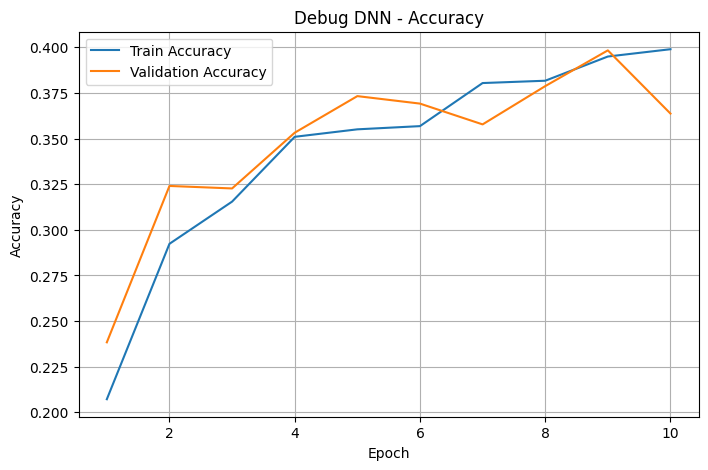

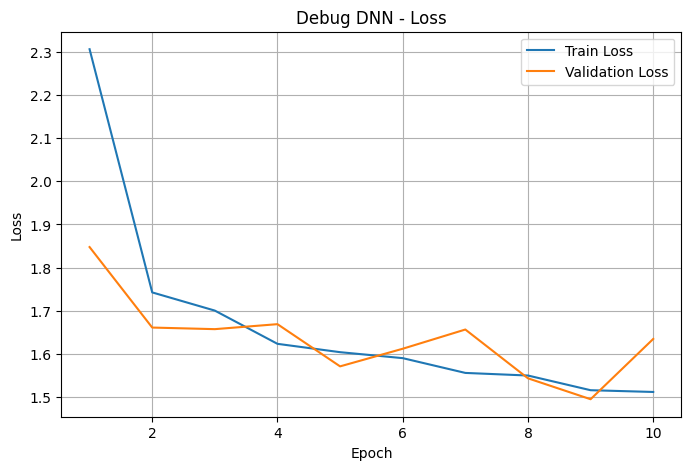

69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.3609 - loss: 1.6458


Debug DNN Test 결과
Test Loss : 1.6458
Test Accuracy : 0.3609


In [ ]:
# ============================================================
# Keras DNN 디버깅 학습
#
# 목적:
# 전체 Train Dataset에서
# 단순한 DNN이 정상적으로 학습되는지 확인
#
# 제거:
# - Data Augmentation
# - Dropout
# - LayerNormalization
# - EarlyStopping
# - ReduceLROnPlateau
#
# 입력:
# 128 × 128 × 1 (Grayscale)
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 3. 기본 설정
# ============================================================

IMG_SIZE = 128

BATCH_SIZE = 32

NUM_CLASSES = 8

EPOCHS = 10

LEARNING_RATE = 0.001


CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ============================================================
# 4. 데이터 경로 확인
#
# TRAIN_DIR / VAL_DIR / TEST_DIR는
# 앞에서 압축 해제 코드에서 생성되어 있어야 함
# ============================================================

print("=" * 60)
print("데이터 경로 확인")
print("=" * 60)

print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)


for path_name, path in [
    ("TRAIN_DIR", TRAIN_DIR),
    ("VAL_DIR", VAL_DIR),
    ("TEST_DIR", TEST_DIR)
]:

    if not os.path.isdir(path):

        raise FileNotFoundError(
            f"{path_name} 경로를 찾을 수 없습니다.\n"
            f"{path}"
        )


# ============================================================
# 5. Train Dataset
#
# 여기서는 데이터 증강을 사용하지 않음
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    class_names=CLASS_NAMES,

    # 1024 × 1024
    # ↓
    # 128 × 128
    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    # RGB → Grayscale
    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=True,

    seed=SEED
)


# ============================================================
# 6. Validation Dataset
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


# ============================================================
# 7. Test Dataset
#
# 지금 당장 사용하지는 않지만
# 이후 평가용으로 생성
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


# ============================================================
# 8. 클래스 확인
# ============================================================

class_names = train_ds.class_names


print("\n")
print("=" * 60)
print("Class 정보")
print("=" * 60)

print(class_names)


# ============================================================
# 9. Dataset Shape / Pixel 확인
# ============================================================

for images, labels in train_ds.take(1):

    print("\nImage Shape:")
    print(images.shape)

    print("\nPixel MIN:")
    print(
        tf.reduce_min(images).numpy()
    )

    print("\nPixel MAX:")
    print(
        tf.reduce_max(images).numpy()
    )

    print("\nPixel MEAN:")
    print(
        tf.reduce_mean(images).numpy()
    )

    print("\nLabels:")
    print(
        labels.numpy()
    )


# 정상 결과 예:
#
# Shape:
# (32, 128, 128, 1)
#
# MIN:
# 0
#
# MAX:
# 255


# ============================================================
# 10. Dataset 최적화
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(
    AUTOTUNE
)


val_ds = val_ds.prefetch(
    AUTOTUNE
)


test_ds = test_ds.prefetch(
    AUTOTUNE
)


# ============================================================
# 11. 단순 DNN 모델
#
# 128 × 128 × 1
#
# ↓
#
# Flatten
#
# ↓
#
# 16,384
#
# ↓
#
# Dense 512
#
# ↓
#
# Dense 256
#
# ↓
#
# Dense 128
#
# ↓
#
# Dense 8
#
#
# 이번 디버깅에서는
#
# Data Augmentation X
# Dropout X
# LayerNormalization X
#
# ============================================================

def build_test_dnn():

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = layers.Input(

        shape=(
            IMG_SIZE,
            IMG_SIZE,
            1
        )
    )


    # --------------------------------------------------------
    # 정규화
    #
    # 0 ~ 255
    # ↓
    # 0 ~ 1
    # --------------------------------------------------------

    x = layers.Rescaling(
        1.0 / 255.0
    )(inputs)


    # --------------------------------------------------------
    # Flatten
    #
    # 128 × 128 × 1
    # ↓
    # 16,384
    # --------------------------------------------------------

    x = layers.Flatten()(x)


    # --------------------------------------------------------
    # Hidden Layer 1
    #
    # 16,384
    # ↓
    # 512
    # --------------------------------------------------------

    x = layers.Dense(
        512,
        activation="relu"
    )(x)


    # --------------------------------------------------------
    # Hidden Layer 2
    #
    # 512
    # ↓
    # 256
    # --------------------------------------------------------

    x = layers.Dense(
        256,
        activation="relu"
    )(x)


    # --------------------------------------------------------
    # Hidden Layer 3
    #
    # 256
    # ↓
    # 128
    # --------------------------------------------------------

    x = layers.Dense(
        128,
        activation="relu"
    )(x)


    # --------------------------------------------------------
    # Output
    #
    # 128
    # ↓
    # 8 Classes
    # --------------------------------------------------------

    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax"

    )(x)


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="Debug_DNN"
    )


    return model


# ============================================================
# 12. 모델 생성
# ============================================================

test_dnn = build_test_dnn()


# ============================================================
# 13. 모델 구조 출력
# ============================================================

print("\n")
print("=" * 60)
print("Debug DNN 구조")
print("=" * 60)


test_dnn.summary()


# ============================================================
# 14. 모델 Compile
#
# Optimizer:
# Adam
#
# Learning Rate:
# 0.001
#
# Loss:
# Sparse Categorical Crossentropy
# ============================================================

test_dnn.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


# ============================================================
# 15. 학습
#
# 중요:
#
# EarlyStopping 없음
# ReduceLROnPlateau 없음
#
# 무조건 10 Epoch 실행
# ============================================================

print("\n")
print("=" * 60)
print("Debug DNN 학습 시작")
print("=" * 60)


test_history = test_dnn.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    verbose=1
)


# ============================================================
# 16. 마지막 Epoch 결과
# ============================================================

final_train_acc = (
    test_history
    .history["accuracy"][-1]
)


final_val_acc = (
    test_history
    .history["val_accuracy"][-1]
)


final_train_loss = (
    test_history
    .history["loss"][-1]
)


final_val_loss = (
    test_history
    .history["val_loss"][-1]
)


print("\n")
print("=" * 60)
print("Debug DNN 최종 결과")
print("=" * 60)


print(
    f"Train Accuracy : "
    f"{final_train_acc:.4f}"
)


print(
    f"Validation Accuracy : "
    f"{final_val_acc:.4f}"
)


print(
    f"Train Loss : "
    f"{final_train_loss:.4f}"
)


print(
    f"Validation Loss : "
    f"{final_val_loss:.4f}"
)


# ============================================================
# 17. Accuracy 그래프
# ============================================================

epochs_range = range(
    1,
    len(test_history.history["accuracy"]) + 1
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    test_history.history["accuracy"],

    label="Train Accuracy"
)


plt.plot(

    epochs_range,

    test_history.history["val_accuracy"],

    label="Validation Accuracy"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "Debug DNN - Accuracy"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# 18. Loss 그래프
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    test_history.history["loss"],

    label="Train Loss"
)


plt.plot(

    epochs_range,

    test_history.history["val_loss"],

    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Debug DNN - Loss"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# 19. Test Dataset 평가
#
# 이 단계에서는 Accuracy만 간단히 확인
# ============================================================

test_loss, test_accuracy = test_dnn.evaluate(

    test_ds,

    verbose=1
)


print("\n")
print("=" * 60)
print("Debug DNN Test 결과")
print("=" * 60)


print(
    f"Test Loss : "
    f"{test_loss:.4f}"
)


print(
    f"Test Accuracy : "
    f"{test_accuracy:.4f}"
)

데이터 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.

클래스:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Dropout DNN 구조


Model: "DNN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,554,376 (32.63 MB)

 Trainable params: 8,554,376 (32.63 MB)

 Non-trainable params: 0 (0.00 B)



Dropout DNN 학습 시작
Epoch 1/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - accuracy: 0.1598 - loss: 2.3952 - val_accuracy: 0.1882 - val_loss: 1.9633
Epoch 2/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.1960 - loss: 1.9009 - val_accuracy: 0.2311 - val_loss: 1.8063
Epoch 3/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.2145 - loss: 1.8397 - val_accuracy: 0.2201 - val_loss: 1.8338
Epoch 4/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.2190 - loss: 1.8500 - val_accuracy: 0.2621 - val_loss: 1.6975
Epoch 5/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.2274 - loss: 1.8211 - val_accuracy: 0.2662 - val_loss: 1.7321
Epoch 6/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.2322 - loss: 1.8127 - val_accuracy: 0.2721 - val_loss: 1.7119
Epoch 7/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.2378 - loss: 1.7908 - val_accuracy: 0.2671 - val_loss: 1.7170
Epoch 8/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.23

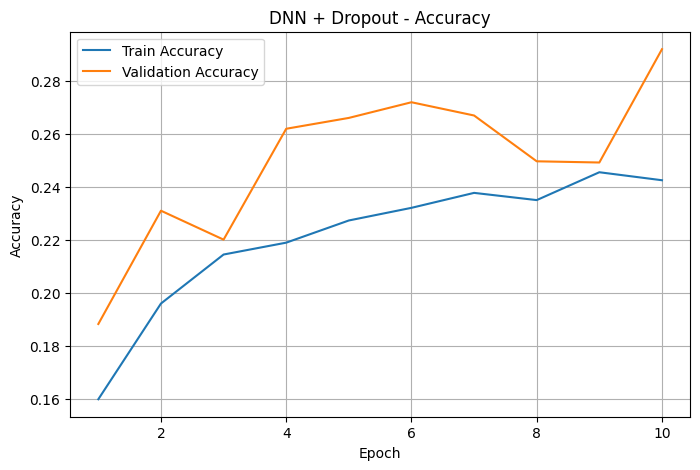

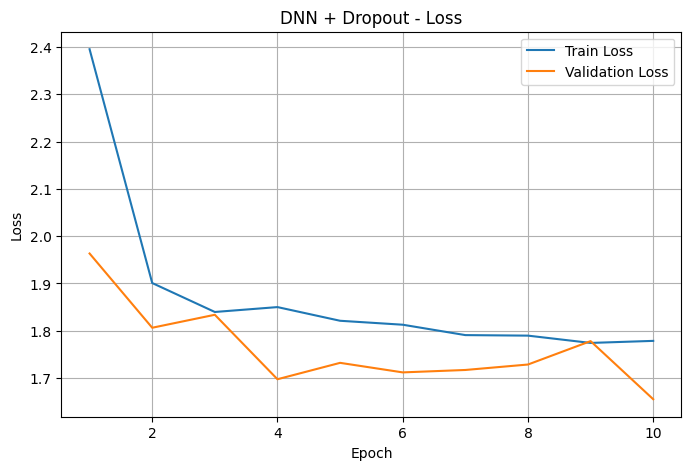

In [ ]:
# ============================================================
# Keras DNN 디버깅 실험 A
# Dropout만 추가
#
# 목적:
# 기본 DNN에 Dropout만 추가했을 때
# 학습 성능이 어떻게 변하는지 확인
#
# 포함:
# - Dropout O
#
# 제외:
# - Data Augmentation X
# - LayerNormalization X
# - EarlyStopping X
# - ReduceLROnPlateau X
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 3. 기본 설정
# ============================================================

IMG_SIZE = 128

BATCH_SIZE = 32

NUM_CLASSES = 8

EPOCHS = 10

LEARNING_RATE = 0.001


CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ============================================================
# 4. 데이터 경로 확인
# ============================================================

print("=" * 60)
print("데이터 경로 확인")
print("=" * 60)

print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)


for path_name, path in [
    ("TRAIN_DIR", TRAIN_DIR),
    ("VAL_DIR", VAL_DIR),
    ("TEST_DIR", TEST_DIR)
]:

    if not os.path.isdir(path):

        raise FileNotFoundError(
            f"{path_name} 경로를 찾을 수 없습니다.\n"
            f"{path}"
        )


# ============================================================
# 5. Train Dataset
#
# 데이터 증강 없음
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=True,

    seed=SEED
)


# ============================================================
# 6. Validation Dataset
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


# ============================================================
# 7. Test Dataset
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


# ============================================================
# 8. 클래스 확인
# ============================================================

class_names = train_ds.class_names

print("\n클래스:")
print(class_names)


# ============================================================
# 9. Dataset 최적화
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(
    AUTOTUNE
)


val_ds = val_ds.prefetch(
    AUTOTUNE
)


test_ds = test_ds.prefetch(
    AUTOTUNE
)


# ============================================================
# 10. Dropout만 추가한 DNN
#
# 16384
# ↓
# 512
# ↓
# Dropout 0.2
# ↓
# 256
# ↓
# Dropout 0.2
# ↓
# 128
# ↓
# Dropout 0.1
# ↓
# 8
# ============================================================

def build_dnn_dropout():

    inputs = layers.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            1
        )
    )


    # 0~255 → 0~1
    x = layers.Rescaling(
        1.0 / 255.0
    )(inputs)


    # Flatten
    x = layers.Flatten()(x)


    # Hidden 1
    x = layers.Dense(
        512,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.2
    )(x)


    # Hidden 2
    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.2
    )(x)


    # Hidden 3
    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.1
    )(x)


    # Output
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="DNN_Dropout"
    )


    return model


# ============================================================
# 11. 모델 생성
# ============================================================

dropout_dnn = build_dnn_dropout()


# ============================================================
# 12. 모델 구조 확인
# ============================================================

print("\n")
print("=" * 60)
print("Dropout DNN 구조")
print("=" * 60)

dropout_dnn.summary()


# ============================================================
# 13. Compile
# ============================================================

dropout_dnn.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


# ============================================================
# 14. 학습
#
# EarlyStopping 없음
# Scheduler 없음
# ============================================================

print("\n")
print("=" * 60)
print("Dropout DNN 학습 시작")
print("=" * 60)


dropout_history = dropout_dnn.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    verbose=1
)


# ============================================================
# 15. 최종 Train / Validation 결과
# ============================================================

final_train_acc = (
    dropout_history.history["accuracy"][-1]
)

final_val_acc = (
    dropout_history.history["val_accuracy"][-1]
)

final_train_loss = (
    dropout_history.history["loss"][-1]
)

final_val_loss = (
    dropout_history.history["val_loss"][-1]
)


print("\n")
print("=" * 60)
print("Dropout DNN 최종 결과")
print("=" * 60)

print(
    f"Train Accuracy      : {final_train_acc:.4f}"
)

print(
    f"Validation Accuracy : {final_val_acc:.4f}"
)

print(
    f"Train Loss          : {final_train_loss:.4f}"
)

print(
    f"Validation Loss     : {final_val_loss:.4f}"
)


# ============================================================
# 16. Test 평가
# ============================================================

test_loss, test_accuracy = dropout_dnn.evaluate(
    test_ds,
    verbose=1
)


print("\n")
print("=" * 60)
print("Dropout DNN Test 결과")
print("=" * 60)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)


# ============================================================
# 17. Accuracy 그래프
# ============================================================

epochs_range = range(
    1,
    len(dropout_history.history["accuracy"]) + 1
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(
    epochs_range,
    dropout_history.history["accuracy"],
    label="Train Accuracy"
)


plt.plot(
    epochs_range,
    dropout_history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "DNN + Dropout - Accuracy"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 18. Loss 그래프
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    epochs_range,
    dropout_history.history["loss"],
    label="Train Loss"
)


plt.plot(
    epochs_range,
    dropout_history.history["val_loss"],
    label="Validation Loss"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DNN + Dropout - Loss"
)

plt.legend()
plt.grid()

plt.show()

데이터 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.

클래스:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Augmentation DNN 구조


Model: "DNN_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,554,376 (32.63 MB)

 Trainable params: 8,554,376 (32.63 MB)

 Non-trainable params: 0 (0.00 B)



Augmentation DNN 학습 시작
Epoch 1/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.2087 - loss: 2.3647 - val_accuracy: 0.2325 - val_loss: 1.8774
Epoch 2/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.2569 - loss: 1.8339 - val_accuracy: 0.2584 - val_loss: 1.8272
Epoch 3/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.2812 - loss: 1.7622 - val_accuracy: 0.2293 - val_loss: 1.9837
Epoch 4/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.2932 - loss: 1.7171 - val_accuracy: 0.3232 - val_loss: 1.6366
Epoch 5/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.3167 - loss: 1.6806 - val_accuracy: 0.2894 - val_loss: 1.7871
Epoch 6/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.3233 - loss: 1.6592 - val_accuracy: 0.2972 - val_loss: 1.7218
Epoch 7/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.3393 - loss: 1.6420 - val_accuracy: 0.3373 - val_loss: 1.5825
Epoch 8/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy:

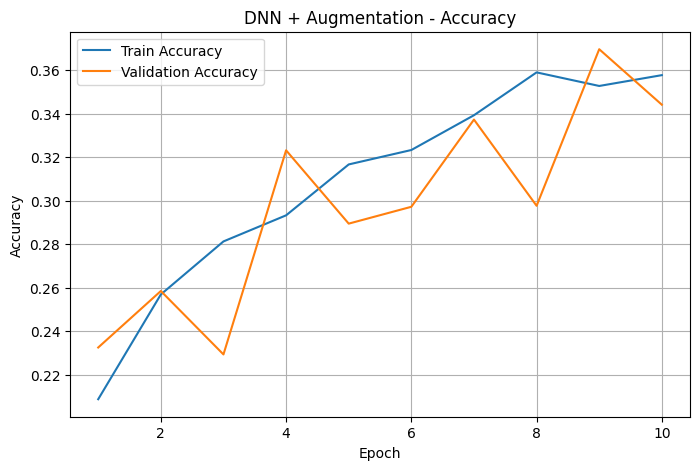

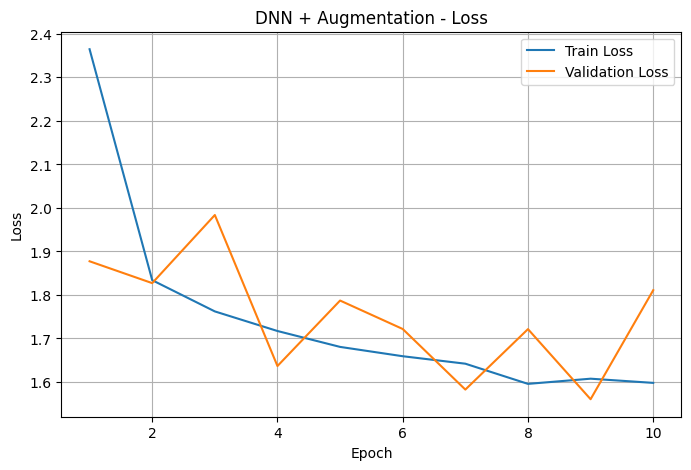

In [ ]:
# ============================================================
# Keras DNN 디버깅 실험 B
# Data Augmentation만 추가
#
# 목적:
# 기본 DNN에 Data Augmentation만 적용했을 때
# 학습 성능이 어떻게 변하는지 확인
#
# 포함:
# - Random Horizontal Flip
# - Random Rotation 약 ±5도
#
# 제외:
# - Dropout X
# - LayerNormalization X
# - EarlyStopping X
# - ReduceLROnPlateau X
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 3. 기본 설정
# ============================================================

IMG_SIZE = 128

BATCH_SIZE = 32

NUM_CLASSES = 8

EPOCHS = 10

LEARNING_RATE = 0.001


CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ============================================================
# 4. 데이터 경로 확인
# ============================================================

print("=" * 60)
print("데이터 경로 확인")
print("=" * 60)

print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)


for path_name, path in [
    ("TRAIN_DIR", TRAIN_DIR),
    ("VAL_DIR", VAL_DIR),
    ("TEST_DIR", TEST_DIR)
]:

    if not os.path.isdir(path):

        raise FileNotFoundError(
            f"{path_name} 경로를 찾을 수 없습니다.\n"
            f"{path}"
        )


# ============================================================
# 5. Train Dataset
#
# Dataset 자체에는 augmentation을 넣지 않고
# 모델 내부에서 적용
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=True,

    seed=SEED
)


# ============================================================
# 6. Validation Dataset
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


# ============================================================
# 7. Test Dataset
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


# ============================================================
# 8. 클래스 확인
# ============================================================

class_names = train_ds.class_names

print("\n클래스:")
print(class_names)


# ============================================================
# 9. Dataset 최적화
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(
    AUTOTUNE
)


val_ds = val_ds.prefetch(
    AUTOTUNE
)


test_ds = test_ds.prefetch(
    AUTOTUNE
)


# ============================================================
# 10. Data Augmentation
#
# 학습 중에만 활성화됨
#
# Validation / Test / predict에서는 자동 비활성화
# ============================================================

data_augmentation = tf.keras.Sequential(

    [

        # 좌우 반전
        layers.RandomFlip(
            "horizontal"
        ),

        # 약 ±5도 회전
        layers.RandomRotation(
            0.014
        )
    ],

    name="augmentation"
)


# ============================================================
# 11. Augmentation만 추가한 DNN
#
# Input
# ↓
# Augmentation
# ↓
# Rescaling
# ↓
# Flatten
# ↓
# 512
# ↓
# 256
# ↓
# 128
# ↓
# 8
#
# Dropout 없음
# LayerNorm 없음
# ============================================================

def build_dnn_augmentation():

    inputs = layers.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            1
        )
    )


    # 데이터 증강
    x = data_augmentation(
        inputs
    )


    # 0~255 → 0~1
    x = layers.Rescaling(
        1.0 / 255.0
    )(x)


    # Flatten
    x = layers.Flatten()(x)


    # Hidden 1
    x = layers.Dense(
        512,
        activation="relu"
    )(x)


    # Hidden 2
    x = layers.Dense(
        256,
        activation="relu"
    )(x)


    # Hidden 3
    x = layers.Dense(
        128,
        activation="relu"
    )(x)


    # Output
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="DNN_Augmentation"
    )


    return model


# ============================================================
# 12. 모델 생성
# ============================================================

augmentation_dnn = build_dnn_augmentation()


# ============================================================
# 13. 모델 구조 확인
# ============================================================

print("\n")
print("=" * 60)
print("Augmentation DNN 구조")
print("=" * 60)

augmentation_dnn.summary()


# ============================================================
# 14. Compile
# ============================================================

augmentation_dnn.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


# ============================================================
# 15. 학습
#
# EarlyStopping 없음
# ReduceLROnPlateau 없음
# ============================================================

print("\n")
print("=" * 60)
print("Augmentation DNN 학습 시작")
print("=" * 60)


augmentation_history = augmentation_dnn.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    verbose=1
)


# ============================================================
# 16. 최종 Train / Validation 결과
# ============================================================

final_train_acc = (
    augmentation_history.history["accuracy"][-1]
)

final_val_acc = (
    augmentation_history.history["val_accuracy"][-1]
)

final_train_loss = (
    augmentation_history.history["loss"][-1]
)

final_val_loss = (
    augmentation_history.history["val_loss"][-1]
)


print("\n")
print("=" * 60)
print("Augmentation DNN 최종 결과")
print("=" * 60)


print(
    f"Train Accuracy      : {final_train_acc:.4f}"
)

print(
    f"Validation Accuracy : {final_val_acc:.4f}"
)

print(
    f"Train Loss          : {final_train_loss:.4f}"
)

print(
    f"Validation Loss     : {final_val_loss:.4f}"
)


# ============================================================
# 17. Test 평가
# ============================================================

test_loss, test_accuracy = augmentation_dnn.evaluate(
    test_ds,
    verbose=1
)


print("\n")
print("=" * 60)
print("Augmentation DNN Test 결과")
print("=" * 60)


print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)


# ============================================================
# 18. Accuracy 그래프
# ============================================================

epochs_range = range(
    1,
    len(
        augmentation_history.history[
            "accuracy"
        ]
    ) + 1
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(
    epochs_range,
    augmentation_history.history[
        "accuracy"
    ],
    label="Train Accuracy"
)


plt.plot(
    epochs_range,
    augmentation_history.history[
        "val_accuracy"
    ],
    label="Validation Accuracy"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "DNN + Augmentation - Accuracy"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 19. Loss 그래프
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    epochs_range,
    augmentation_history.history[
        "loss"
    ],
    label="Train Loss"
)


plt.plot(
    epochs_range,
    augmentation_history.history[
        "val_loss"
    ],
    label="Validation Loss"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DNN + Augmentation - Loss"
)

plt.legend()
plt.grid()

plt.show()

데이터 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.


Class 정보
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Image Shape:
(32, 128, 128, 1)

Pixel MIN:
0.0

Pixel MAX:
255.0

Pixel MEAN:
113.415085

Labels:
[4 0 7 3 1 3 6 3 6 1 0 0 2 7 7 5 6 2 7 0 6 6 6 0 1 0 1 1 7 4 0 0]


LayerNormalization DNN 구조


Model: "DNN_LayerNorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 512)            │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,555,912 (32.64 MB)

 Trainable params: 8,555,912 (32.64 MB)

 Non-trainable params: 0 (0.00 B)



LayerNormalization DNN 학습 시작
Epoch 1/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.1802 - loss: 2.0028 - val_accuracy: 0.2470 - val_loss: 1.8206
Epoch 2/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.2625 - loss: 1.7411 - val_accuracy: 0.3049 - val_loss: 1.6652
Epoch 3/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.2976 - loss: 1.6969 - val_accuracy: 0.2789 - val_loss: 1.6789
Epoch 4/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.3293 - loss: 1.6455 - val_accuracy: 0.3350 - val_loss: 1.5977
Epoch 5/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.3530 - loss: 1.5970 - val_accuracy: 0.3706 - val_loss: 1.5538
Epoch 6/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.3615 - loss: 1.5694 - val_accuracy: 0.3560 - val_loss: 1.5753
Epoch 7/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.3769 - loss: 1.5451 - val_accuracy: 0.4043 - val_loss: 1.4825
Epoch 8/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - acc

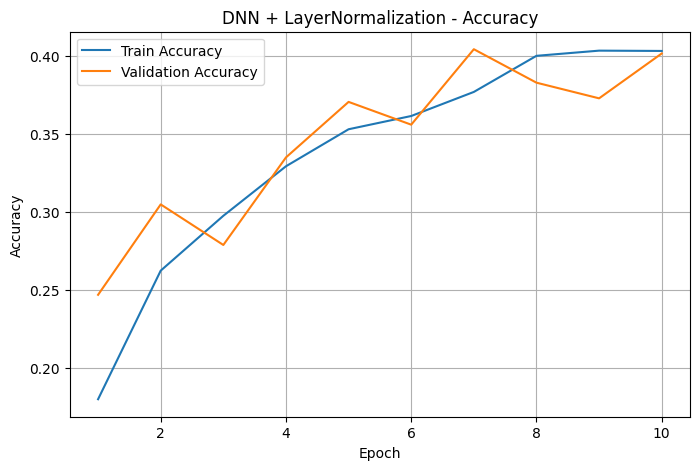

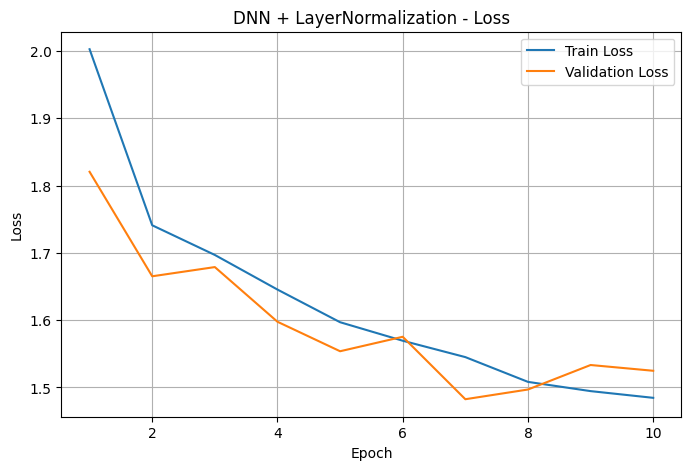



지금까지 DNN Ablation 실험 비교
Baseline DNN       | Train: 0.3990 | Val: 0.3637 | Test: 0.3609
Dropout only       | Train: 0.2426 | Val: 0.2922 
Augmentation only  | Train: 0.3577 | Val: 0.3441 
LayerNorm only     | Train: 0.4032 | Val: 0.4015 | Test: 0.3981


In [ ]:
# ============================================================
# Keras DNN 디버깅 실험 C
# LayerNormalization만 추가
#
# 목적:
# 기본 DNN에 LayerNormalization만 추가했을 때
# 학습이 정상적으로 진행되는지 확인
#
# 포함:
# - LayerNormalization O
#
# 제외:
# - Data Augmentation X
# - Dropout X
# - EarlyStopping X
# - ReduceLROnPlateau X
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 3. 기본 설정
# ============================================================

IMG_SIZE = 128

BATCH_SIZE = 32

NUM_CLASSES = 8

EPOCHS = 10

LEARNING_RATE = 0.001


CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ============================================================
# 4. 데이터 경로 확인
#
# TRAIN_DIR / VAL_DIR / TEST_DIR는
# 앞의 압축 해제 코드에서 정의되어 있어야 함
# ============================================================

print("=" * 60)
print("데이터 경로 확인")
print("=" * 60)

print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)


for path_name, path in [
    ("TRAIN_DIR", TRAIN_DIR),
    ("VAL_DIR", VAL_DIR),
    ("TEST_DIR", TEST_DIR)
]:

    if not os.path.isdir(path):

        raise FileNotFoundError(
            f"{path_name} 경로를 찾을 수 없습니다.\n"
            f"{path}"
        )


# ============================================================
# 5. Train Dataset
#
# Augmentation 사용하지 않음
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=True,

    seed=SEED
)


# ============================================================
# 6. Validation Dataset
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


# ============================================================
# 7. Test Dataset
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False
)


# ============================================================
# 8. 클래스 확인
# ============================================================

class_names = train_ds.class_names


print("\n")
print("=" * 60)
print("Class 정보")
print("=" * 60)

print(class_names)


# ============================================================
# 9. Dataset Shape 확인
# ============================================================

for images, labels in train_ds.take(1):

    print("\nImage Shape:")
    print(images.shape)

    print("\nPixel MIN:")
    print(
        tf.reduce_min(images).numpy()
    )

    print("\nPixel MAX:")
    print(
        tf.reduce_max(images).numpy()
    )

    print("\nPixel MEAN:")
    print(
        tf.reduce_mean(images).numpy()
    )

    print("\nLabels:")
    print(
        labels.numpy()
    )


# ============================================================
# 10. Dataset 최적화
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(
    AUTOTUNE
)


val_ds = val_ds.prefetch(
    AUTOTUNE
)


test_ds = test_ds.prefetch(
    AUTOTUNE
)


# ============================================================
# 11. LayerNormalization만 추가한 DNN
#
# 구조:
#
# 128 × 128 × 1
#
# ↓
#
# Rescaling
#
# ↓
#
# Flatten
#
# ↓
#
# 16,384
#
# ↓
#
# Dense 512
# ↓
# ReLU
# ↓
# LayerNormalization
#
# ↓
#
# Dense 256
# ↓
# ReLU
# ↓
# LayerNormalization
#
# ↓
#
# Dense 128
# ↓
# ReLU
#
# ↓
#
# Dense 8
# ↓
# Softmax
#
#
# Dropout 없음
# Augmentation 없음
# ============================================================

def build_dnn_layernorm():

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = layers.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            1
        )
    )


    # --------------------------------------------------------
    # 정규화
    #
    # 0 ~ 255
    # ↓
    # 0 ~ 1
    # --------------------------------------------------------

    x = layers.Rescaling(
        1.0 / 255.0
    )(inputs)


    # --------------------------------------------------------
    # Flatten
    #
    # 128 × 128 × 1
    # ↓
    # 16,384
    # --------------------------------------------------------

    x = layers.Flatten()(x)


    # --------------------------------------------------------
    # Hidden Layer 1
    #
    # 16,384
    # ↓
    # 512
    # --------------------------------------------------------

    x = layers.Dense(
        512,
        activation="relu"
    )(x)


    # Layer Normalization
    x = layers.LayerNormalization()(x)


    # --------------------------------------------------------
    # Hidden Layer 2
    #
    # 512
    # ↓
    # 256
    # --------------------------------------------------------

    x = layers.Dense(
        256,
        activation="relu"
    )(x)


    # Layer Normalization
    x = layers.LayerNormalization()(x)


    # --------------------------------------------------------
    # Hidden Layer 3
    #
    # 256
    # ↓
    # 128
    # --------------------------------------------------------

    x = layers.Dense(
        128,
        activation="relu"
    )(x)


    # --------------------------------------------------------
    # Output
    #
    # 128
    # ↓
    # 8
    # --------------------------------------------------------

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="DNN_LayerNorm"
    )


    return model


# ============================================================
# 12. 모델 생성
# ============================================================

layernorm_dnn = build_dnn_layernorm()


# ============================================================
# 13. 모델 구조 확인
# ============================================================

print("\n")
print("=" * 60)
print("LayerNormalization DNN 구조")
print("=" * 60)

layernorm_dnn.summary()


# ============================================================
# 14. Compile
#
# 다른 실험과 동일:
#
# Adam
# LR = 0.001
# ============================================================

layernorm_dnn.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


# ============================================================
# 15. 학습
#
# EarlyStopping X
# ReduceLROnPlateau X
#
# 무조건 10 Epoch
# ============================================================

print("\n")
print("=" * 60)
print("LayerNormalization DNN 학습 시작")
print("=" * 60)


layernorm_history = layernorm_dnn.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    verbose=1
)


# ============================================================
# 16. 최종 Train / Validation 결과
# ============================================================

final_train_acc = (
    layernorm_history.history[
        "accuracy"
    ][-1]
)


final_val_acc = (
    layernorm_history.history[
        "val_accuracy"
    ][-1]
)


final_train_loss = (
    layernorm_history.history[
        "loss"
    ][-1]
)


final_val_loss = (
    layernorm_history.history[
        "val_loss"
    ][-1]
)


print("\n")
print("=" * 60)
print("LayerNormalization DNN 최종 결과")
print("=" * 60)


print(
    f"Train Accuracy      : "
    f"{final_train_acc:.4f}"
)


print(
    f"Validation Accuracy : "
    f"{final_val_acc:.4f}"
)


print(
    f"Train Loss          : "
    f"{final_train_loss:.4f}"
)


print(
    f"Validation Loss     : "
    f"{final_val_loss:.4f}"
)


# ============================================================
# 17. Test 평가
# ============================================================

test_loss, test_accuracy = (
    layernorm_dnn.evaluate(

        test_ds,

        verbose=1
    )
)


print("\n")
print("=" * 60)
print("LayerNormalization DNN Test 결과")
print("=" * 60)


print(
    f"Test Loss     : "
    f"{test_loss:.4f}"
)


print(
    f"Test Accuracy : "
    f"{test_accuracy:.4f}"
)


# ============================================================
# 18. Accuracy 그래프
# ============================================================

epochs_range = range(

    1,

    len(
        layernorm_history.history[
            "accuracy"
        ]
    ) + 1
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    layernorm_history.history[
        "accuracy"
    ],

    label="Train Accuracy"
)


plt.plot(

    epochs_range,

    layernorm_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "DNN + LayerNormalization - Accuracy"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# 19. Loss 그래프
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    layernorm_history.history[
        "loss"
    ],

    label="Train Loss"
)


plt.plot(

    epochs_range,

    layernorm_history.history[
        "val_loss"
    ],

    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "DNN + LayerNormalization - Loss"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# 20. 지금까지 실험 결과 비교
#
# 아래 LayerNorm 값은 이번 실행 결과가 출력된 후
# 직접 비교하면 됨
# ============================================================

print("\n")
print("=" * 70)
print("지금까지 DNN Ablation 실험 비교")
print("=" * 70)

print(
    "Baseline DNN       "
    "| Train: 0.3990 "
    "| Val: 0.3637 "
    "| Test: 0.3609"
)

print(
    "Dropout only       "
    "| Train: 0.2426 "
    "| Val: 0.2922 "
)

print(
    "Augmentation only  "
    "| Train: 0.3577 "
    "| Val: 0.3441 "
)

print(
    "LayerNorm only     "
    f"| Train: {final_train_acc:.4f} "
    f"| Val: {final_val_acc:.4f} "
    f"| Test: {test_accuracy:.4f}"
)

In [ ]:
# ============================================================
# 어린이 얼굴 표정 이미지 분류
# Keras - ANN / DNN / CNN 비교
#
# [실행 전제]
# 이전 공통 코드에서 아래 작업이 완료된 상태
#
# 1. Google Drive 연결
# 2. real_emotion_dataset.zip → /content 복사
# 3. ZIP 압축 해제
# 4. TRAIN_DIR / VAL_DIR / TEST_DIR 설정
# 5. 클래스별 이미지 수 확인
#
# 따라서 이 코드에서는 ZIP 압축 해제 및 경로 설정을 다시 하지 않음
# ============================================================


# ============================================================
# 1. 라이브러리 불러오기
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    multilabel_confusion_matrix
)


# ============================================================
# 2. Random Seed 설정
#
# 같은 조건에서 실험을 반복했을 때
# 결과 차이를 최대한 줄이기 위한 설정
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 3. 기본 학습 설정
# ============================================================

# 원본 이미지는 1024 x 1024
# 실제 모델 입력은 128 x 128로 Resize
IMG_SIZE = 128

# 한 번에 학습할 이미지 개수
BATCH_SIZE = 32

# 감정 클래스 개수
NUM_CLASSES = 8

# 최대 학습 횟수
EPOCHS = 30

# Adam Optimizer의 초기 Learning Rate
LEARNING_RATE = 0.001


# 클래스 순서를 명시적으로 고정
# Keras / PyTorch 비교 시 Label 번호를 동일하게 유지하기 위함
CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ============================================================
# 4. 경로 확인
#
# TRAIN_DIR / VAL_DIR / TEST_DIR는
# 앞에서 실행한 공통 코드에서 만들어진 변수 사용
# ============================================================

print("=" * 60)
print("Keras 학습 데이터 경로 확인")
print("=" * 60)

print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)


# 실제 폴더가 존재하는지 검사
for path_name, path in [
    ("TRAIN_DIR", TRAIN_DIR),
    ("VAL_DIR", VAL_DIR),
    ("TEST_DIR", TEST_DIR)
]:

    if not os.path.isdir(path):

        raise FileNotFoundError(
            f"{path_name} 폴더를 찾을 수 없습니다.\n"
            f"경로: {path}"
        )


print("\n데이터 경로 확인 완료")


# ============================================================
# 5. Keras Dataset 생성
#
# image_dataset_from_directory()
#
# 원본 이미지:
# 1024 x 1024
#
# ↓ 자동 Resize
#
# 모델 입력:
# 128 x 128
#
# ↓ Grayscale
#
# 최종 Shape:
# 128 x 128 x 1
# ============================================================


# ------------------------------------------------------------
# Train Dataset
# ------------------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    # 클래스 순서를 직접 지정하여
    # 모든 Dataset에서 동일한 Label 번호 사용
    class_names=CLASS_NAMES,

    # 1024 x 1024 → 128 x 128
    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    # RGB → Grayscale
    color_mode="grayscale",

    # Batch Size
    batch_size=BATCH_SIZE,

    # 정수 형태 Label
    # anger=0, contempt=1 ...
    label_mode="int",

    # Train은 학습마다 순서 섞음
    shuffle=True,

    seed=SEED
)


# ------------------------------------------------------------
# Validation Dataset
# ------------------------------------------------------------

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    # Validation은 순서를 섞지 않음
    shuffle=False
)


# ------------------------------------------------------------
# Test Dataset
# ------------------------------------------------------------

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    # Test도 순서를 섞지 않음
    shuffle=False
)


# ============================================================
# 6. Dataset 정보 확인
# ============================================================

class_names = train_ds.class_names


print("\n")
print("=" * 60)
print("Dataset 정보")
print("=" * 60)

print("클래스:")
print(class_names)

print("\n클래스 개수:")
print(len(class_names))


# 첫 번째 Batch의 Shape 확인
for images, labels in train_ds.take(1):

    print("\nImage Batch Shape:")
    print(images.shape)

    print("\nLabel Batch Shape:")
    print(labels.shape)

    print("\nPixel 범위:")
    print(
        "MIN =",
        tf.reduce_min(images).numpy()
    )

    print(
        "MAX =",
        tf.reduce_max(images).numpy()
    )


# 정상적인 경우
#
# Image Batch Shape:
# (32, 128, 128, 1)
#
# Label Batch Shape:
# (32,)


# ============================================================
# 7. Dataset 로딩 최적화
#
# GPU가 학습하는 동안
# CPU에서 다음 Batch를 미리 준비
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)


val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)


test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)


# ============================================================
# 8. 데이터 증강
#
# 학습 데이터에만 적용
#
# Horizontal Flip
# 약 ±5도 회전
#
# Validation / Test에서는 자동으로 비활성화됨
# ============================================================

def get_augmentation():

    return tf.keras.Sequential(

        [

            # 좌우 반전
            layers.RandomFlip(
                "horizontal"
            ),

            # 약 ±5도 회전
            # 5 / 360 ≈ 0.014
            layers.RandomRotation(
                0.014
            )
        ],

        name="augmentation"
    )


# ============================================================
# 9. ANN 모델
# ============================================================
#
# 128 x 128 x 1
#
# ↓ Flatten
#
# 16,384
#
# ↓
#
# Dense 128
#
# ↓
#
# Dense 8
#
#
# ANN은 이미지의 공간적인 위치 정보를
# 별도로 고려하지 않는 가장 단순한 Baseline 모델
# ============================================================

def build_ann():

    # 입력
    inputs = layers.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            1
        )
    )


    # 데이터 증강
    x = get_augmentation()(inputs)


    # 픽셀값 정규화
    #
    # 0 ~ 255
    # ↓
    # 0 ~ 1
    x = layers.Rescaling(
        1.0 / 255.0
    )(x)


    # 128 x 128 x 1
    #
    # ↓
    #
    # 16,384
    x = layers.Flatten()(x)


    # 하나의 은닉층
    x = layers.Dense(
        128,
        activation="relu"
    )(x)


    # 과적합 방지
    x = layers.Dropout(
        0.3
    )(x)


    # 8개 감정 클래스 출력
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="ANN"
    )


    return model


# ============================================================
# 10. DNN 모델
# ============================================================
#
# ANN보다 은닉층을 깊게 구성
#
# 16,384
#
# ↓
#
# 512
#
# ↓
#
# 256
#
# ↓
#
# 128
#
# ↓
#
# 8
# ============================================================

def build_dnn():

    inputs = layers.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            1
        )
    )


    # 데이터 증강
    x = get_augmentation()(inputs)


    # 0~255 → 0~1
    x = layers.Rescaling(
        1.0 / 255.0
    )(x)


    # 이미지 → 1차원 Vector
    x = layers.Flatten()(x)


    # ========================================================
    # Hidden Layer 1
    # ========================================================

    x = layers.Dense(
        512,
        activation="relu"
    )(x)


    # 각 샘플의 뉴런 출력을 정규화
    x = layers.LayerNormalization()(x)


    # 과적합 방지
    x = layers.Dropout(
        0.4
    )(x)


    # ========================================================
    # Hidden Layer 2
    # ========================================================

    x = layers.Dense(
        256,
        activation="relu"
    )(x)


    x = layers.LayerNormalization()(x)


    x = layers.Dropout(
        0.3
    )(x)


    # ========================================================
    # Hidden Layer 3
    # ========================================================

    x = layers.Dense(
        128,
        activation="relu"
    )(x)


    x = layers.Dropout(
        0.2
    )(x)


    # ========================================================
    # Output Layer
    # ========================================================

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="DNN"
    )


    return model


# ============================================================
# 11. CNN 모델
# ============================================================
#
# 128x128x1
#    ↓
# Conv 32
#    ↓
# MaxPool
#    ↓
# 64x64x32
#    ↓
# Conv 64
#    ↓
# MaxPool
#    ↓
# 32x32x64
#    ↓
# Conv 128
#    ↓
# MaxPool
#    ↓
# 16x16x128
#    ↓
# Conv 256
#    ↓
# MaxPool
#    ↓
# 8x8x256
#    ↓
# Global Average Pooling
#    ↓
# Dense 128
#    ↓
# 8
#
#
# CNN은 눈 / 입 / 눈썹 등의
# 공간적인 이미지 특징을 학습
# ============================================================

def build_cnn():

    inputs = layers.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            1
        )
    )


    # 데이터 증강
    x = get_augmentation()(inputs)


    # 픽셀 정규화
    x = layers.Rescaling(
        1.0 / 255.0
    )(x)


    # ========================================================
    # Conv Block 1
    #
    # 128 x 128 x 1
    # ↓
    # 64 x 64 x 32
    # ========================================================

    x = layers.Conv2D(

        filters=32,

        kernel_size=3,

        padding="same"

    )(x)


    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)


    # ========================================================
    # Conv Block 2
    #
    # 64 x 64 x 32
    # ↓
    # 32 x 32 x 64
    # ========================================================

    x = layers.Conv2D(

        filters=64,

        kernel_size=3,

        padding="same"

    )(x)


    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)


    # ========================================================
    # Conv Block 3
    #
    # 32 x 32 x 64
    # ↓
    # 16 x 16 x 128
    # ========================================================

    x = layers.Conv2D(

        filters=128,

        kernel_size=3,

        padding="same"

    )(x)


    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)


    # ========================================================
    # Conv Block 4
    #
    # 16 x 16 x 128
    # ↓
    # 8 x 8 x 256
    # ========================================================

    x = layers.Conv2D(

        filters=256,

        kernel_size=3,

        padding="same"

    )(x)


    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)


    # ========================================================
    # Global Average Pooling
    #
    # 8 x 8 x 256
    #
    # ↓
    #
    # 256
    #
    # Flatten 대신 GAP를 사용하여
    # Parameter 수 증가를 억제
    # ========================================================

    x = layers.GlobalAveragePooling2D()(x)


    # 분류용 Dense Layer
    x = layers.Dense(
        128,
        activation="relu"
    )(x)


    x = layers.Dropout(
        0.4
    )(x)


    # Output
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="CNN"
    )


    return model


# ============================================================
# 12. 모델 생성
# ============================================================

ann = build_ann()

dnn = build_dnn()

cnn = build_cnn()


# ============================================================
# 13. 모델 구조 확인
# ============================================================

print("\n")
print("=" * 60)
print("ANN 구조")
print("=" * 60)

ann.summary()


print("\n")
print("=" * 60)
print("DNN 구조")
print("=" * 60)

dnn.summary()


print("\n")
print("=" * 60)
print("CNN 구조")
print("=" * 60)

cnn.summary()


# ============================================================
# 14. 모델 Parameter 수 확인
# ============================================================

print("\n")
print("=" * 60)
print("모델 Parameter 수")
print("=" * 60)


print(
    f"ANN Parameters : {ann.count_params():,}"
)


print(
    f"DNN Parameters : {dnn.count_params():,}"
)


print(
    f"CNN Parameters : {cnn.count_params():,}"
)


# ============================================================
# 15. 모델 저장 폴더 생성
# ============================================================

OUTPUT_DIR = "/content/keras_outputs"


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


print(
    "\n모델 및 결과 저장 폴더:",
    OUTPUT_DIR
)


# ============================================================
# 16. 공통 학습 함수
# ============================================================
#
# ANN / DNN / CNN 모두
#
# Optimizer
# Learning Rate
# Epoch
# Loss
# EarlyStopping
#
# 조건을 동일하게 설정
# ============================================================

def train_model(
    model,
    model_name
):


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(

        # Adam Optimizer
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        # 다중 클래스 분류
        #
        # Label이 정수이므로
        # SparseCategoricalCrossentropy 사용
        loss="sparse_categorical_crossentropy",

        # Accuracy 측정
        metrics=[
            "accuracy"
        ]
    )


    # --------------------------------------------------------
    # Callback 설정
    # --------------------------------------------------------

    callbacks = [


        # ====================================================
        # Early Stopping
        #
        # Validation Loss가 5번 연속 개선되지 않으면 종료
        #
        # restore_best_weights=True
        # → 가장 좋은 Epoch의 Weight 복원
        # ====================================================

        tf.keras.callbacks.EarlyStopping(

            monitor="val_loss",

            patience=5,

            restore_best_weights=True,

            verbose=1
        ),


        # ====================================================
        # Learning Rate 감소
        #
        # Validation Loss가 2 Epoch 동안 개선되지 않으면
        # Learning Rate를 절반으로 감소
        # ====================================================

        tf.keras.callbacks.ReduceLROnPlateau(

            monitor="val_loss",

            factor=0.5,

            patience=2,

            min_lr=1e-6,

            verbose=1
        ),


        # ====================================================
        # Best Model 저장
        # ====================================================

        tf.keras.callbacks.ModelCheckpoint(

            filepath=os.path.join(
                OUTPUT_DIR,
                f"{model_name}_best.keras"
            ),

            monitor="val_loss",

            save_best_only=True,

            verbose=1
        )
    ]


    # --------------------------------------------------------
    # 학습
    # --------------------------------------------------------

    history = model.fit(

        train_ds,

        validation_data=val_ds,

        epochs=EPOCHS,

        callbacks=callbacks,

        verbose=1
    )


    return history


# ============================================================
# 17. ANN 학습
# ============================================================

print("\n")
print("=" * 60)
print("ANN 학습 시작")
print("=" * 60)


ann_history = train_model(

    ann,

    "keras_ann"
)


# ============================================================
# 18. DNN 학습
# ============================================================

print("\n")
print("=" * 60)
print("DNN 학습 시작")
print("=" * 60)


dnn_history = train_model(

    dnn,

    "keras_dnn"
)


# ============================================================
# 19. CNN 학습
# ============================================================

print("\n")
print("=" * 60)
print("CNN 학습 시작")
print("=" * 60)


cnn_history = train_model(

    cnn,

    "keras_cnn"
)


# ============================================================
# 20. Test Dataset 평가 함수
#
# 측정 지표
#
# Accuracy
# Macro F1
# Precision
# Recall
# 클래스별 F1
# TP / FP / FN / TN
# ============================================================

def evaluate_model(
    model,
    model_name
):

    # 실제 정답 저장
    y_true = []

    # 모델 예측값 저장
    y_pred = []


    # ========================================================
    # Test Dataset 전체 예측
    # ========================================================

    for images, labels in test_ds:

        # 모델 예측
        predictions = model.predict(
            images,
            verbose=0
        )


        # Softmax 결과에서
        # 가장 확률이 높은 클래스 선택
        predicted_classes = np.argmax(
            predictions,
            axis=1
        )


        # 실제 Label 저장
        y_true.extend(
            labels.numpy()
        )


        # 예측 Label 저장
        y_pred.extend(
            predicted_classes
        )


    # numpy array로 변환
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)


    # ========================================================
    # Accuracy
    # ========================================================

    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    # ========================================================
    # Macro F1
    #
    # 각 감정 클래스의 F1을
    # 동일한 비중으로 평균
    # ========================================================

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )


    # ========================================================
    # 기본 결과 출력
    # ========================================================

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)


    print(
        f"Accuracy : {accuracy:.4f}"
    )


    print(
        f"Macro F1 : {macro_f1:.4f}"
    )


    # ========================================================
    # Classification Report
    #
    # Precision
    # Recall
    # F1-score
    # Support
    # ========================================================

    print("\nClassification Report\n")


    print(
        classification_report(
            y_true,
            y_pred,

            labels=list(
                range(NUM_CLASSES)
            ),

            target_names=class_names,

            digits=4,

            zero_division=0
        )
    )


    # ========================================================
    # 클래스별 TP / FP / FN / TN 계산
    #
    # 8-class 문제에서는
    # 각 클래스를 Positive로 놓고
    # 나머지 7개 클래스를 Negative로 보는
    # One-vs-Rest 방식으로 계산
    # ========================================================

    matrices = multilabel_confusion_matrix(
        y_true,
        y_pred,
        labels=list(
            range(NUM_CLASSES)
        )
    )


    print("\n")
    print("=" * 80)
    print("클래스별 TP / FP / FN / TN")
    print("=" * 80)


    # 결과 저장용 리스트
    confusion_values = []


    for i, class_name in enumerate(class_names):

        # sklearn matrix 구조
        #
        # [[TN, FP],
        #  [FN, TP]]
        #
        tn, fp, fn, tp = matrices[i].ravel()


        print(
            f"{class_name:10s} | "
            f"TP: {tp:4d} | "
            f"FP: {fp:4d} | "
            f"FN: {fn:4d} | "
            f"TN: {tn:4d}"
        )


        # DataFrame 등에서 사용하기 위해 저장
        confusion_values.append({

            "Class": class_name,

            "TP": int(tp),

            "FP": int(fp),

            "FN": int(fn),

            "TN": int(tn)

        })


    # ========================================================
    # TP / FP / FN / TN 표 형태 출력
    # ========================================================

    confusion_df = pd.DataFrame(
        confusion_values
    )


    print("\n")
    print("=" * 80)
    print("TP / FP / FN / TN 표")
    print("=" * 80)


    print(
        confusion_df.to_string(
            index=False
        )
    )


    # ========================================================
    # 반환
    # ========================================================

    return (
        accuracy,
        macro_f1,
        y_true,
        y_pred,
        confusion_df
    )
# ============================================================
# 21. ANN 평가
# ============================================================

ann_acc, ann_f1, ann_true, ann_pred, ann_confusion = evaluate_model(
    ann,
    "Keras ANN"
)


# ============================================================
# 22. DNN 평가
# ============================================================

dnn_acc, dnn_f1, dnn_true, dnn_pred, dnn_confusion = evaluate_model(
    dnn,
    "Keras DNN"
)


# ============================================================
# 23. CNN 평가
# ============================================================

cnn_acc, cnn_f1, cnn_true, cnn_pred, cnn_confusion = evaluate_model(
    cnn,
    "Keras CNN"
)


# ============================================================
# 24. 학습 과정 그래프 함수
#
# Train Accuracy
# Validation Accuracy
# Train Loss
# Validation Loss
#
# 확인
# ============================================================

def plot_history(
    history,
    model_name
):


    # 실제 학습된 Epoch 수
    epochs_range = range(

        1,

        len(
            history.history["accuracy"]
        ) + 1
    )


    # ========================================================
    # Accuracy
    # ========================================================

    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        epochs_range,

        history.history["accuracy"],

        label="Train Accuracy"
    )


    plt.plot(

        epochs_range,

        history.history["val_accuracy"],

        label="Validation Accuracy"
    )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Accuracy"
    )


    plt.title(
        f"{model_name} Accuracy"
    )


    plt.legend()

    plt.grid()

    plt.show()


    # ========================================================
    # Loss
    # ========================================================

    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        epochs_range,

        history.history["loss"],

        label="Train Loss"
    )


    plt.plot(

        epochs_range,

        history.history["val_loss"],

        label="Validation Loss"
    )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Loss"
    )


    plt.title(
        f"{model_name} Loss"
    )


    plt.legend()

    plt.grid()

    plt.show()


# ============================================================
# 25. ANN / DNN / CNN 학습 그래프 출력
# ============================================================

plot_history(
    ann_history,
    "Keras ANN"
)


plot_history(
    dnn_history,
    "Keras DNN"
)


plot_history(
    cnn_history,
    "Keras CNN"
)


# ============================================================
# 26. Confusion Matrix 함수
#
# 어떤 감정을 어떤 감정으로 잘못 분류했는지 확인
#
# 예)
# neutral → sad
# fear → surprise
# contempt → neutral
# ============================================================

def plot_confusion(
    y_true,
    y_pred,
    model_name
):


    cm = confusion_matrix(

        y_true,

        y_pred,

        labels=list(
            range(NUM_CLASSES)
        )
    )


    fig, ax = plt.subplots(
        figsize=(9, 9)
    )


    display = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=class_names
    )


    display.plot(

        ax=ax,

        xticks_rotation=45,

        values_format="d"
    )


    plt.title(
        f"{model_name} Confusion Matrix"
    )


    plt.show()


# ============================================================
# 27. Confusion Matrix 출력
# ============================================================

plot_confusion(

    ann_true,

    ann_pred,

    "Keras ANN"
)


plot_confusion(

    dnn_true,

    dnn_pred,

    "Keras DNN"
)


plot_confusion(

    cnn_true,

    cnn_pred,

    "Keras CNN"
)


# ============================================================
# 28. 최종 결과 DataFrame 생성
# ============================================================

keras_results = pd.DataFrame({

    "Framework": [

        "Keras",

        "Keras",

        "Keras"
    ],


    "Model": [

        "ANN",

        "DNN",

        "CNN"
    ],


    "Input Size": [

        "128x128",

        "128x128",

        "128x128"
    ],


    "Accuracy": [

        ann_acc,

        dnn_acc,

        cnn_acc
    ],


    "Macro F1": [

        ann_f1,

        dnn_f1,

        cnn_f1
    ],


    "Parameters": [

        ann.count_params(),

        dnn.count_params(),

        cnn.count_params()
    ],


    "Epochs Trained": [

        len(
            ann_history.history["loss"]
        ),

        len(
            dnn_history.history["loss"]
        ),

        len(
            cnn_history.history["loss"]
        )
    ]
})


# ============================================================
# 29. 최종 결과 출력
# ============================================================

print("\n")
print("=" * 80)
print("Keras ANN / DNN / CNN 최종 결과")
print("=" * 80)


print(

    keras_results.to_string(

        index=False
    )
)


# ============================================================
# 30. 결과 CSV 저장
# ============================================================

RESULT_CSV = os.path.join(

    OUTPUT_DIR,

    "keras_results.csv"
)


keras_results.to_csv(

    RESULT_CSV,

    index=False
)


print("\n")
print(
    "결과 CSV 저장 완료:"
)

print(
    RESULT_CSV
)


# ============================================================
# 31. 최종 모델 저장 위치 확인
# ============================================================

print("\n")
print("=" * 60)
print("Best Model 저장 위치")
print("=" * 60)


print(

    "ANN :",

    os.path.join(
        OUTPUT_DIR,
        "keras_ann_best.keras"
    )
)


print(

    "DNN :",

    os.path.join(
        OUTPUT_DIR,
        "keras_dnn_best.keras"
    )
)


print(

    "CNN :",

    os.path.join(
        OUTPUT_DIR,
        "keras_cnn_best.keras"
    )
)

Keras 학습 데이터 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test

데이터 경로 확인 완료
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.


Dataset 정보
클래스:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

클래스 개수:
8

Image Batch Shape:
(32, 128, 128, 1)

Label Batch Shape:
(32,)

Pixel 범위:
MIN = 0.0
MAX = 255.0


ANN 구조


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,098,312 (8.00 MB)

 Trainable params: 2,098,312 (8.00 MB)

...

 Total params: 423,688 (1.62 MB)

 Trainable params: 422,728 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)



모델 Parameter 수
ANN Parameters : 2,098,312
DNN Parameters : 8,555,912
CNN Parameters : 423,688

모델 및 결과 저장 폴더: /content/keras_outputs


ANN 학습 시작
Epoch 1/30
319/321 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1242 - loss: 2.8601
Epoch 1: val_loss improved from None to 2.07930, saving model to /content/keras_outputs/keras_ann_best.keras

Epoch 1: finished saving model to /content/keras_outputs/keras_ann_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.1192 - loss: 2.2624 - val_accuracy: 0.1272 - val_loss: 2.0793 - learning_rate: 0.0010
Epoch 2/30
319/321 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1196 - loss: 2.0795
Epoch 2: val_loss improved from 2.07930 to 2.07924, saving model to /content/keras_outputs/keras_ann_best.keras

Epoch 2: finished saving model to /content/keras_outputs/keras_ann_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.1233 - loss: 2.0794 - val_accuracy: 0.1285 - val_loss: 2.0792 - learning_rate: 0.0010
Epoch 3/30
319

KeyboardInterrupt: 

TensorFlow / GPU 확인
TensorFlow Version : 2.20.0
GPU 사용 가능 : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Keras 학습 데이터 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test

데이터 경로 확인 완료
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.

Dataset 정보
클래스 : ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
클래스 개수 : 8

Image Batch Shape : (32, 128, 128, 1)
Label Batch Shape : (32,)
Pixel MIN : 0.0
Pixel MAX : 255.0
Pixel MEAN: 113.415085
Labels    : [4 0 7 3 1 3 6 3 6 1 0 0 2 7 7 5 6 2 7 0 6 6 6 0 1 0 1 1 7 4 0 0]

ANN 구조


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,098,312 (8.00 MB)

 Trainable params: 2,098,312 (8.00 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,208 (1.61 MB)

 Trainable params: 422,248 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)


CNN Parameters : 423,208

모델 및 결과 저장 폴더: /content/keras_outputs

KERAS_ANN 학습 시작
Epoch 1/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2088 - loss: 3.3492
Epoch 1: val_loss improved from None to 1.90649, saving model to /content/keras_outputs/keras_ann_best.keras

Epoch 1: finished saving model to /content/keras_outputs/keras_ann_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.2431 - loss: 2.3415 - val_accuracy: 0.2830 - val_loss: 1.9065 - learning_rate: 0.0010
Epoch 2/30
319/321 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2995 - loss: 1.7794
Epoch 2: val_loss improved from 1.90649 to 1.70490, saving model to /content/keras_outputs/keras_ann_best.keras

Epoch 2: finished saving model to /content/keras_outputs/keras_ann_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.3099 - loss: 1.7553 - val_accuracy: 0.2890 - val_loss: 1.7049 - learning_rate: 0.0010
Epoch 3/30
320/321 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3366 - loss:

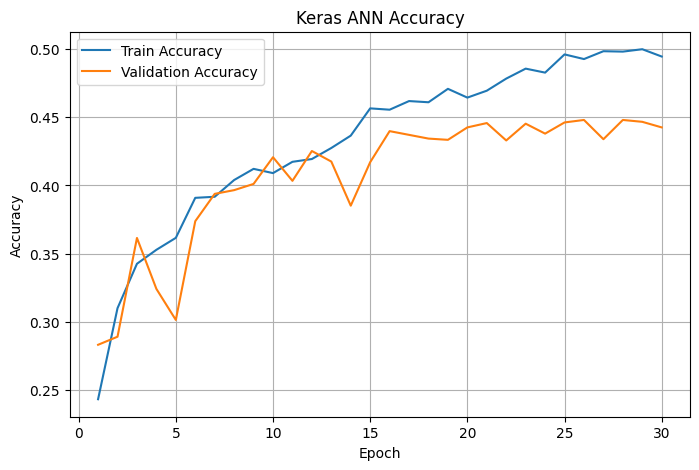

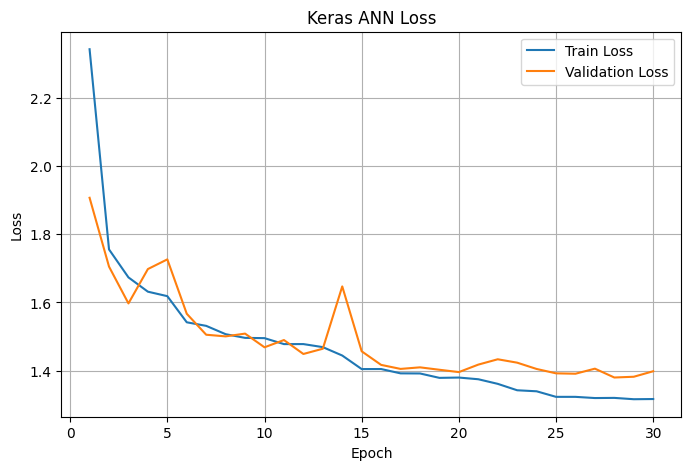

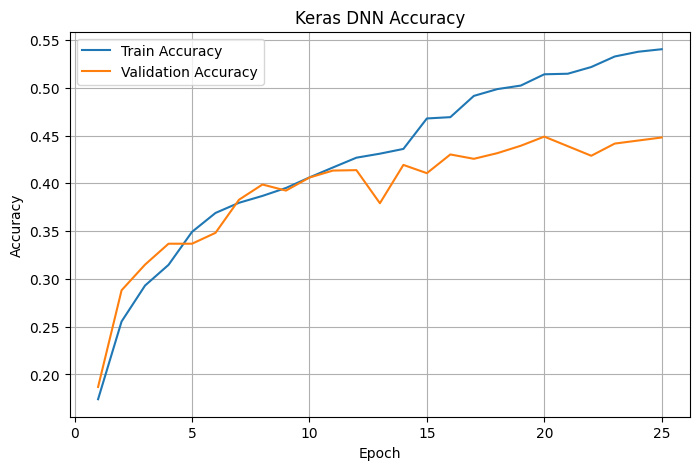

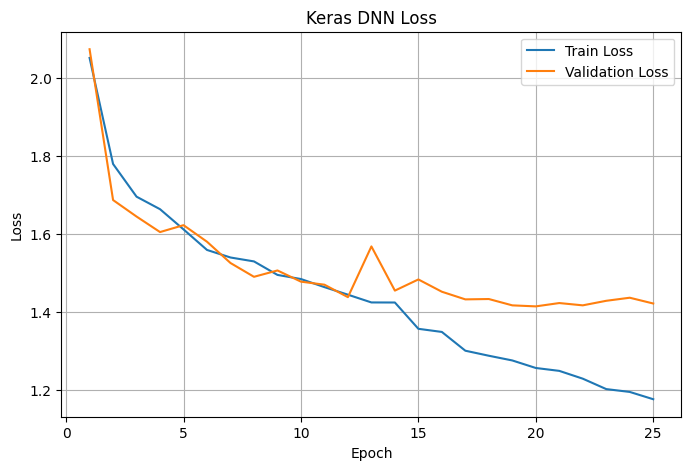

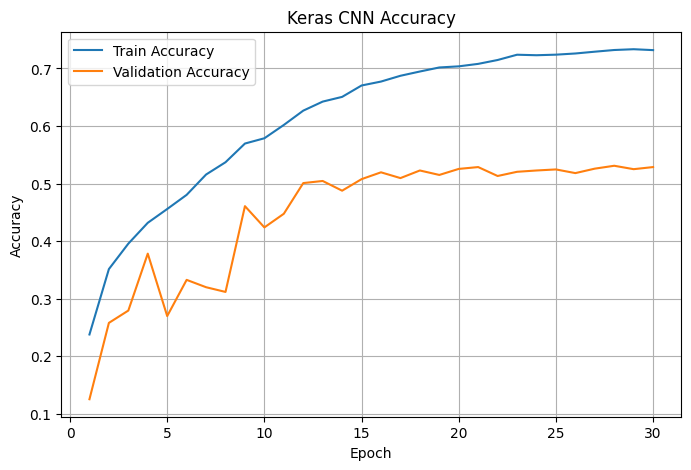

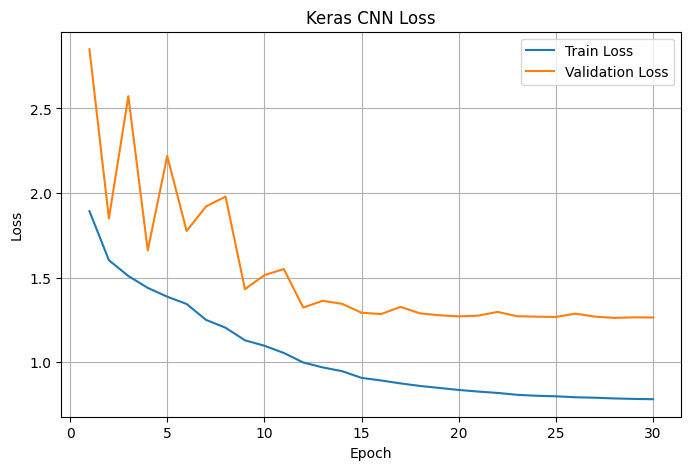

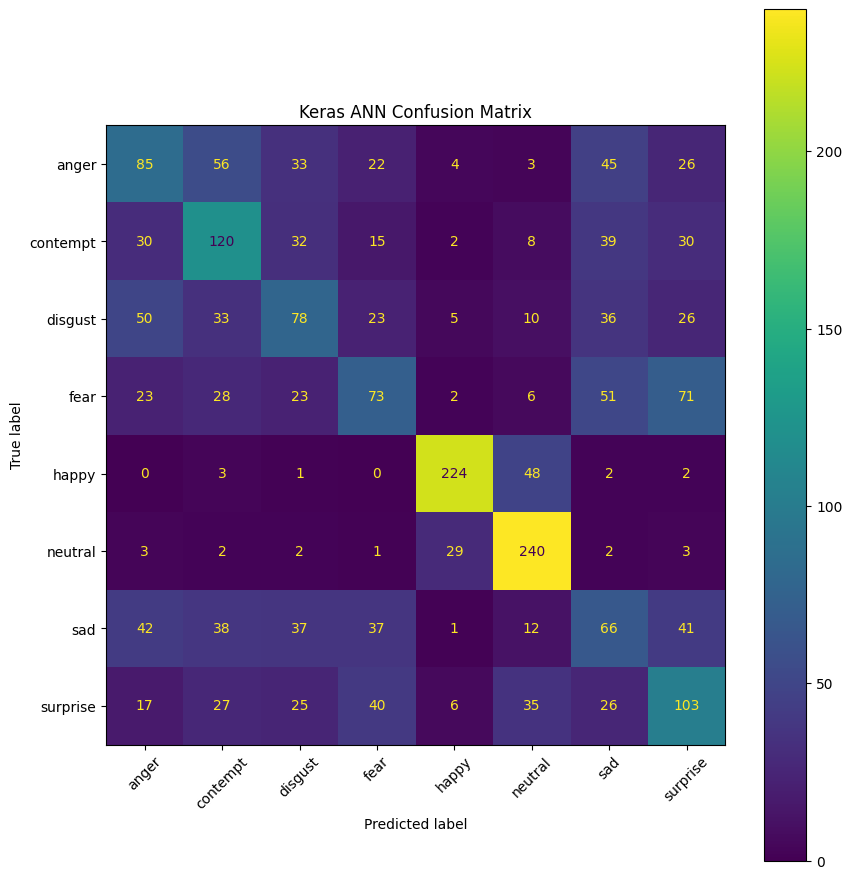

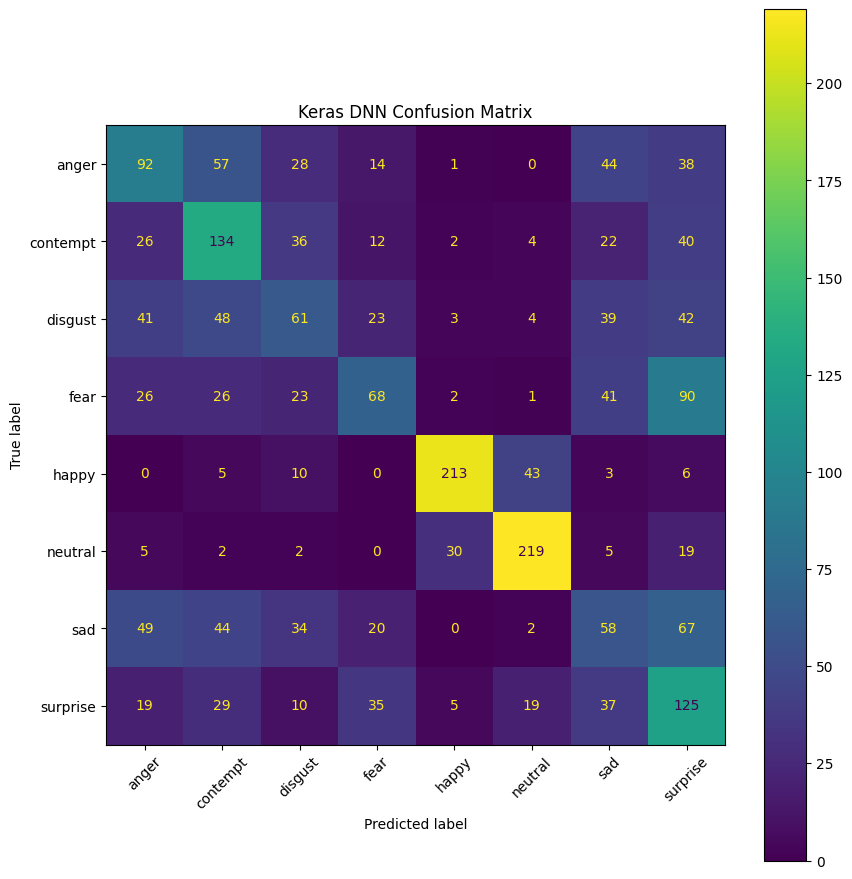

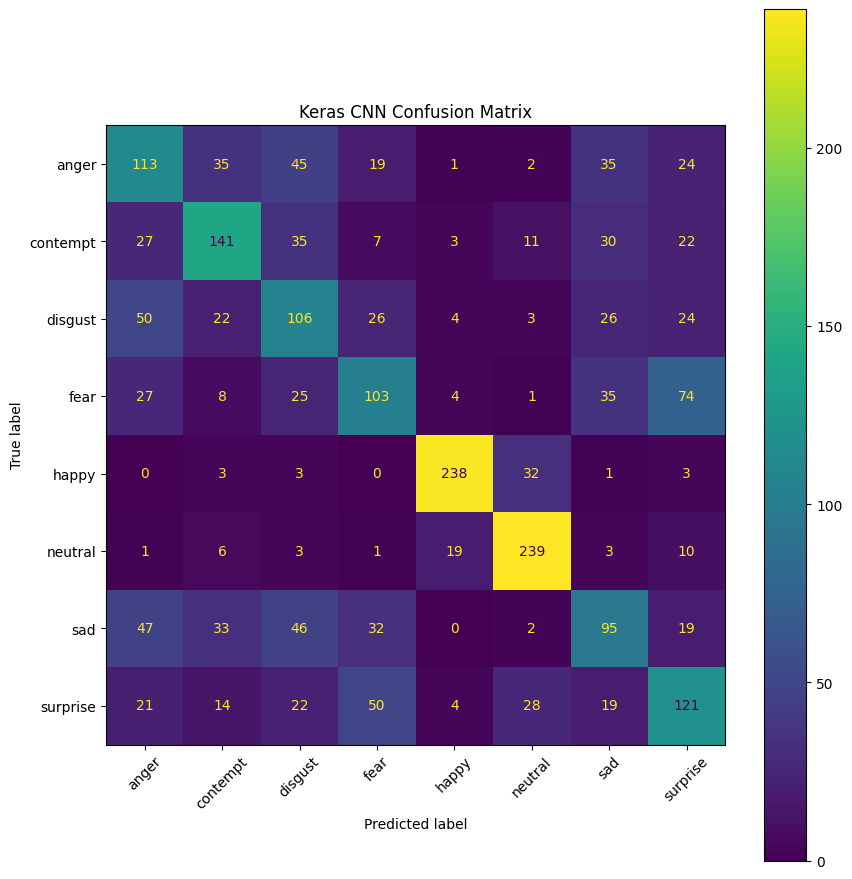


Keras ANN / DNN / CNN 최종 결과
Framework Model Input Size  Batch Size Optimizer  Learning Rate  Test Loss  Accuracy  Macro F1  Parameters  Epochs Trained
    Keras   ANN  128x128x1          32      Adam          0.001   1.426384  0.448933  0.438296     2098312              30
    Keras   DNN  128x128x1          32      Adam          0.001   1.436996  0.440309  0.434554     8555912              25
    Keras   CNN  128x128x1          32      Adam          0.001   1.261974  0.524739  0.520047      423208              30

결과 CSV 저장 완료: /content/keras_outputs/keras_results.csv

Best Model 저장 위치
ANN : /content/keras_outputs/keras_ann_best.keras
DNN : /content/keras_outputs/keras_dnn_best.keras
CNN : /content/keras_outputs/keras_cnn_best.keras

최종 모델 구조 요약

ANN
Input 128x128x1
→ Rescaling
→ Flatten
→ Dense 128 + ReLU
→ Dense 8 + Softmax

DNN
Input 128x128x1
→ Rescaling
→ Flatten
→ Dense 512 + ReLU
→ LayerNormalization
→ Dense 256 + ReLU
→ LayerNormalization
→ Dense 128 + ReLU
→ Dense 8 + Softma

In [ ]:
# ============================================================
# 어린이 얼굴 표정 이미지 분류
# Keras - ANN / DNN / CNN 비교 (수정본)
#
# [실행 전제]
# 이전 공통 코드에서 아래 작업이 완료된 상태
#
# 1. Google Drive 연결
# 2. real_emotion_dataset.zip → /content 복사
# 3. ZIP 압축 해제
# 4. TRAIN_DIR / VAL_DIR / TEST_DIR 설정
# 5. 클래스별 이미지 수 확인
#
# 이번 수정본의 핵심:
# - ANN: Augmentation 제거, Dropout 제거
# - DNN: Augmentation 제거, Dropout 제거, LayerNormalization 유지
# - CNN: Augmentation 제거, 마지막 Dropout 제거, BatchNormalization 유지
# - EarlyStopping / ReduceLROnPlateau에 min_delta=1e-4 추가
# - Test Loss를 최종 결과표에 추가
# - TP / FP / FN / TN 출력 및 CSV 저장 유지
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    multilabel_confusion_matrix
)


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 3. 기본 학습 설정
# ============================================================

IMG_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 30
LEARNING_RATE = 0.001

EARLY_STOPPING_PATIENCE = 5
LR_PATIENCE = 2
MIN_DELTA = 1e-4

CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ============================================================
# 4. GPU 확인
# ============================================================

print("=" * 70)
print("TensorFlow / GPU 확인")
print("=" * 70)

print("TensorFlow Version :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU 사용 가능 :", gpus)
else:
    print("GPU가 감지되지 않았습니다. Colab 런타임에서 GPU를 확인하세요.")


# ============================================================
# 5. 데이터 경로 확인
#
# TRAIN_DIR / VAL_DIR / TEST_DIR는
# 앞에서 실행한 공통 코드에서 정의되어 있어야 함
# ============================================================

print("\n" + "=" * 70)
print("Keras 학습 데이터 경로 확인")
print("=" * 70)

print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)

for path_name, path in [
    ("TRAIN_DIR", TRAIN_DIR),
    ("VAL_DIR", VAL_DIR),
    ("TEST_DIR", TEST_DIR)
]:
    if not os.path.isdir(path):
        raise FileNotFoundError(
            f"{path_name} 폴더를 찾을 수 없습니다.\n"
            f"경로: {path}"
        )

print("\n데이터 경로 확인 완료")


# ============================================================
# 6. Keras Dataset 생성
#
# 원본 1024x1024
# → 128x128 Resize
# → Grayscale
#
# 최종 입력 Shape:
# 128 x 128 x 1
#
# 중요:
# 이번 최종 비교 코드에서는 ANN/DNN/CNN 모두
# 동일한 입력 데이터를 사용하기 위해
# Data Augmentation을 적용하지 않음.
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)


# ============================================================
# 7. Dataset 정보 확인
# ============================================================

class_names = train_ds.class_names

print("\n" + "=" * 70)
print("Dataset 정보")
print("=" * 70)

print("클래스 :", class_names)
print("클래스 개수 :", len(class_names))

for images, labels in train_ds.take(1):
    print("\nImage Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)
    print("Pixel MIN :", tf.reduce_min(images).numpy())
    print("Pixel MAX :", tf.reduce_max(images).numpy())
    print("Pixel MEAN:", tf.reduce_mean(images).numpy())
    print("Labels    :", labels.numpy())


# ============================================================
# 8. Dataset Prefetch
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


# ============================================================
# 9. ANN 모델
#
# [수정]
# 기존:
# Augmentation
# → Rescaling
# → Flatten
# → Dense128
# → Dropout0.3
# → Dense8
#
# 수정:
# Rescaling
# → Flatten
# → Dense128
# → Dense8
#
# 이유:
# ANN은 은닉층이 1개뿐인 가장 단순한 baseline이므로
# Dropout + Augmentation으로 학습을 지나치게 억제하지 않도록 함.
# ============================================================

def build_ann():

    inputs = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1)
    )

    # 0~255 → 0~1
    x = layers.Rescaling(
        1.0 / 255.0
    )(inputs)

    # 128x128x1 → 16,384
    x = layers.Flatten()(x)

    # ANN의 단일 은닉층
    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    # Dropout 제거
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return models.Model(
        inputs=inputs,
        outputs=outputs,
        name="ANN"
    )


# ============================================================
# 10. DNN 모델
#
# [수정]
# 기존:
# Augmentation
# → Dense512 → LayerNorm → Dropout0.4
# → Dense256 → LayerNorm → Dropout0.3
# → Dense128 → Dropout0.2
#
# 수정:
# Dense512 → LayerNorm
# → Dense256 → LayerNorm
# → Dense128
#
# 이유:
# Ablation 결과에서 LayerNorm-only가 가장 좋은 성능을 보였고,
# Dropout은 학습을 크게 억제했음.
# ============================================================

def build_dnn():

    inputs = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1)
    )

    # 0~255 → 0~1
    x = layers.Rescaling(
        1.0 / 255.0
    )(inputs)

    # 128x128x1 → 16,384
    x = layers.Flatten()(x)

    # Hidden 1
    x = layers.Dense(
        512,
        activation="relu"
    )(x)

    x = layers.LayerNormalization()(x)

    # Hidden 2
    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.LayerNormalization()(x)

    # Hidden 3
    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    # Dropout 제거
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return models.Model(
        inputs=inputs,
        outputs=outputs,
        name="DNN"
    )


# ============================================================
# 11. CNN 모델
#
# [수정]
# 기존:
# Augmentation
# → Conv Blocks
# → GAP
# → Dense128
# → Dropout0.4
# → Dense8
#
# 수정:
# Rescaling
# → Conv Blocks
# → GAP
# → Dense128
# → Dense8
#
# 유지:
# BatchNormalization
#
# 이유:
# BatchNormalization은 CNN의 각 Conv Block 학습을 안정화하는
# 표준적인 구성이라 유지.
# 반면, 아직 CNN에서 Dropout0.4의 필요성이 검증되지 않았으므로
# 비교 baseline에서는 제거.
# ============================================================

def build_cnn():

    inputs = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1)
    )

    # 0~255 → 0~1
    x = layers.Rescaling(
        1.0 / 255.0
    )(inputs)

    # --------------------------------------------------------
    # Conv Block 1
    # 128x128x1 → 64x64x32
    # --------------------------------------------------------
    x = layers.Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)

    # --------------------------------------------------------
    # Conv Block 2
    # 64x64x32 → 32x32x64
    # --------------------------------------------------------
    x = layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)

    # --------------------------------------------------------
    # Conv Block 3
    # 32x32x64 → 16x16x128
    # --------------------------------------------------------
    x = layers.Conv2D(
        filters=128,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)

    # --------------------------------------------------------
    # Conv Block 4
    # 16x16x128 → 8x8x256
    # --------------------------------------------------------
    x = layers.Conv2D(
        filters=256,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)

    # --------------------------------------------------------
    # 8x8x256 → 256
    # --------------------------------------------------------
    x = layers.GlobalAveragePooling2D()(x)

    # 분류용 Dense
    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    # Dropout 제거
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return models.Model(
        inputs=inputs,
        outputs=outputs,
        name="CNN"
    )


# ============================================================
# 12. 모델 생성
# ============================================================

ann = build_ann()
dnn = build_dnn()
cnn = build_cnn()


# ============================================================
# 13. 모델 구조 확인
# ============================================================

for model_name, model in [
    ("ANN", ann),
    ("DNN", dnn),
    ("CNN", cnn)
]:
    print("\n" + "=" * 70)
    print(f"{model_name} 구조")
    print("=" * 70)

    model.summary()

    print(
        f"\n{model_name} Parameters : "
        f"{model.count_params():,}"
    )


# ============================================================
# 14. 결과 저장 폴더
# ============================================================

OUTPUT_DIR = "/content/keras_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print(
    "\n모델 및 결과 저장 폴더:",
    OUTPUT_DIR
)


# ============================================================
# 15. 공통 학습 함수
#
# ANN / DNN / CNN 모두 동일한 조건:
#
# Optimizer = Adam
# LR = 0.001
# Epoch = 최대 30
# Loss = SparseCategoricalCrossentropy
#
# Callback은 유지하되
# min_delta=1e-4를 추가하여
# 의미 없는 초미세 val_loss 변화는 개선으로 보지 않도록 수정.
# ============================================================

def train_model(model, model_name):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    checkpoint_path = os.path.join(
        OUTPUT_DIR,
        f"{model_name}_best.keras"
    )

    callbacks = [

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            min_delta=MIN_DELTA,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=LR_PATIENCE,
            min_delta=MIN_DELTA,
            min_lr=1e-6,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1
        )
    ]

    print("\n" + "=" * 70)
    print(f"{model_name.upper()} 학습 시작")
    print("=" * 70)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    return history


# ============================================================
# 16. ANN / DNN / CNN 학습
# ============================================================

ann_history = train_model(
    ann,
    "keras_ann"
)

dnn_history = train_model(
    dnn,
    "keras_dnn"
)

cnn_history = train_model(
    cnn,
    "keras_cnn"
)


# ============================================================
# 17. 평가 함수
#
# 출력:
# - Test Loss
# - Accuracy
# - Macro F1
# - Classification Report
# - 클래스별 TP / FP / FN / TN
#
# 저장:
# - TP/FP/FN/TN CSV
# ============================================================

def evaluate_model(model, model_name):

    # --------------------------------------------------------
    # 1) Keras evaluate로 Test Loss 확인
    # --------------------------------------------------------
    test_loss, keras_test_accuracy = model.evaluate(
        test_ds,
        verbose=0
    )

    # --------------------------------------------------------
    # 2) 전체 Test Dataset 예측
    # --------------------------------------------------------
    y_true = []
    y_pred = []

    for images, labels in test_ds:

        predictions = model.predict(
            images,
            verbose=0
        )

        predicted_classes = np.argmax(
            predictions,
            axis=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predicted_classes
        )

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # --------------------------------------------------------
    # 3) Accuracy / Macro F1
    # --------------------------------------------------------
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    print(
        f"Test Loss : {test_loss:.4f}"
    )

    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Macro F1  : {macro_f1:.4f}"
    )

    # --------------------------------------------------------
    # 4) Classification Report
    # --------------------------------------------------------
    print("\nClassification Report\n")

    print(
        classification_report(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    # --------------------------------------------------------
    # 5) TP / FP / FN / TN
    #    One-vs-Rest 방식
    # --------------------------------------------------------
    matrices = multilabel_confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES))
    )

    print("\n" + "=" * 80)
    print("클래스별 TP / FP / FN / TN")
    print("=" * 80)

    confusion_values = []

    for i, class_name in enumerate(class_names):

        # [[TN, FP],
        #  [FN, TP]]
        tn, fp, fn, tp = matrices[i].ravel()

        print(
            f"{class_name:10s} | "
            f"TP: {tp:4d} | "
            f"FP: {fp:4d} | "
            f"FN: {fn:4d} | "
            f"TN: {tn:4d}"
        )

        confusion_values.append({
            "Class": class_name,
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn)
        })

    confusion_df = pd.DataFrame(
        confusion_values
    )

    print("\nTP / FP / FN / TN 표\n")

    print(
        confusion_df.to_string(
            index=False
        )
    )

    # CSV 저장
    safe_name = (
        model_name
        .replace(" ", "_")
        .lower()
    )

    confusion_csv_path = os.path.join(
        OUTPUT_DIR,
        f"{safe_name}_tp_fp_fn_tn.csv"
    )

    confusion_df.to_csv(
        confusion_csv_path,
        index=False
    )

    print(
        "\nTP/FP/FN/TN CSV 저장:",
        confusion_csv_path
    )

    return (
        test_loss,
        accuracy,
        macro_f1,
        y_true,
        y_pred,
        confusion_df
    )


# ============================================================
# 18. ANN / DNN / CNN 평가
# ============================================================

(
    ann_test_loss,
    ann_acc,
    ann_f1,
    ann_true,
    ann_pred,
    ann_confusion
) = evaluate_model(
    ann,
    "Keras ANN"
)


(
    dnn_test_loss,
    dnn_acc,
    dnn_f1,
    dnn_true,
    dnn_pred,
    dnn_confusion
) = evaluate_model(
    dnn,
    "Keras DNN"
)


(
    cnn_test_loss,
    cnn_acc,
    cnn_f1,
    cnn_true,
    cnn_pred,
    cnn_confusion
) = evaluate_model(
    cnn,
    "Keras CNN"
)


# ============================================================
# 19. 학습 그래프 함수
# ============================================================

def plot_history(
    history,
    model_name
):

    epochs_range = range(
        1,
        len(history.history["accuracy"]) + 1
    )

    # Accuracy
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs_range,
        history.history["accuracy"],
        label="Train Accuracy"
    )

    plt.plot(
        epochs_range,
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy")

    plt.legend()
    plt.grid()
    plt.show()

    # Loss
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs_range,
        history.history["loss"],
        label="Train Loss"
    )

    plt.plot(
        epochs_range,
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss")

    plt.legend()
    plt.grid()
    plt.show()


# ============================================================
# 20. ANN / DNN / CNN 학습 그래프
# ============================================================

plot_history(
    ann_history,
    "Keras ANN"
)

plot_history(
    dnn_history,
    "Keras DNN"
)

plot_history(
    cnn_history,
    "Keras CNN"
)


# ============================================================
# 21. Confusion Matrix 함수
# ============================================================

def plot_confusion(
    y_true,
    y_pred,
    model_name
):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES))
    )

    fig, ax = plt.subplots(
        figsize=(9, 9)
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d"
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 22. Confusion Matrix 출력
# ============================================================

plot_confusion(
    ann_true,
    ann_pred,
    "Keras ANN"
)

plot_confusion(
    dnn_true,
    dnn_pred,
    "Keras DNN"
)

plot_confusion(
    cnn_true,
    cnn_pred,
    "Keras CNN"
)


# ============================================================
# 23. 최종 결과 DataFrame
# ============================================================

keras_results = pd.DataFrame({

    "Framework": [
        "Keras",
        "Keras",
        "Keras"
    ],

    "Model": [
        "ANN",
        "DNN",
        "CNN"
    ],

    "Input Size": [
        "128x128x1",
        "128x128x1",
        "128x128x1"
    ],

    "Batch Size": [
        BATCH_SIZE,
        BATCH_SIZE,
        BATCH_SIZE
    ],

    "Optimizer": [
        "Adam",
        "Adam",
        "Adam"
    ],

    "Learning Rate": [
        LEARNING_RATE,
        LEARNING_RATE,
        LEARNING_RATE
    ],

    "Test Loss": [
        ann_test_loss,
        dnn_test_loss,
        cnn_test_loss
    ],

    "Accuracy": [
        ann_acc,
        dnn_acc,
        cnn_acc
    ],

    "Macro F1": [
        ann_f1,
        dnn_f1,
        cnn_f1
    ],

    "Parameters": [
        ann.count_params(),
        dnn.count_params(),
        cnn.count_params()
    ],

    "Epochs Trained": [
        len(
            ann_history.history["loss"]
        ),
        len(
            dnn_history.history["loss"]
        ),
        len(
            cnn_history.history["loss"]
        )
    ]
})


# ============================================================
# 24. 최종 결과 출력
# ============================================================

print("\n" + "=" * 100)
print("Keras ANN / DNN / CNN 최종 결과")
print("=" * 100)

print(
    keras_results.to_string(
        index=False
    )
)


# ============================================================
# 25. 최종 결과 CSV 저장
# ============================================================

RESULT_CSV = os.path.join(
    OUTPUT_DIR,
    "keras_results.csv"
)

keras_results.to_csv(
    RESULT_CSV,
    index=False
)

print(
    "\n결과 CSV 저장 완료:",
    RESULT_CSV
)


# ============================================================
# 26. Best Model 저장 위치
# ============================================================

print("\n" + "=" * 70)
print("Best Model 저장 위치")
print("=" * 70)

print(
    "ANN :",
    os.path.join(
        OUTPUT_DIR,
        "keras_ann_best.keras"
    )
)

print(
    "DNN :",
    os.path.join(
        OUTPUT_DIR,
        "keras_dnn_best.keras"
    )
)

print(
    "CNN :",
    os.path.join(
        OUTPUT_DIR,
        "keras_cnn_best.keras"
    )
)


# ============================================================
# 27. 모델별 최종 구조 요약
# ============================================================

print("\n" + "=" * 70)
print("최종 모델 구조 요약")
print("=" * 70)

print("""
ANN
Input 128x128x1
→ Rescaling
→ Flatten
→ Dense 128 + ReLU
→ Dense 8 + Softmax

DNN
Input 128x128x1
→ Rescaling
→ Flatten
→ Dense 512 + ReLU
→ LayerNormalization
→ Dense 256 + ReLU
→ LayerNormalization
→ Dense 128 + ReLU
→ Dense 8 + Softmax

CNN
Input 128x128x1
→ Rescaling
→ Conv32 + BatchNorm + ReLU + MaxPool
→ Conv64 + BatchNorm + ReLU + MaxPool
→ Conv128 + BatchNorm + ReLU + MaxPool
→ Conv256 + BatchNorm + ReLU + MaxPool
→ GlobalAveragePooling
→ Dense128 + ReLU
→ Dense8 + Softmax
""")


TensorFlow / GPU 확인
TensorFlow Version: 2.20.0
GPU 사용 가능:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


CNN Dataset 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test

데이터 경로 확인 완료
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.


Dataset 정보
Class:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class 개수: 8

Image Shape:
(32, 128, 128, 1)

Label Shape:
(32,)

Pixel MIN:
0.0

Pixel MAX:
255.0

Pixel MEAN:
113.415085


CNN + Augmentation 구조


Model: "CNN_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_augmentation (Sequential)   │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 423,208 (1.61 MB)

 Trainable params: 422,248 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)



CNN Parameters: 423,208

결과 저장 폴더:
/content/keras_cnn_augmentation_outputs


CNN + Augmentation 학습 시작
Epoch 1/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1708 - loss: 2.0715
Epoch 1: val_loss improved from None to 2.21605, saving model to /content/keras_cnn_augmentation_outputs/keras_cnn_augmentation_best.keras

Epoch 1: finished saving model to /content/keras_cnn_augmentation_outputs/keras_cnn_augmentation_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.2057 - loss: 1.9691 - val_accuracy: 0.1399 - val_loss: 2.2161 - learning_rate: 0.0010
Epoch 2/30
319/321 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2890 - loss: 1.7399
Epoch 2: val_loss improved from 2.21605 to 2.06956, saving model to /content/keras_cnn_augmentation_outputs/keras_cnn_augmentation_best.keras

Epoch 2: finished saving model to /content/keras_cnn_augmentation_outputs/keras_cnn_augmentation_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.3069 - loss: 1.7010 - v

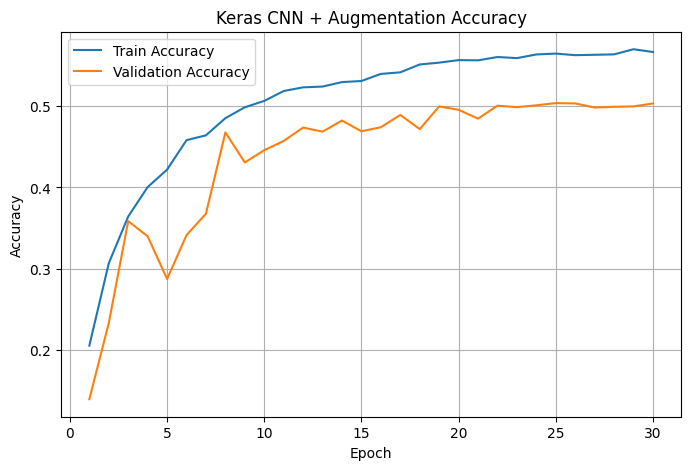

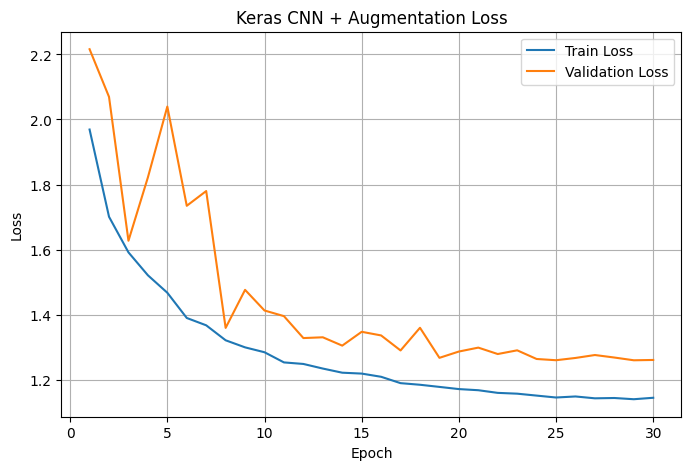

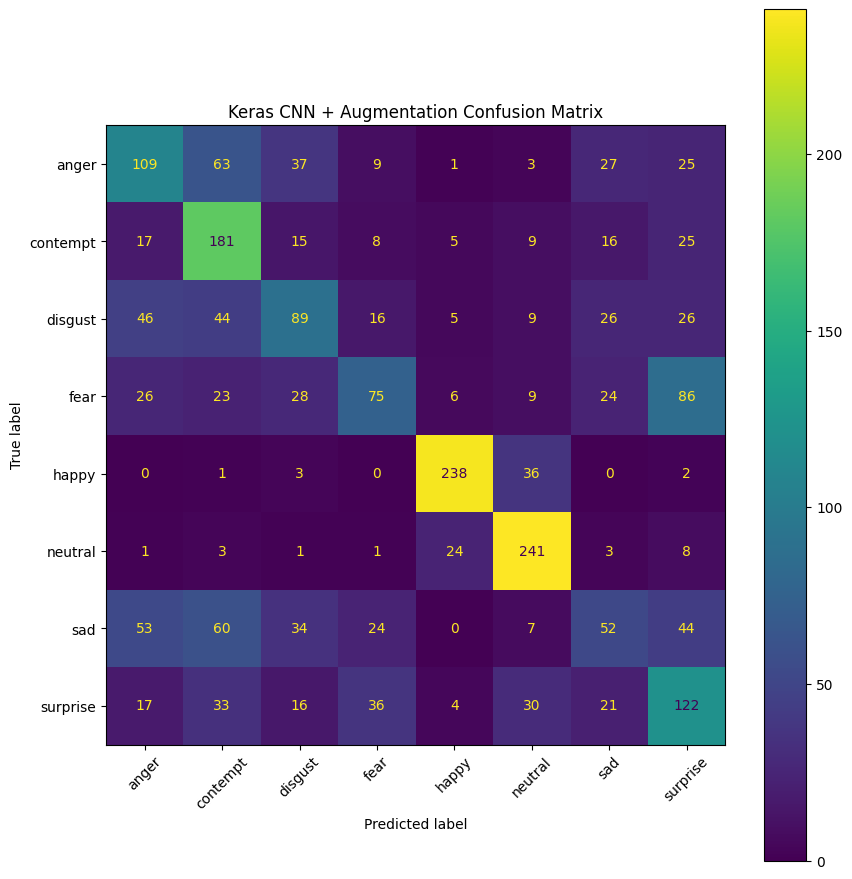



Keras CNN + Augmentation 최종 결과
Framework              Model Input Size Color Mode    Augmentation Dropout  Batch Size Optimizer  Learning Rate  Test Loss  Accuracy  Macro F1  Parameters  Best Epoch  Epochs Trained
    Keras CNN + Augmentation  128x128x1  Grayscale Flip + Rotation    None          32      Adam          0.001   1.288484  0.502497  0.485059      423208          29              30

결과 CSV 저장 완료:
/content/keras_cnn_augmentation_outputs/keras_cnn_augmentation_results.csv


Best CNN Model 저장 위치
/content/keras_cnn_augmentation_outputs/keras_cnn_augmentation_best.keras


기존 CNN과 비교
기존 CNN
  Color        : Grayscale
  Augmentation : X
  Dropout      : X
  Test Accuracy: 0.524739
  Macro F1     : 0.520047


이번 CNN
  Color        : Grayscale
  Augmentation : O
  Dropout      : X
  Test Accuracy: 0.502497
  Macro F1     : 0.485059


In [ ]:
#CNN Baseline + Augmentation
# ============================================================
# 어린이 얼굴 표정 이미지 분류
# Keras CNN - Augmentation Only 실험
#
# 목적:
# 현재 CNN에서 발생한 Train / Validation 성능 격차가
# Data Augmentation으로 감소하는지 확인
#
# ============================================================
#
# [현재 실험 조건]
#
# 입력 이미지:
# 128 x 128 x 1
# Grayscale
#
# Data Augmentation:
# O
#
#   - RandomHorizontalFlip
#   - RandomRotation 약 ±5도
#
# Dropout:
# X
#
# BatchNormalization:
# O
#
# Optimizer:
# Adam
#
# Learning Rate:
# 0.001
#
# Batch Size:
# 32
#
# Epoch:
# 최대 30
#
# ============================================================
#
# [실행 전제]
#
# 앞의 공통 데이터 준비 코드에서
#
# TRAIN_DIR
# VAL_DIR
# TEST_DIR
#
# 세 변수가 이미 정의되어 있어야 함
#
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import (
    layers,
    models
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    multilabel_confusion_matrix
)


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. 기본 설정
# ============================================================

IMG_SIZE = 128

BATCH_SIZE = 32

NUM_CLASSES = 8

EPOCHS = 30

LEARNING_RATE = 0.001


# Early Stopping
EARLY_STOPPING_PATIENCE = 5


# LR Scheduler
LR_PATIENCE = 2


# 너무 작은 val_loss 변화는
# 실질적인 개선으로 판단하지 않도록 설정
MIN_DELTA = 1e-4


# ============================================================
# 클래스 순서
# ============================================================

CLASS_NAMES = [

    "anger",

    "contempt",

    "disgust",

    "fear",

    "happy",

    "neutral",

    "sad",

    "surprise"
]


# ============================================================
# 4. GPU 확인
# ============================================================

print("=" * 70)

print(
    "TensorFlow / GPU 확인"
)

print("=" * 70)


print(
    "TensorFlow Version:",
    tf.__version__
)


gpus = tf.config.list_physical_devices(
    "GPU"
)


if gpus:

    print(
        "GPU 사용 가능:"
    )

    for gpu in gpus:

        print(
            gpu
        )

else:

    print(
        "GPU가 감지되지 않았습니다."
    )


# ============================================================
# 5. 데이터 경로 확인
# ============================================================

print("\n")

print("=" * 70)

print(
    "CNN Dataset 경로 확인"
)

print("=" * 70)


print(
    "TRAIN_DIR :",
    TRAIN_DIR
)

print(
    "VAL_DIR   :",
    VAL_DIR
)

print(
    "TEST_DIR  :",
    TEST_DIR
)


for path_name, path in [

    (
        "TRAIN_DIR",
        TRAIN_DIR
    ),

    (
        "VAL_DIR",
        VAL_DIR
    ),

    (
        "TEST_DIR",
        TEST_DIR
    )

]:

    if not os.path.isdir(
        path
    ):

        raise FileNotFoundError(

            f"{path_name}를 찾을 수 없습니다.\n"
            f"경로: {path}"

        )


print(
    "\n데이터 경로 확인 완료"
)


# ============================================================
# 6. Train Dataset
#
# 원본:
# 1024 x 1024 RGB
#
# ↓
#
# Resize:
# 128 x 128
#
# ↓
#
# Grayscale:
# 128 x 128 x 1
#
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    class_names=CLASS_NAMES,

    image_size=(

        IMG_SIZE,

        IMG_SIZE

    ),

    # 이번 실험에서는
    # RGB로 바꾸지 않음
    #
    # 기존 CNN과 동일하게 Grayscale 유지
    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=True,

    seed=SEED
)


# ============================================================
# 7. Validation Dataset
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(

        IMG_SIZE,

        IMG_SIZE

    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    # Validation은 순서를 섞지 않음
    shuffle=False
)


# ============================================================
# 8. Test Dataset
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(

        IMG_SIZE,

        IMG_SIZE

    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    # Test도 순서를 섞지 않음
    shuffle=False
)


# ============================================================
# 9. Dataset 정보 확인
# ============================================================

class_names = train_ds.class_names


print("\n")

print("=" * 70)

print(
    "Dataset 정보"
)

print("=" * 70)


print(
    "Class:"
)

print(
    class_names
)


print(
    "\nClass 개수:",
    len(
        class_names
    )
)


# ============================================================
# Batch 하나 확인
# ============================================================

for images, labels in train_ds.take(
    1
):

    print(
        "\nImage Shape:"
    )

    print(
        images.shape
    )


    print(
        "\nLabel Shape:"
    )

    print(
        labels.shape
    )


    print(
        "\nPixel MIN:"
    )

    print(
        tf.reduce_min(
            images
        ).numpy()
    )


    print(
        "\nPixel MAX:"
    )

    print(
        tf.reduce_max(
            images
        ).numpy()
    )


    print(
        "\nPixel MEAN:"
    )

    print(
        tf.reduce_mean(
            images
        ).numpy()
    )


# 정상:
#
# Image Shape
# (32, 128, 128, 1)
#
# Pixel:
# 0 ~ 255


# ============================================================
# 10. Dataset Prefetch
#
# GPU가 학습하는 동안
# CPU에서 다음 Batch를 미리 준비
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(
    AUTOTUNE
)


val_ds = val_ds.prefetch(
    AUTOTUNE
)


test_ds = test_ds.prefetch(
    AUTOTUNE
)


# ============================================================
# 11. Data Augmentation
#
# 이번 실험의 핵심 변경점
#
# Train에서만 활성화
#
# Validation:
# 자동 비활성화
#
# Test:
# 자동 비활성화
#
# ============================================================

def get_augmentation():

    return tf.keras.Sequential(

        [

            # =================================================
            # 좌우 반전
            #
            # 얼굴의 좌우 방향 차이에
            # 모델이 과도하게 의존하는 것을 방지
            # =================================================

            layers.RandomFlip(
                "horizontal"
            ),


            # =================================================
            # 약 ±5도 회전
            #
            # RandomRotation에서
            #
            # 5 / 360
            #
            # ≈ 0.014
            #
            # 얼굴 각도가 조금 달라져도
            # 같은 표정으로 인식하도록 학습
            # =================================================

            layers.RandomRotation(
                0.014
            )

        ],

        name="cnn_augmentation"
    )


# ============================================================
# 12. CNN Model
#
#
# Input
# 128 x 128 x 1
#
# ↓
#
# Augmentation
#
# ↓
#
# Rescaling
#
# ↓
#
# Conv32
# BatchNorm
# ReLU
# MaxPool
#
# ↓
#
# Conv64
# BatchNorm
# ReLU
# MaxPool
#
# ↓
#
# Conv128
# BatchNorm
# ReLU
# MaxPool
#
# ↓
#
# Conv256
# BatchNorm
# ReLU
# MaxPool
#
# ↓
#
# Global Average Pooling
#
# ↓
#
# Dense128
#
# ↓
#
# Dense8
#
#
# IMPORTANT
#
# Dropout 없음
#
# 이번 실험은
# Augmentation 하나의 효과만 보기 위함
#
# ============================================================

def build_cnn_augmentation():

    # ========================================================
    # Input
    # ========================================================

    inputs = layers.Input(

        shape=(

            IMG_SIZE,

            IMG_SIZE,

            1

        )

    )


    # ========================================================
    # Data Augmentation
    #
    # 이번 실험에서 추가한 부분
    # ========================================================

    x = get_augmentation()(
        inputs
    )


    # ========================================================
    # Rescaling
    #
    # 0 ~ 255
    #
    # ↓
    #
    # 0 ~ 1
    # ========================================================

    x = layers.Rescaling(

        1.0 / 255.0

    )(x)


    # ========================================================
    # Conv Block 1
    #
    # Input
    #
    # 128 x 128 x 1
    #
    # ↓ Conv
    #
    # 128 x 128 x 32
    #
    # ↓ MaxPool
    #
    # 64 x 64 x 32
    # ========================================================

    x = layers.Conv2D(

        filters=32,

        kernel_size=3,

        padding="same",

        # BatchNorm을 사용하므로
        # Conv bias는 불필요
        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 2
    #
    # 64 x 64 x 32
    #
    # ↓
    #
    # 32 x 32 x 64
    # ========================================================

    x = layers.Conv2D(

        filters=64,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 3
    #
    # 32 x 32 x 64
    #
    # ↓
    #
    # 16 x 16 x 128
    # ========================================================

    x = layers.Conv2D(

        filters=128,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 4
    #
    # 16 x 16 x 128
    #
    # ↓
    #
    # 8 x 8 x 256
    # ========================================================

    x = layers.Conv2D(

        filters=256,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Global Average Pooling
    #
    # 8 x 8 x 256
    #
    # ↓
    #
    # 256
    #
    # Flatten 대신 GAP 사용
    #
    # Parameter 증가 억제
    # ========================================================

    x = layers.GlobalAveragePooling2D()(x)


    # ========================================================
    # Dense Layer
    # ========================================================

    x = layers.Dense(

        128,

        activation="relu"

    )(x)


    # ========================================================
    # IMPORTANT
    #
    # Dropout 없음
    #
    # Augmentation 단독 효과만 비교하기 위함
    # ========================================================


    # ========================================================
    # Output
    #
    # 8개의 얼굴 표정 클래스
    # ========================================================

    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax"

    )(x)


    # ========================================================
    # Model
    # ========================================================

    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="CNN_Augmentation"

    )


    return model


# ============================================================
# 13. 모델 생성
# ============================================================

cnn = build_cnn_augmentation()


# ============================================================
# 14. Model Summary
# ============================================================

print("\n")

print("=" * 70)

print(
    "CNN + Augmentation 구조"
)

print("=" * 70)


cnn.summary()


print("\n")

print(
    f"CNN Parameters: "
    f"{cnn.count_params():,}"
)


# ============================================================
# 15. 출력 폴더
#
# 기존 CNN 결과를 덮어쓰지 않도록
# 별도 폴더 사용
# ============================================================

OUTPUT_DIR = (
    "/content/keras_cnn_augmentation_outputs"
)


os.makedirs(

    OUTPUT_DIR,

    exist_ok=True
)


print(
    "\n결과 저장 폴더:"
)

print(
    OUTPUT_DIR
)


# ============================================================
# 16. Compile
# ============================================================

cnn.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss=(
        "sparse_categorical_crossentropy"
    ),

    metrics=[

        "accuracy"

    ]
)


# ============================================================
# 17. Callback
# ============================================================

BEST_MODEL_PATH = os.path.join(

    OUTPUT_DIR,

    "keras_cnn_augmentation_best.keras"
)


callbacks = [


    # ========================================================
    # EarlyStopping
    #
    # val_loss가 5 epoch 동안
    # 의미 있게 개선되지 않으면 종료
    #
    # 최종적으로 가장 좋은 weight 복원
    # ========================================================

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        mode="min",

        patience=(
            EARLY_STOPPING_PATIENCE
        ),

        min_delta=MIN_DELTA,

        restore_best_weights=True,

        verbose=1

    ),


    # ========================================================
    # ReduceLROnPlateau
    #
    # val_loss가 2 epoch 동안 개선되지 않으면
    #
    # LR
    #
    # 0.001
    # ↓
    # 0.0005
    # ↓
    # ...
    # ========================================================

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=LR_PATIENCE,

        min_delta=MIN_DELTA,

        min_lr=1e-6,

        verbose=1

    ),


    # ========================================================
    # Best Model 저장
    # ========================================================

    tf.keras.callbacks.ModelCheckpoint(

        filepath=BEST_MODEL_PATH,

        monitor="val_loss",

        mode="min",

        save_best_only=True,

        verbose=1

    )

]


# ============================================================
# 18. CNN 학습
# ============================================================

print("\n")

print("=" * 70)

print(
    "CNN + Augmentation 학습 시작"
)

print("=" * 70)


cnn_history = cnn.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1
)


# ============================================================
# 19. 실제 학습 Epoch
# ============================================================

epochs_trained = len(

    cnn_history.history[
        "loss"
    ]

)


print("\n")

print(
    "실제 학습 Epoch:"
)

print(
    epochs_trained
)


# ============================================================
# 20. Best Epoch 확인
# ============================================================

best_epoch = (

    np.argmin(

        cnn_history.history[
            "val_loss"
        ]

    )

    + 1

)


best_val_loss = np.min(

    cnn_history.history[
        "val_loss"
    ]

)


best_val_accuracy = (

    cnn_history.history[
        "val_accuracy"
    ][
        best_epoch - 1
    ]

)


print("\n")

print("=" * 70)

print(
    "Best Epoch 정보"
)

print("=" * 70)


print(
    "Best Epoch:",
    best_epoch
)


print(
    f"Best Validation Loss:"
    f" {best_val_loss:.4f}"
)


print(
    f"Best Epoch Validation Accuracy:"
    f" {best_val_accuracy:.4f}"
)


# ============================================================
# 21. Test 평가 함수
# ============================================================

def evaluate_cnn(
    model
):

    # ========================================================
    # Keras Test Loss / Accuracy
    # ========================================================

    test_loss, keras_accuracy = (
        model.evaluate(

            test_ds,

            verbose=0

        )
    )


    # ========================================================
    # 전체 예측 결과 저장
    # ========================================================

    y_true = []

    y_pred = []


    for images, labels in test_ds:

        predictions = model.predict(

            images,

            verbose=0

        )


        predicted_classes = np.argmax(

            predictions,

            axis=1

        )


        y_true.extend(

            labels.numpy()

        )


        y_pred.extend(

            predicted_classes

        )


    y_true = np.array(
        y_true
    )


    y_pred = np.array(
        y_pred
    )


    # ========================================================
    # Accuracy
    # ========================================================

    accuracy = accuracy_score(

        y_true,

        y_pred

    )


    # ========================================================
    # Macro F1
    # ========================================================

    macro_f1 = f1_score(

        y_true,

        y_pred,

        average="macro"

    )


    print("\n")

    print("=" * 80)

    print(
        "Keras CNN + Augmentation Test"
    )

    print("=" * 80)


    print(
        f"Test Loss : "
        f"{test_loss:.4f}"
    )


    print(
        f"Accuracy  : "
        f"{accuracy:.4f}"
    )


    print(
        f"Macro F1  : "
        f"{macro_f1:.4f}"
    )


    # ========================================================
    # Classification Report
    # ========================================================

    print(
        "\nClassification Report\n"
    )


    print(

        classification_report(

            y_true,

            y_pred,

            labels=list(
                range(
                    NUM_CLASSES
                )
            ),

            target_names=class_names,

            digits=4,

            zero_division=0

        )

    )


    # ========================================================
    # TP / FP / FN / TN
    #
    # One-vs-Rest 방식
    # ========================================================

    matrices = (
        multilabel_confusion_matrix(

            y_true,

            y_pred,

            labels=list(
                range(
                    NUM_CLASSES
                )
            )

        )
    )


    print("\n")

    print("=" * 85)

    print(
        "클래스별 TP / FP / FN / TN"
    )

    print("=" * 85)


    confusion_values = []


    for i, class_name in enumerate(
        class_names
    ):

        tn, fp, fn, tp = (
            matrices[i].ravel()
        )


        print(

            f"{class_name:10s} | "

            f"TP: {tp:4d} | "

            f"FP: {fp:4d} | "

            f"FN: {fn:4d} | "

            f"TN: {tn:4d}"

        )


        confusion_values.append(

            {

                "Class":
                    class_name,

                "TP":
                    int(tp),

                "FP":
                    int(fp),

                "FN":
                    int(fn),

                "TN":
                    int(tn)

            }

        )


    confusion_df = pd.DataFrame(
        confusion_values
    )


    # ========================================================
    # TP / FP / FN / TN CSV
    # ========================================================

    confusion_csv_path = os.path.join(

        OUTPUT_DIR,

        (
            "cnn_augmentation_"
            "tp_fp_fn_tn.csv"
        )

    )


    confusion_df.to_csv(

        confusion_csv_path,

        index=False

    )


    print(
        "\nTP / FP / FN / TN CSV 저장:"
    )

    print(
        confusion_csv_path
    )


    return (

        test_loss,

        accuracy,

        macro_f1,

        y_true,

        y_pred,

        confusion_df

    )


# ============================================================
# 22. Test 평가
# ============================================================

(

    cnn_test_loss,

    cnn_accuracy,

    cnn_macro_f1,

    cnn_true,

    cnn_pred,

    cnn_confusion

) = evaluate_cnn(
    cnn
)


# ============================================================
# 23. Accuracy Graph
# ============================================================

epochs_range = range(

    1,

    len(
        cnn_history.history[
            "accuracy"
        ]
    ) + 1

)


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    cnn_history.history[
        "accuracy"
    ],

    label="Train Accuracy"

)


plt.plot(

    epochs_range,

    cnn_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"

)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "Keras CNN + Augmentation Accuracy"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# 24. Loss Graph
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    cnn_history.history[
        "loss"
    ],

    label="Train Loss"

)


plt.plot(

    epochs_range,

    cnn_history.history[
        "val_loss"
    ],

    label="Validation Loss"

)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Keras CNN + Augmentation Loss"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# 25. Confusion Matrix
# ============================================================

cm = confusion_matrix(

    cnn_true,

    cnn_pred,

    labels=list(
        range(
            NUM_CLASSES
        )
    )

)


fig, ax = plt.subplots(

    figsize=(9, 9)

)


display = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)


display.plot(

    ax=ax,

    xticks_rotation=45,

    values_format="d"

)


plt.title(

    "Keras CNN + Augmentation "
    "Confusion Matrix"

)


plt.tight_layout()

plt.show()


# ============================================================
# 26. 최종 결과 DataFrame
# ============================================================

cnn_result = pd.DataFrame({

    "Framework": [
        "Keras"
    ],

    "Model": [
        "CNN + Augmentation"
    ],

    "Input Size": [
        "128x128x1"
    ],

    "Color Mode": [
        "Grayscale"
    ],

    "Augmentation": [
        "Flip + Rotation"
    ],

    "Dropout": [
        "None"
    ],

    "Batch Size": [
        BATCH_SIZE
    ],

    "Optimizer": [
        "Adam"
    ],

    "Learning Rate": [
        LEARNING_RATE
    ],

    "Test Loss": [
        cnn_test_loss
    ],

    "Accuracy": [
        cnn_accuracy
    ],

    "Macro F1": [
        cnn_macro_f1
    ],

    "Parameters": [
        cnn.count_params()
    ],

    "Best Epoch": [
        best_epoch
    ],

    "Epochs Trained": [
        epochs_trained
    ]

})


# ============================================================
# 27. 최종 결과 출력
# ============================================================

print("\n")

print("=" * 110)

print(
    "Keras CNN + Augmentation 최종 결과"
)

print("=" * 110)


print(

    cnn_result.to_string(

        index=False

    )

)


# ============================================================
# 28. 결과 CSV 저장
# ============================================================

RESULT_CSV = os.path.join(

    OUTPUT_DIR,

    (
        "keras_cnn_augmentation_"
        "results.csv"
    )

)


cnn_result.to_csv(

    RESULT_CSV,

    index=False

)


print(
    "\n결과 CSV 저장 완료:"
)

print(
    RESULT_CSV
)


# ============================================================
# 29. Best Model 저장 위치
# ============================================================

print("\n")

print("=" * 70)

print(
    "Best CNN Model 저장 위치"
)

print("=" * 70)


print(
    BEST_MODEL_PATH
)


# ============================================================
# 30. 현재 Baseline CNN과 비교하기 위한 참고 결과
#
# 이전 실험:
#
# Test Loss:
# 1.261974
#
# Test Accuracy:
# 0.524739
#
# Macro F1:
# 0.520047
#
# Train Accuracy:
# 약 0.73
#
# Validation Accuracy:
# 약 0.53
#
# ============================================================

print("\n")

print("=" * 80)

print(
    "기존 CNN과 비교"
)

print("=" * 80)


print(
    "기존 CNN"
)

print(
    "  Color        : Grayscale"
)

print(
    "  Augmentation : X"
)

print(
    "  Dropout      : X"
)

print(
    "  Test Accuracy: 0.524739"
)

print(
    "  Macro F1     : 0.520047"
)


print("\n")


print(
    "이번 CNN"
)

print(
    "  Color        : Grayscale"
)

print(
    "  Augmentation : O"
)

print(
    "  Dropout      : X"
)

print(
    f"  Test Accuracy: "
    f"{cnn_accuracy:.6f}"
)

print(
    f"  Macro F1     : "
    f"{cnn_macro_f1:.6f}"
)

TensorFlow / GPU 확인
TensorFlow Version: 2.20.0
GPU 사용 가능:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


CNN Dataset 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test

데이터 경로 확인 완료
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.


Dataset 정보
Classes:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class 개수: 8

Image Shape:
(32, 128, 128, 1)

Label Shape:
(32,)

Pixel MIN:
0.0

Pixel MAX:
255.0

Pixel MEAN:
113.415085


CNN + Augmentation 구조


Model: "CNN_Augmentation_Callback_Adjusted"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_augmentation (Sequential)   │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 423,208 (1.61 MB)

 Trainable params: 422,248 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)


CNN Parameters: 423,208

결과 저장 폴더:
/content/keras_cnn_augmentation_callback_outputs


CNN + Augmentation + Callback 수정 학습 시작
Epoch 1/30
320/321 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1710 - loss: 2.0742
Epoch 1: val_loss improved from None to 2.39789, saving model to /content/keras_cnn_augmentation_callback_outputs/keras_cnn_augmentation_callback_best.keras

Epoch 1: finished saving model to /content/keras_cnn_augmentation_callback_outputs/keras_cnn_augmentation_callback_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.2025 - loss: 1.9759 - val_accuracy: 0.1440 - val_loss: 2.3979 - learning_rate: 0.0010
Epoch 2/30
320/321 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2842 - loss: 1.7453
Epoch 2: val_loss did not improve from 2.39789
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.3020 - loss: 1.7053 - val_accuracy: 0.1878 - val_loss: 2.9088 - learning_rate: 0.0010
Epoch 3/30
320/321 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3501 - loss: 1.6

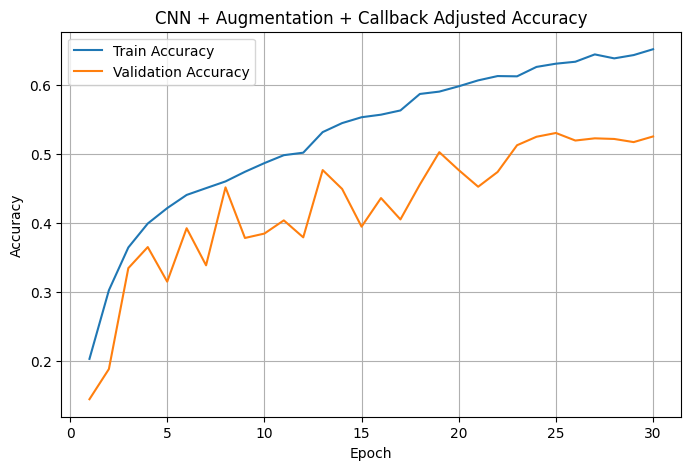

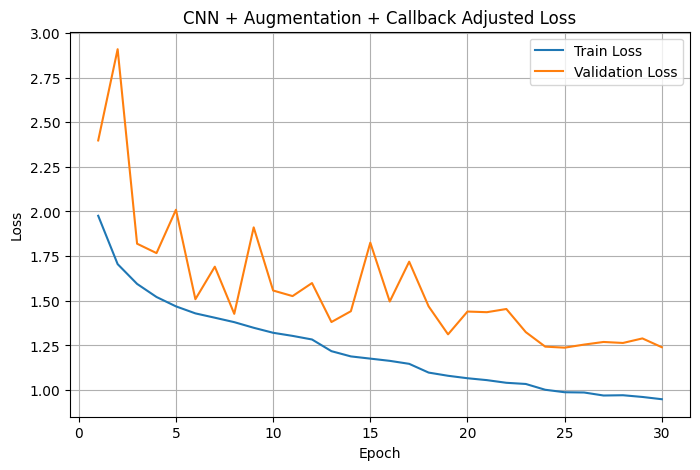

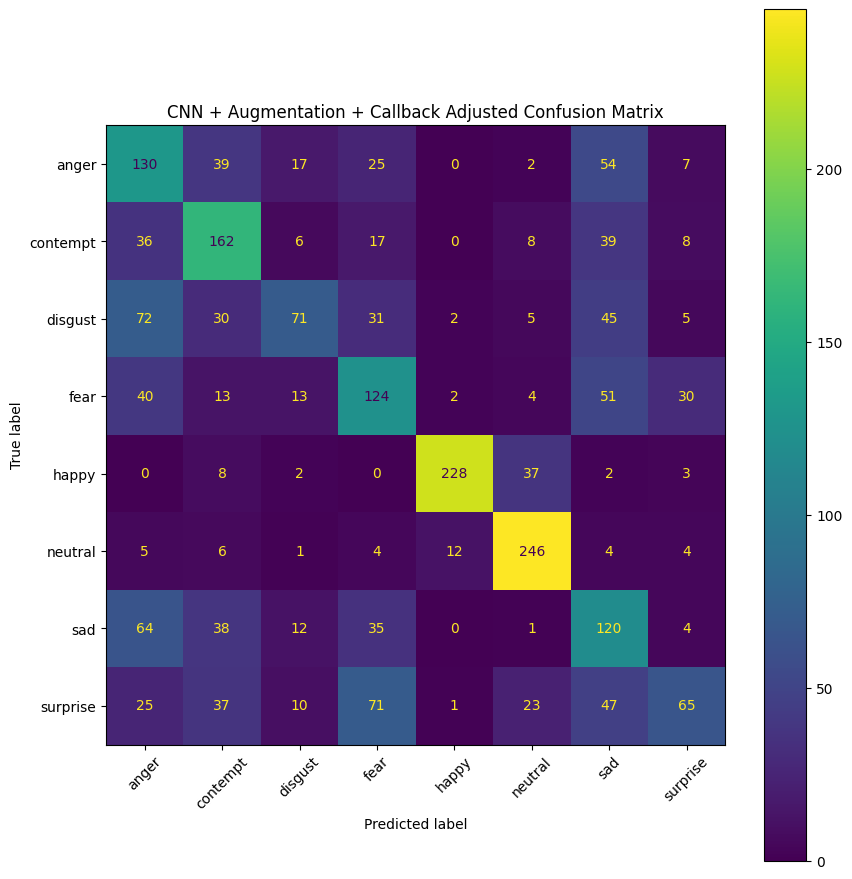



CNN + Augmentation + Callback 수정 최종 결과
Framework                                  Model Input Size Color Mode    Augmentation Dropout  Batch Size Optimizer  Initial LR  LR Patience  EarlyStopping Patience  Test Loss  Accuracy  Macro F1  Parameters  Best Epoch  Epochs Trained
    Keras CNN + Augmentation + Callback Adjusted  128x128x1  Grayscale Flip + Rotation    None          32      Adam       0.001            4                       7   1.271164    0.5202  0.512076      423208          25              30

최종 결과 CSV:
/content/keras_cnn_augmentation_callback_outputs/keras_cnn_callback_results.csv


Best Model 저장 위치
/content/keras_cnn_augmentation_callback_outputs/keras_cnn_augmentation_callback_best.keras


이전 실험 결과와 비교

[1] CNN Baseline
Augmentation : X
LR patience  : 기존 설정
Test Accuracy: 0.524739
Macro F1     : 0.520047

[2] CNN + Augmentation 이전 실험
Augmentation : Flip + Rotation
LR patience  : 2
EarlyStopping: 5
Test Accuracy: 0.502497
Macro F1     : 0.485059

[3] 이번 실험
Augmentat

In [ ]:
#Scheduler와 EarlyStopping 수정 테스트 진행
#ReduceLROnPlateau patience: 2 → 4
#EarlyStopping patience: 5 → 7
# ============================================================
# 어린이 얼굴 표정 이미지 분류
# Keras CNN + Augmentation
#
# Callback 수정 실험
#
# 변경점:
#
# EarlyStopping
# patience = 5
# ↓
# patience = 7
#
# ReduceLROnPlateau
# patience = 2
# ↓
# patience = 4
#
# 그 외 조건은 이전 CNN + Augmentation 실험과 동일
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import (
    layers,
    models
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    multilabel_confusion_matrix
)


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. 기본 설정
# ============================================================

IMG_SIZE = 128

BATCH_SIZE = 32

NUM_CLASSES = 8

EPOCHS = 30

LEARNING_RATE = 0.001


# ============================================================
# Callback 설정
# ============================================================

# 기존:
# patience = 5
#
# 수정:
# patience = 7
#
# Validation Loss가 일시적으로 흔들려도
# 너무 빨리 학습을 종료하지 않도록 여유를 줌
EARLY_STOPPING_PATIENCE = 7


# 기존:
# patience = 2
#
# 수정:
# patience = 4
#
# Validation Loss가 1~2 epoch 흔들렸다고
# 즉시 Learning Rate를 감소시키지 않도록 수정
LR_PATIENCE = 4


# 실질적으로 의미 있는 개선량
MIN_DELTA = 1e-4


# ============================================================
# 4. 클래스
# ============================================================

CLASS_NAMES = [

    "anger",

    "contempt",

    "disgust",

    "fear",

    "happy",

    "neutral",

    "sad",

    "surprise"

]


# ============================================================
# 5. GPU 확인
# ============================================================

print("=" * 70)

print(
    "TensorFlow / GPU 확인"
)

print("=" * 70)


print(
    "TensorFlow Version:",
    tf.__version__
)


gpus = tf.config.list_physical_devices(
    "GPU"
)


if gpus:

    print(
        "GPU 사용 가능:"
    )

    for gpu in gpus:

        print(
            gpu
        )

else:

    print(
        "GPU가 감지되지 않았습니다."
    )


# ============================================================
# 6. 데이터 경로 확인
#
# TRAIN_DIR
# VAL_DIR
# TEST_DIR
#
# 앞의 공통 코드에서 이미 정의되어 있어야 함
# ============================================================

print("\n")

print("=" * 70)

print(
    "CNN Dataset 경로 확인"
)

print("=" * 70)


print(
    "TRAIN_DIR :",
    TRAIN_DIR
)

print(
    "VAL_DIR   :",
    VAL_DIR
)

print(
    "TEST_DIR  :",
    TEST_DIR
)


for path_name, path in [

    (
        "TRAIN_DIR",
        TRAIN_DIR
    ),

    (
        "VAL_DIR",
        VAL_DIR
    ),

    (
        "TEST_DIR",
        TEST_DIR
    )

]:

    if not os.path.isdir(
        path
    ):

        raise FileNotFoundError(

            f"{path_name}를 찾을 수 없습니다.\n"
            f"경로: {path}"

        )


print(
    "\n데이터 경로 확인 완료"
)


# ============================================================
# 7. Train Dataset
#
# 원본:
# 1024 × 1024 RGB
#
# ↓ Resize
#
# 128 × 128
#
# ↓ Grayscale
#
# 128 × 128 × 1
#
# 이번 실험에서는 RGB로 변경하지 않음
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    class_names=CLASS_NAMES,

    image_size=(

        IMG_SIZE,

        IMG_SIZE

    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=True,

    seed=SEED

)


# ============================================================
# 8. Validation Dataset
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(

        IMG_SIZE,

        IMG_SIZE

    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False

)


# ============================================================
# 9. Test Dataset
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(

        IMG_SIZE,

        IMG_SIZE

    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False

)


# ============================================================
# 10. Dataset 정보
# ============================================================

class_names = train_ds.class_names


print("\n")

print("=" * 70)

print(
    "Dataset 정보"
)

print("=" * 70)


print(
    "Classes:"
)

print(
    class_names
)


print(
    "\nClass 개수:",
    len(
        class_names
    )
)


# ============================================================
# Batch 하나 확인
# ============================================================

for images, labels in train_ds.take(
    1
):

    print(
        "\nImage Shape:"
    )

    print(
        images.shape
    )


    print(
        "\nLabel Shape:"
    )

    print(
        labels.shape
    )


    print(
        "\nPixel MIN:"
    )

    print(
        tf.reduce_min(
            images
        ).numpy()
    )


    print(
        "\nPixel MAX:"
    )

    print(
        tf.reduce_max(
            images
        ).numpy()
    )


    print(
        "\nPixel MEAN:"
    )

    print(
        tf.reduce_mean(
            images
        ).numpy()
    )


# ============================================================
# 11. Dataset Prefetch
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(
    AUTOTUNE
)


val_ds = val_ds.prefetch(
    AUTOTUNE
)


test_ds = test_ds.prefetch(
    AUTOTUNE
)


# ============================================================
# 12. Data Augmentation
#
# 이전 실험과 동일
#
# Horizontal Flip
# 약 ±5° Rotation
#
# Validation / Test에서는 자동 비활성화
# ============================================================

def get_augmentation():

    return tf.keras.Sequential(

        [

            # ------------------------------------------------
            # 좌우 반전
            # ------------------------------------------------

            layers.RandomFlip(
                "horizontal"
            ),


            # ------------------------------------------------
            # 약 ±5도 회전
            #
            # 5 / 360 ≈ 0.014
            # ------------------------------------------------

            layers.RandomRotation(
                0.014
            )

        ],

        name="cnn_augmentation"

    )


# ============================================================
# 13. CNN 구조
#
# 이전 Augmentation 실험과 완전히 동일
#
#
# Input
# 128×128×1
#
# ↓
#
# Augmentation
#
# ↓
#
# Rescaling
#
# ↓
#
# Conv32 + BN + ReLU + Pool
#
# ↓
#
# Conv64 + BN + ReLU + Pool
#
# ↓
#
# Conv128 + BN + ReLU + Pool
#
# ↓
#
# Conv256 + BN + ReLU + Pool
#
# ↓
#
# GlobalAveragePooling
#
# ↓
#
# Dense128
#
# ↓
#
# Dense8
#
#
# Dropout 없음
# ============================================================

def build_cnn_augmentation():

    # ========================================================
    # Input
    # ========================================================

    inputs = layers.Input(

        shape=(

            IMG_SIZE,

            IMG_SIZE,

            1

        )

    )


    # ========================================================
    # Data Augmentation
    # ========================================================

    x = get_augmentation()(
        inputs
    )


    # ========================================================
    # Normalization
    #
    # 0~255
    # ↓
    # 0~1
    # ========================================================

    x = layers.Rescaling(

        1.0 / 255.0

    )(x)


    # ========================================================
    # Conv Block 1
    #
    # 128×128×1
    # ↓
    # 64×64×32
    # ========================================================

    x = layers.Conv2D(

        filters=32,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 2
    #
    # 64×64×32
    # ↓
    # 32×32×64
    # ========================================================

    x = layers.Conv2D(

        filters=64,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 3
    #
    # 32×32×64
    # ↓
    # 16×16×128
    # ========================================================

    x = layers.Conv2D(

        filters=128,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 4
    #
    # 16×16×128
    # ↓
    # 8×8×256
    # ========================================================

    x = layers.Conv2D(

        filters=256,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Global Average Pooling
    #
    # 8×8×256
    # ↓
    # 256
    # ========================================================

    x = layers.GlobalAveragePooling2D()(x)


    # ========================================================
    # Dense
    # ========================================================

    x = layers.Dense(

        128,

        activation="relu"

    )(x)


    # ========================================================
    # Dropout 없음
    # ========================================================


    # ========================================================
    # Output
    # ========================================================

    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax"

    )(x)


    # ========================================================
    # Model
    # ========================================================

    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="CNN_Augmentation_Callback_Adjusted"

    )


    return model


# ============================================================
# 14. 모델 생성
# ============================================================

cnn = build_cnn_augmentation()


# ============================================================
# 15. Model Summary
# ============================================================

print("\n")

print("=" * 70)

print(
    "CNN + Augmentation 구조"
)

print("=" * 70)


cnn.summary()


print(
    "\nCNN Parameters:",
    f"{cnn.count_params():,}"
)


# ============================================================
# 16. 결과 저장 폴더
#
# 이전 Augmentation 실험 결과를
# 덮어쓰지 않도록 별도 폴더 사용
# ============================================================

OUTPUT_DIR = (
    "/content/keras_cnn_augmentation_callback_outputs"
)


os.makedirs(

    OUTPUT_DIR,

    exist_ok=True

)


print(
    "\n결과 저장 폴더:"
)

print(
    OUTPUT_DIR
)


# ============================================================
# 17. Compile
# ============================================================

cnn.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss=(
        "sparse_categorical_crossentropy"
    ),

    metrics=[

        "accuracy"

    ]

)


# ============================================================
# 18. Callback
#
# 이번 실험의 핵심 수정 부분
# ============================================================

BEST_MODEL_PATH = os.path.join(

    OUTPUT_DIR,

    (
        "keras_cnn_augmentation_"
        "callback_best.keras"
    )

)


callbacks = [


    # ========================================================
    # EarlyStopping
    #
    # 기존:
    # patience = 5
    #
    # 수정:
    # patience = 7
    #
    # Validation Loss가 잠시 흔들려도
    # 충분히 기다린 뒤 학습 종료
    # ========================================================

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        mode="min",

        patience=7,

        min_delta=MIN_DELTA,

        restore_best_weights=True,

        verbose=1

    ),


    # ========================================================
    # ReduceLROnPlateau
    #
    # 기존:
    # patience = 2
    #
    # 수정:
    # patience = 4
    #
    # Validation Loss가 1~2 epoch 흔들리는 것만으로
    # LR이 너무 빠르게 감소하지 않도록 수정
    # ========================================================

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=4,

        min_delta=MIN_DELTA,

        min_lr=1e-6,

        verbose=1

    ),


    # ========================================================
    # Best Model 저장
    # ========================================================

    tf.keras.callbacks.ModelCheckpoint(

        filepath=BEST_MODEL_PATH,

        monitor="val_loss",

        mode="min",

        save_best_only=True,

        verbose=1

    )

]


# ============================================================
# 19. CNN 학습
# ============================================================

print("\n")

print("=" * 70)

print(
    "CNN + Augmentation + Callback 수정 학습 시작"
)

print("=" * 70)


cnn_history = cnn.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1

)


# ============================================================
# 20. 실제 학습 Epoch
# ============================================================

epochs_trained = len(

    cnn_history.history[
        "loss"
    ]

)


print("\n")

print(
    "실제 학습 Epoch:",
    epochs_trained
)


# ============================================================
# 21. Best Epoch
#
# Validation Loss 기준
# ============================================================

best_epoch = (

    np.argmin(

        cnn_history.history[
            "val_loss"
        ]

    )

    + 1

)


best_val_loss = np.min(

    cnn_history.history[
        "val_loss"
    ]

)


best_val_accuracy = (

    cnn_history.history[
        "val_accuracy"
    ][
        best_epoch - 1
    ]

)


print("\n")

print("=" * 70)

print(
    "Best Epoch 정보"
)

print("=" * 70)


print(
    "Best Epoch:",
    best_epoch
)


print(
    f"Best Validation Loss: "
    f"{best_val_loss:.6f}"
)


print(
    f"Best Epoch Validation Accuracy: "
    f"{best_val_accuracy:.6f}"
)


# ============================================================
# 22. Test 평가
# ============================================================

def evaluate_cnn(
    model
):

    # --------------------------------------------------------
    # Keras evaluate
    # --------------------------------------------------------

    test_loss, test_acc_keras = (
        model.evaluate(

            test_ds,

            verbose=0

        )
    )


    y_true = []

    y_pred = []


    # --------------------------------------------------------
    # Test 전체 예측
    # --------------------------------------------------------

    for images, labels in test_ds:

        predictions = model.predict(

            images,

            verbose=0

        )


        predicted_classes = np.argmax(

            predictions,

            axis=1

        )


        y_true.extend(

            labels.numpy()

        )


        y_pred.extend(

            predicted_classes

        )


    y_true = np.array(
        y_true
    )


    y_pred = np.array(
        y_pred
    )


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    accuracy = accuracy_score(

        y_true,

        y_pred

    )


    # --------------------------------------------------------
    # Macro F1
    # --------------------------------------------------------

    macro_f1 = f1_score(

        y_true,

        y_pred,

        average="macro"

    )


    print("\n")

    print("=" * 80)

    print(
        "CNN + Augmentation + Callback 수정 Test 결과"
    )

    print("=" * 80)


    print(
        f"Test Loss : "
        f"{test_loss:.6f}"
    )


    print(
        f"Accuracy  : "
        f"{accuracy:.6f}"
    )


    print(
        f"Macro F1  : "
        f"{macro_f1:.6f}"
    )


    # ========================================================
    # Classification Report
    # ========================================================

    print(
        "\nClassification Report\n"
    )


    print(

        classification_report(

            y_true,

            y_pred,

            labels=list(
                range(
                    NUM_CLASSES
                )
            ),

            target_names=class_names,

            digits=4,

            zero_division=0

        )

    )


    # ========================================================
    # TP / FP / FN / TN
    # ========================================================

    matrices = multilabel_confusion_matrix(

        y_true,

        y_pred,

        labels=list(
            range(
                NUM_CLASSES
            )
        )

    )


    confusion_values = []


    print("\n")

    print("=" * 85)

    print(
        "클래스별 TP / FP / FN / TN"
    )

    print("=" * 85)


    for i, class_name in enumerate(
        class_names
    ):

        tn, fp, fn, tp = (
            matrices[i].ravel()
        )


        print(

            f"{class_name:10s} | "

            f"TP: {tp:4d} | "

            f"FP: {fp:4d} | "

            f"FN: {fn:4d} | "

            f"TN: {tn:4d}"

        )


        confusion_values.append(

            {

                "Class":
                    class_name,

                "TP":
                    int(tp),

                "FP":
                    int(fp),

                "FN":
                    int(fn),

                "TN":
                    int(tn)

            }

        )


    confusion_df = pd.DataFrame(
        confusion_values
    )


    # ========================================================
    # CSV 저장
    # ========================================================

    confusion_csv = os.path.join(

        OUTPUT_DIR,

        "cnn_callback_tp_fp_fn_tn.csv"

    )


    confusion_df.to_csv(

        confusion_csv,

        index=False

    )


    print(
        "\nTP/FP/FN/TN 저장:"
    )

    print(
        confusion_csv
    )


    return (

        test_loss,

        accuracy,

        macro_f1,

        y_true,

        y_pred,

        confusion_df

    )


# ============================================================
# 23. Test 평가 실행
# ============================================================

(

    cnn_test_loss,

    cnn_accuracy,

    cnn_macro_f1,

    cnn_true,

    cnn_pred,

    cnn_confusion

) = evaluate_cnn(
    cnn
)


# ============================================================
# 24. Accuracy Graph
# ============================================================

epochs_range = range(

    1,

    len(
        cnn_history.history[
            "accuracy"
        ]
    ) + 1

)


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    cnn_history.history[
        "accuracy"
    ],

    label="Train Accuracy"

)


plt.plot(

    epochs_range,

    cnn_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"

)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "CNN + Augmentation + Callback Adjusted Accuracy"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# 25. Loss Graph
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    cnn_history.history[
        "loss"
    ],

    label="Train Loss"

)


plt.plot(

    epochs_range,

    cnn_history.history[
        "val_loss"
    ],

    label="Validation Loss"

)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "CNN + Augmentation + Callback Adjusted Loss"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# 26. Confusion Matrix
# ============================================================

cm = confusion_matrix(

    cnn_true,

    cnn_pred,

    labels=list(
        range(
            NUM_CLASSES
        )
    )

)


fig, ax = plt.subplots(

    figsize=(9, 9)

)


display = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)


display.plot(

    ax=ax,

    xticks_rotation=45,

    values_format="d"

)


plt.title(
    "CNN + Augmentation + Callback Adjusted Confusion Matrix"
)


plt.tight_layout()

plt.show()


# ============================================================
# 27. 최종 결과 DataFrame
# ============================================================

cnn_result = pd.DataFrame({

    "Framework": [
        "Keras"
    ],

    "Model": [
        "CNN + Augmentation + Callback Adjusted"
    ],

    "Input Size": [
        "128x128x1"
    ],

    "Color Mode": [
        "Grayscale"
    ],

    "Augmentation": [
        "Flip + Rotation"
    ],

    "Dropout": [
        "None"
    ],

    "Batch Size": [
        BATCH_SIZE
    ],

    "Optimizer": [
        "Adam"
    ],

    "Initial LR": [
        LEARNING_RATE
    ],

    "LR Patience": [
        LR_PATIENCE
    ],

    "EarlyStopping Patience": [
        EARLY_STOPPING_PATIENCE
    ],

    "Test Loss": [
        cnn_test_loss
    ],

    "Accuracy": [
        cnn_accuracy
    ],

    "Macro F1": [
        cnn_macro_f1
    ],

    "Parameters": [
        cnn.count_params()
    ],

    "Best Epoch": [
        best_epoch
    ],

    "Epochs Trained": [
        epochs_trained
    ]

})


# ============================================================
# 28. 최종 결과 출력
# ============================================================

print("\n")

print("=" * 120)

print(
    "CNN + Augmentation + Callback 수정 최종 결과"
)

print("=" * 120)


print(

    cnn_result.to_string(

        index=False

    )

)


# ============================================================
# 29. CSV 저장
# ============================================================

RESULT_CSV = os.path.join(

    OUTPUT_DIR,

    "keras_cnn_callback_results.csv"

)


cnn_result.to_csv(

    RESULT_CSV,

    index=False

)


print(
    "\n최종 결과 CSV:"
)

print(
    RESULT_CSV
)


# ============================================================
# 30. Best Model 위치
# ============================================================

print("\n")

print("=" * 70)

print(
    "Best Model 저장 위치"
)

print("=" * 70)


print(
    BEST_MODEL_PATH
)


# ============================================================
# 31. 이전 결과와 비교
# ============================================================

print("\n")

print("=" * 90)

print(
    "이전 실험 결과와 비교"
)

print("=" * 90)


print("\n[1] CNN Baseline")

print(
    "Augmentation : X"
)

print(
    "LR patience  : 기존 설정"
)

print(
    "Test Accuracy: 0.524739"
)

print(
    "Macro F1     : 0.520047"
)


print("\n[2] CNN + Augmentation 이전 실험")

print(
    "Augmentation : Flip + Rotation"
)

print(
    "LR patience  : 2"
)

print(
    "EarlyStopping: 5"
)

print(
    "Test Accuracy: 0.502497"
)

print(
    "Macro F1     : 0.485059"
)


print("\n[3] 이번 실험")

print(
    "Augmentation : Flip + Rotation"
)

print(
    "LR patience  : 4"
)

print(
    "EarlyStopping: 7"
)

print(
    f"Test Accuracy: "
    f"{cnn_accuracy:.6f}"
)

print(
    f"Macro F1     : "
    f"{cnn_macro_f1:.6f}"
)

TensorFlow / GPU 확인
TensorFlow Version: 2.20.0

GPU 사용 가능:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Dataset 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test

Dataset 경로 확인 완료
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.


Dataset 정보
Classes:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class 개수: 8

Image Shape:
(32, 128, 128, 1)

Label Shape:
(32,)

Pixel MIN:
0.0

Pixel MAX:
255.0

Pixel MEAN:
113.415085


CNN + Augmentation + Dropout(0.2) 구조


Model: "CNN_Augmentation_Dropout02"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_augmentation (Sequential)   │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 423,208 (1.61 MB)

 Trainable params: 422,248 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)


CNN Parameters: 423,208

결과 저장 폴더:
/content/keras_cnn_augmentation_dropout02_outputs


CNN + Augmentation + Dropout(0.2) 학습 시작
Epoch 1/30
320/321 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1517 - loss: 2.1027
Epoch 1: val_loss improved from None to 2.26861, saving model to /content/keras_cnn_augmentation_dropout02_outputs/keras_cnn_aug_dropout02_best.keras

Epoch 1: finished saving model to /content/keras_cnn_augmentation_dropout02_outputs/keras_cnn_aug_dropout02_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.1827 - loss: 2.0148 - val_accuracy: 0.1244 - val_loss: 2.2686 - learning_rate: 0.0010
Epoch 2/30
319/321 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2568 - loss: 1.7950
Epoch 2: val_loss improved from 2.26861 to 1.98010, saving model to /content/keras_cnn_augmentation_dropout02_outputs/keras_cnn_aug_dropout02_best.keras

Epoch 2: finished saving model to /content/keras_cnn_augmentation_dropout02_outputs/keras_cnn_aug_dropout02_best.keras
321/321 ━━━━

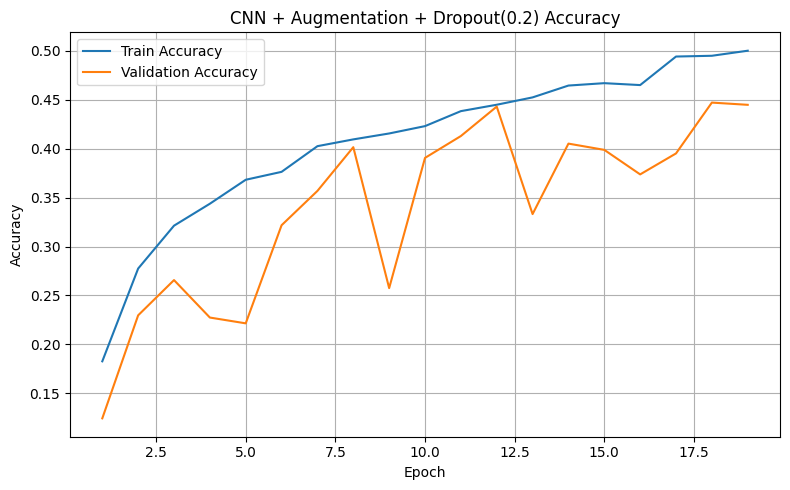

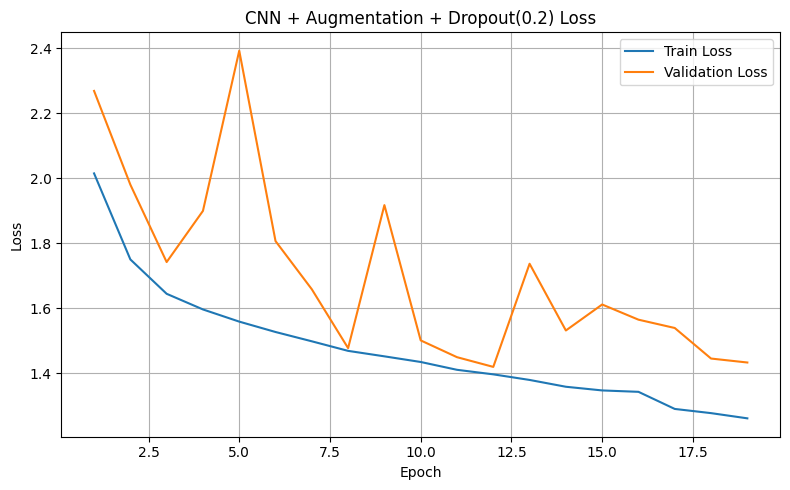

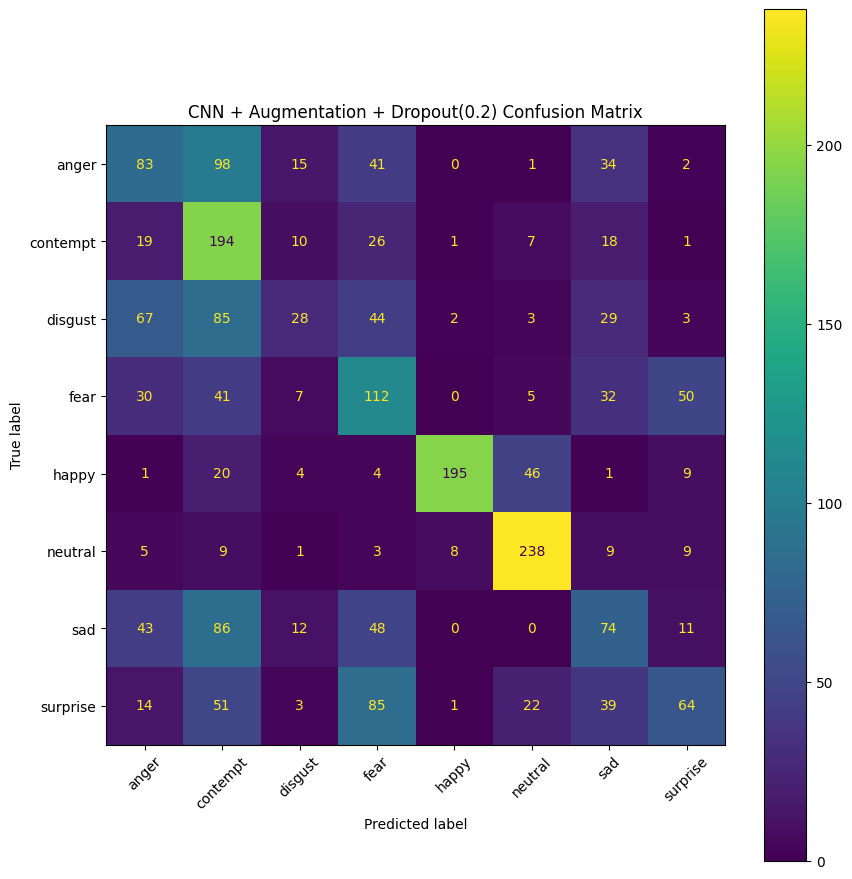



CNN + Augmentation + Dropout(0.2) 최종 결과
Framework                            Model Input Size Color Mode    Augmentation  Dropout  Batch Size Optimizer  Initial LR  LR Patience  EarlyStopping Patience  Test Loss  Accuracy  Macro F1  Parameters  Best Epoch  Best Train Accuracy  Best Validation Accuracy  Train-Val Gap  Epochs Trained
    Keras CNN + Augmentation + Dropout 0.2  128x128x1  Grayscale Flip + Rotation      0.2          32      Adam       0.001            4                       7   1.437674  0.448479  0.431656      423208          12             0.444932                  0.443026       0.001906              19

최종 결과 CSV 저장 완료:
/content/keras_cnn_augmentation_dropout02_outputs/keras_cnn_aug_dropout02_results.csv


Best Model 저장 위치
/content/keras_cnn_augmentation_dropout02_outputs/keras_cnn_aug_dropout02_best.keras


CNN 실험 결과 비교

[1] CNN Baseline
Color        : Grayscale
Augmentation : X
Dropout      : X
Test Accuracy: 0.524739
Macro F1     : 0.520047

[2] CNN + Augmentatio

In [ ]:
#CNN_base+aug+callback+dropout
# ============================================================
# 어린이 얼굴 표정 이미지 분류
# Keras CNN
#
# CNN + Augmentation + Callback 수정 + Dropout(0.2)
#
# 이번 실험의 목적
# ------------------------------------------------------------
# 직전 실험:
#
# Grayscale
# + Horizontal Flip
# + Rotation ±5도
# + Dropout 없음
# + LR Scheduler patience = 4
# + EarlyStopping patience = 7
#
# 결과:
# Test Accuracy = 0.520200
# Macro F1      = 0.512076
#
#
# 이번 실험:
#
# 위 조건을 모두 그대로 유지하고
#
# Dense(128) 뒤에
#
# Dropout(0.2)
#
# 하나만 추가
#
# → Dropout이 남아 있는 Train/Validation Gap을
#   줄이고 일반화 성능을 높이는지 확인
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    multilabel_confusion_matrix
)


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 3. 기본 설정
# ============================================================

# 모델 입력 이미지 크기
IMG_SIZE = 128

# 한 Batch에 들어가는 이미지 수
BATCH_SIZE = 32

# 감정 클래스 수
NUM_CLASSES = 8

# 최대 학습 Epoch
EPOCHS = 30

# Adam 초기 Learning Rate
LEARNING_RATE = 0.001


# ============================================================
# Callback 설정
# ============================================================

# 직전 실험과 동일
EARLY_STOPPING_PATIENCE = 7

# 직전 실험과 동일
LR_PATIENCE = 4

# 너무 작은 val_loss 변화는
# 실제 개선으로 보지 않음
MIN_DELTA = 1e-4


# ============================================================
# 이번 실험의 핵심
# ============================================================

DROPOUT_RATE = 0.2


# ============================================================
# 4. 클래스
# ============================================================

CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ============================================================
# 5. TensorFlow / GPU 확인
# ============================================================

print("=" * 70)
print("TensorFlow / GPU 확인")
print("=" * 70)

print(
    "TensorFlow Version:",
    tf.__version__
)

gpus = tf.config.list_physical_devices(
    "GPU"
)

if gpus:

    print("\nGPU 사용 가능:")

    for gpu in gpus:
        print(gpu)

else:

    print("\nGPU가 감지되지 않았습니다.")


# ============================================================
# 6. Dataset 경로 확인
#
# 이전 공통 코드에서 아래 변수가
# 이미 생성되어 있어야 함
#
# TRAIN_DIR
# VAL_DIR
# TEST_DIR
# ============================================================

print("\n")
print("=" * 70)
print("Dataset 경로 확인")
print("=" * 70)

print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)


for path_name, path in [

    ("TRAIN_DIR", TRAIN_DIR),

    ("VAL_DIR", VAL_DIR),

    ("TEST_DIR", TEST_DIR)

]:

    if not os.path.isdir(path):

        raise FileNotFoundError(

            f"{path_name}를 찾을 수 없습니다.\n"
            f"경로: {path}"

        )


print("\nDataset 경로 확인 완료")


# ============================================================
# 7. Train Dataset
#
# 원본:
# 1024 × 1024 RGB
#
# ↓ Resize
#
# 128 × 128
#
# ↓ Grayscale
#
# 128 × 128 × 1
#
# 이번에도 RGB로 변경하지 않음
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    # 클래스 번호 고정
    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    # 기존과 동일하게 Grayscale
    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    # 정수 Label
    label_mode="int",

    # Train은 Shuffle
    shuffle=True,

    seed=SEED
)


# ============================================================
# 8. Validation Dataset
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    # Validation은 순서 고정
    shuffle=False
)


# ============================================================
# 9. Test Dataset
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    color_mode="grayscale",

    batch_size=BATCH_SIZE,

    label_mode="int",

    # Test도 순서 고정
    shuffle=False
)


# ============================================================
# 10. Dataset 정보 확인
# ============================================================

class_names = train_ds.class_names


print("\n")
print("=" * 70)
print("Dataset 정보")
print("=" * 70)

print("Classes:")
print(class_names)

print(
    "\nClass 개수:",
    len(class_names)
)


# ============================================================
# Batch 하나 확인
# ============================================================

for images, labels in train_ds.take(1):

    print("\nImage Shape:")
    print(images.shape)

    print("\nLabel Shape:")
    print(labels.shape)

    print("\nPixel MIN:")
    print(
        tf.reduce_min(images).numpy()
    )

    print("\nPixel MAX:")
    print(
        tf.reduce_max(images).numpy()
    )

    print("\nPixel MEAN:")
    print(
        tf.reduce_mean(images).numpy()
    )


# 정상적인 경우
#
# Image Shape:
# (32, 128, 128, 1)
#
# Pixel:
# 0 ~ 255


# ============================================================
# 11. Dataset Prefetch
#
# GPU가 현재 Batch를 학습하는 동안
# CPU가 다음 Batch를 미리 준비
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)


val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)


test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)


# ============================================================
# 12. Data Augmentation
#
# 직전 실험과 동일
#
# Horizontal Flip
# Rotation ±5도
#
# Keras Augmentation Layer는
# model.fit()의 Training에서는 활성화되고
#
# Validation / Test에서는 자동으로 비활성화됨
# ============================================================

def get_augmentation():

    return tf.keras.Sequential(

        [

            # ------------------------------------------------
            # Horizontal Flip
            #
            # 좌우 방향이 달라져도
            # 표정 특징을 인식하도록 학습
            # ------------------------------------------------

            layers.RandomFlip(
                "horizontal"
            ),


            # ------------------------------------------------
            # Rotation 약 ±5도
            #
            # Keras RandomRotation 값은
            # 전체 360도 중 비율
            #
            # 5 / 360 ≈ 0.014
            # ------------------------------------------------

            layers.RandomRotation(
                0.014
            )

        ],

        name="cnn_augmentation"

    )


# ============================================================
# 13. CNN Model
#
#
# Input
# 128 × 128 × 1
#
# ↓
#
# Augmentation
#
# ↓
#
# Rescaling
#
# ↓
#
# Conv 32
# BatchNorm
# ReLU
# MaxPool
#
# ↓
#
# Conv 64
# BatchNorm
# ReLU
# MaxPool
#
# ↓
#
# Conv 128
# BatchNorm
# ReLU
# MaxPool
#
# ↓
#
# Conv 256
# BatchNorm
# ReLU
# MaxPool
#
# ↓
#
# GlobalAveragePooling
#
# ↓
#
# Dense 128 + ReLU
#
# ↓
#
# ★ Dropout 0.2
#
# ↓
#
# Dense 8 + Softmax
#
# ============================================================

def build_cnn_dropout():

    # ========================================================
    # Input
    #
    # 128 × 128 × 1
    # ========================================================

    inputs = layers.Input(

        shape=(

            IMG_SIZE,

            IMG_SIZE,

            1

        )

    )


    # ========================================================
    # Data Augmentation
    #
    # 직전 실험과 동일
    # ========================================================

    x = get_augmentation()(
        inputs
    )


    # ========================================================
    # Rescaling
    #
    # Pixel
    #
    # 0 ~ 255
    #
    # ↓
    #
    # 0 ~ 1
    # ========================================================

    x = layers.Rescaling(

        1.0 / 255.0

    )(x)


    # ========================================================
    # Conv Block 1
    #
    # Input
    #
    # 128 × 128 × 1
    #
    # Conv
    #
    # 128 × 128 × 32
    #
    # MaxPool
    #
    # 64 × 64 × 32
    # ========================================================

    x = layers.Conv2D(

        filters=32,

        kernel_size=3,

        padding="same",

        # Conv 직후 BatchNormalization을 사용하기 때문에
        # Bias는 생략
        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 2
    #
    # 64 × 64 × 32
    #
    # ↓
    #
    # 32 × 32 × 64
    # ========================================================

    x = layers.Conv2D(

        filters=64,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 3
    #
    # 32 × 32 × 64
    #
    # ↓
    #
    # 16 × 16 × 128
    # ========================================================

    x = layers.Conv2D(

        filters=128,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 4
    #
    # 16 × 16 × 128
    #
    # ↓
    #
    # 8 × 8 × 256
    # ========================================================

    x = layers.Conv2D(

        filters=256,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Global Average Pooling
    #
    # 8 × 8 × 256
    #
    # ↓
    #
    # 256
    #
    # Flatten보다 Parameter 수를 크게 줄일 수 있음
    # ========================================================

    x = layers.GlobalAveragePooling2D()(x)


    # ========================================================
    # Dense Layer
    # ========================================================

    x = layers.Dense(

        units=128,

        activation="relu"

    )(x)


    # ========================================================
    # 이번 실험의 핵심
    #
    # Dropout 0.2
    #
    # Training 중 Dense 128 출력 중
    # 약 20%를 무작위로 비활성화
    #
    # 특정 Feature에 지나치게 의존하는 현상을
    # 완화하여 일반화 성능 향상을 기대
    #
    # Validation / Test에서는 Dropout이 자동 비활성화됨
    # ========================================================

    x = layers.Dropout(

        rate=DROPOUT_RATE

    )(x)


    # ========================================================
    # Output
    #
    # 8개 클래스
    # ========================================================

    outputs = layers.Dense(

        units=NUM_CLASSES,

        activation="softmax"

    )(x)


    # ========================================================
    # Model 생성
    # ========================================================

    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="CNN_Augmentation_Dropout02"

    )


    return model


# ============================================================
# 14. CNN 생성
# ============================================================

cnn = build_cnn_dropout()


# ============================================================
# 15. CNN 구조 확인
# ============================================================

print("\n")
print("=" * 70)
print("CNN + Augmentation + Dropout(0.2) 구조")
print("=" * 70)

cnn.summary()


print(
    "\nCNN Parameters:",
    f"{cnn.count_params():,}"
)


# ============================================================
# 16. 출력 폴더
#
# 이전 결과와 섞이지 않도록
# 새로운 폴더 사용
# ============================================================

OUTPUT_DIR = (
    "/content/"
    "keras_cnn_augmentation_dropout02_outputs"
)


os.makedirs(

    OUTPUT_DIR,

    exist_ok=True

)


print("\n결과 저장 폴더:")
print(OUTPUT_DIR)


# ============================================================
# 17. Compile
#
# 이전과 동일
# ============================================================

cnn.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss=(
        "sparse_categorical_crossentropy"
    ),

    metrics=[
        "accuracy"
    ]

)


# ============================================================
# 18. Callback
#
# 직전 실험의 수정된 Callback 그대로 사용
#
# EarlyStopping:
# patience = 7
#
# ReduceLROnPlateau:
# patience = 4
# ============================================================

BEST_MODEL_PATH = os.path.join(

    OUTPUT_DIR,

    (
        "keras_cnn_aug_"
        "dropout02_best.keras"
    )

)


callbacks = [


    # ========================================================
    # EarlyStopping
    #
    # val_loss가 7 Epoch 동안
    # 의미 있게 개선되지 않으면 학습 종료
    #
    # 가장 좋은 Weight 복원
    # ========================================================

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        mode="min",

        patience=EARLY_STOPPING_PATIENCE,

        min_delta=MIN_DELTA,

        restore_best_weights=True,

        verbose=1

    ),


    # ========================================================
    # ReduceLROnPlateau
    #
    # val_loss가 4 Epoch 동안
    # 의미 있게 개선되지 않으면
    #
    # LR을 절반으로 감소
    # ========================================================

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=LR_PATIENCE,

        min_delta=MIN_DELTA,

        min_lr=1e-6,

        verbose=1

    ),


    # ========================================================
    # Best Model 저장
    # ========================================================

    tf.keras.callbacks.ModelCheckpoint(

        filepath=BEST_MODEL_PATH,

        monitor="val_loss",

        mode="min",

        save_best_only=True,

        verbose=1

    )

]


# ============================================================
# 19. CNN 학습
# ============================================================

print("\n")
print("=" * 80)
print(
    "CNN + Augmentation + Dropout(0.2) 학습 시작"
)
print("=" * 80)


cnn_history = cnn.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1

)


# ============================================================
# 20. 실제 학습 Epoch
# ============================================================

epochs_trained = len(

    cnn_history.history[
        "loss"
    ]

)


print("\n실제 학습 Epoch:")
print(epochs_trained)


# ============================================================
# 21. Best Epoch
#
# val_loss 기준
# ============================================================

best_epoch = (

    np.argmin(

        cnn_history.history[
            "val_loss"
        ]

    )

    + 1

)


best_val_loss = np.min(

    cnn_history.history[
        "val_loss"
    ]

)


best_val_accuracy = (

    cnn_history.history[
        "val_accuracy"
    ][
        best_epoch - 1
    ]

)


best_train_accuracy = (

    cnn_history.history[
        "accuracy"
    ][
        best_epoch - 1
    ]

)


# ============================================================
# Train / Val Gap
# ============================================================

train_val_gap = (

    best_train_accuracy

    -

    best_val_accuracy

)


print("\n")
print("=" * 70)
print("Best Epoch 정보")
print("=" * 70)


print(
    "Best Epoch:",
    best_epoch
)


print(
    f"Best Train Accuracy      : "
    f"{best_train_accuracy:.6f}"
)


print(
    f"Best Validation Accuracy : "
    f"{best_val_accuracy:.6f}"
)


print(
    f"Train - Validation Gap   : "
    f"{train_val_gap:.6f}"
)


print(
    f"Best Validation Loss     : "
    f"{best_val_loss:.6f}"
)


# ============================================================
# 22. Test 평가 함수
# ============================================================

def evaluate_cnn(
    model
):

    # ========================================================
    # Test Loss
    # ========================================================

    test_loss, keras_accuracy = (
        model.evaluate(

            test_ds,

            verbose=0

        )
    )


    # ========================================================
    # 정답 / 예측값
    # ========================================================

    y_true = []

    y_pred = []


    for images, labels in test_ds:

        # Softmax probability
        predictions = model.predict(

            images,

            verbose=0

        )


        # 가장 높은 확률 클래스
        predicted_classes = np.argmax(

            predictions,

            axis=1

        )


        y_true.extend(
            labels.numpy()
        )


        y_pred.extend(
            predicted_classes
        )


    # NumPy Array 변환
    y_true = np.array(
        y_true
    )

    y_pred = np.array(
        y_pred
    )


    # ========================================================
    # Accuracy
    # ========================================================

    accuracy = accuracy_score(

        y_true,

        y_pred

    )


    # ========================================================
    # Macro F1
    #
    # 클래스별 F1을 동일한 비중으로 평균
    # ========================================================

    macro_f1 = f1_score(

        y_true,

        y_pred,

        average="macro"

    )


    # ========================================================
    # 기본 결과
    # ========================================================

    print("\n")
    print("=" * 85)

    print(
        "CNN + Augmentation "
        "+ Dropout(0.2) Test 결과"
    )

    print("=" * 85)


    print(
        f"Test Loss : "
        f"{test_loss:.6f}"
    )


    print(
        f"Accuracy  : "
        f"{accuracy:.6f}"
    )


    print(
        f"Macro F1  : "
        f"{macro_f1:.6f}"
    )


    # ========================================================
    # Classification Report
    # ========================================================

    print(
        "\nClassification Report\n"
    )


    print(

        classification_report(

            y_true,

            y_pred,

            labels=list(
                range(
                    NUM_CLASSES
                )
            ),

            target_names=class_names,

            digits=4,

            zero_division=0

        )

    )


    # ========================================================
    # TP / FP / FN / TN
    #
    # One-vs-Rest
    # ========================================================

    matrices = multilabel_confusion_matrix(

        y_true,

        y_pred,

        labels=list(
            range(
                NUM_CLASSES
            )
        )

    )


    confusion_values = []


    print("\n")
    print("=" * 85)
    print("클래스별 TP / FP / FN / TN")
    print("=" * 85)


    for i, class_name in enumerate(
        class_names
    ):

        # Matrix 구조:
        #
        # [[TN, FP],
        #  [FN, TP]]

        tn, fp, fn, tp = (
            matrices[i].ravel()
        )


        print(

            f"{class_name:10s} | "

            f"TP: {tp:4d} | "

            f"FP: {fp:4d} | "

            f"FN: {fn:4d} | "

            f"TN: {tn:4d}"

        )


        confusion_values.append(

            {

                "Class":
                    class_name,

                "TP":
                    int(tp),

                "FP":
                    int(fp),

                "FN":
                    int(fn),

                "TN":
                    int(tn)

            }

        )


    confusion_df = pd.DataFrame(
        confusion_values
    )


    # ========================================================
    # TP / FP / FN / TN CSV 저장
    # ========================================================

    confusion_csv_path = os.path.join(

        OUTPUT_DIR,

        (
            "cnn_aug_dropout02_"
            "tp_fp_fn_tn.csv"
        )

    )


    confusion_df.to_csv(

        confusion_csv_path,

        index=False

    )


    print(
        "\nTP / FP / FN / TN CSV 저장:"
    )

    print(
        confusion_csv_path
    )


    return (

        test_loss,

        accuracy,

        macro_f1,

        y_true,

        y_pred,

        confusion_df

    )


# ============================================================
# 23. Test 평가
# ============================================================

(

    cnn_test_loss,

    cnn_accuracy,

    cnn_macro_f1,

    cnn_true,

    cnn_pred,

    cnn_confusion

) = evaluate_cnn(
    cnn
)


# ============================================================
# 24. Accuracy Graph
# ============================================================

epochs_range = range(

    1,

    len(
        cnn_history.history[
            "accuracy"
        ]
    )

    + 1

)


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    cnn_history.history[
        "accuracy"
    ],

    label="Train Accuracy"

)


plt.plot(

    epochs_range,

    cnn_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"

)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "CNN + Augmentation + Dropout(0.2) Accuracy"
)


plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


# ============================================================
# 25. Loss Graph
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    cnn_history.history[
        "loss"
    ],

    label="Train Loss"

)


plt.plot(

    epochs_range,

    cnn_history.history[
        "val_loss"
    ],

    label="Validation Loss"

)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "CNN + Augmentation + Dropout(0.2) Loss"
)


plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


# ============================================================
# 26. Confusion Matrix
# ============================================================

cm = confusion_matrix(

    cnn_true,

    cnn_pred,

    labels=list(
        range(
            NUM_CLASSES
        )
    )

)


fig, ax = plt.subplots(

    figsize=(9, 9)

)


display = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)


display.plot(

    ax=ax,

    xticks_rotation=45,

    values_format="d"

)


plt.title(

    "CNN + Augmentation + Dropout(0.2) "
    "Confusion Matrix"

)


plt.tight_layout()

plt.show()


# ============================================================
# 27. 최종 결과 DataFrame
# ============================================================

cnn_result = pd.DataFrame({

    "Framework": [
        "Keras"
    ],

    "Model": [
        "CNN + Augmentation + Dropout 0.2"
    ],

    "Input Size": [
        "128x128x1"
    ],

    "Color Mode": [
        "Grayscale"
    ],

    "Augmentation": [
        "Flip + Rotation"
    ],

    "Dropout": [
        DROPOUT_RATE
    ],

    "Batch Size": [
        BATCH_SIZE
    ],

    "Optimizer": [
        "Adam"
    ],

    "Initial LR": [
        LEARNING_RATE
    ],

    "LR Patience": [
        LR_PATIENCE
    ],

    "EarlyStopping Patience": [
        EARLY_STOPPING_PATIENCE
    ],

    "Test Loss": [
        cnn_test_loss
    ],

    "Accuracy": [
        cnn_accuracy
    ],

    "Macro F1": [
        cnn_macro_f1
    ],

    "Parameters": [
        cnn.count_params()
    ],

    "Best Epoch": [
        best_epoch
    ],

    "Best Train Accuracy": [
        best_train_accuracy
    ],

    "Best Validation Accuracy": [
        best_val_accuracy
    ],

    "Train-Val Gap": [
        train_val_gap
    ],

    "Epochs Trained": [
        epochs_trained
    ]

})


# ============================================================
# 28. 최종 결과 출력
# ============================================================

print("\n")
print("=" * 130)

print(
    "CNN + Augmentation "
    "+ Dropout(0.2) 최종 결과"
)

print("=" * 130)


print(

    cnn_result.to_string(

        index=False

    )

)


# ============================================================
# 29. CSV 저장
# ============================================================

RESULT_CSV = os.path.join(

    OUTPUT_DIR,

    (
        "keras_cnn_aug_"
        "dropout02_results.csv"
    )

)


cnn_result.to_csv(

    RESULT_CSV,

    index=False

)


print(
    "\n최종 결과 CSV 저장 완료:"
)

print(
    RESULT_CSV
)


# ============================================================
# 30. Best Model 저장 위치
# ============================================================

print("\n")
print("=" * 70)
print("Best Model 저장 위치")
print("=" * 70)

print(
    BEST_MODEL_PATH
)


# ============================================================
# 31. 기존 실험과 비교
# ============================================================

print("\n")
print("=" * 100)
print("CNN 실험 결과 비교")
print("=" * 100)


# ------------------------------------------------------------
# 1. 최초 CNN Baseline
# ------------------------------------------------------------

print("\n[1] CNN Baseline")

print(
    "Color        : Grayscale"
)

print(
    "Augmentation : X"
)

print(
    "Dropout      : X"
)

print(
    "Test Accuracy: 0.524739"
)

print(
    "Macro F1     : 0.520047"
)


# ------------------------------------------------------------
# 2. Augmentation 1차
# ------------------------------------------------------------

print(
    "\n[2] CNN + Augmentation"
)

print(
    "Color        : Grayscale"
)

print(
    "Augmentation : Flip + Rotation"
)

print(
    "Dropout      : X"
)

print(
    "LR Patience  : 2"
)

print(
    "EarlyStopping: 5"
)

print(
    "Test Accuracy: 0.502497"
)

print(
    "Macro F1     : 0.485059"
)


# ------------------------------------------------------------
# 3. Augmentation + Callback 수정
# ------------------------------------------------------------

print(
    "\n[3] CNN + Augmentation + Callback Adjusted"
)

print(
    "Color        : Grayscale"
)

print(
    "Augmentation : Flip + Rotation"
)

print(
    "Dropout      : X"
)

print(
    "LR Patience  : 4"
)

print(
    "EarlyStopping: 7"
)

print(
    "Test Accuracy: 0.520200"
)

print(
    "Macro F1     : 0.512076"
)


# ------------------------------------------------------------
# 4. 이번 실험
# ------------------------------------------------------------

print(
    "\n[4] CNN + Augmentation + Dropout(0.2)"
)

print(
    "Color        : Grayscale"
)

print(
    "Augmentation : Flip + Rotation"
)

print(
    "Dropout      : 0.2"
)

print(
    "LR Patience  : 4"
)

print(
    "EarlyStopping: 7"
)

print(
    f"Best Train Acc : "
    f"{best_train_accuracy:.6f}"
)

print(
    f"Best Val Acc   : "
    f"{best_val_accuracy:.6f}"
)

print(
    f"Train-Val Gap  : "
    f"{train_val_gap:.6f}"
)

print(
    f"Test Accuracy  : "
    f"{cnn_accuracy:.6f}"
)

print(
    f"Macro F1       : "
    f"{cnn_macro_f1:.6f}"
)


# ============================================================
# 32. 비교 기준 안내
# ============================================================

print("\n")
print("=" * 100)
print("이번 실험에서 확인할 핵심")
print("=" * 100)

print(
    """
직전 모델 기준:

Best Train Accuracy ≈ 63%
Best Validation Accuracy ≈ 53%
Train-Val Gap ≈ 10%p

Test Accuracy = 52.0200%
Macro F1      = 51.2076%


Dropout(0.2) 적용 후 확인할 것:

1. Train Accuracy가 얼마나 감소했는가?

2. Validation Accuracy가 유지되거나 상승했는가?

3. Train-Val Gap이 감소했는가?

4. Test Accuracy가 52.02%보다 상승했는가?

5. Macro F1이 51.21%보다 상승했는가?


예를 들어:

Train = 59%
Val   = 54%
Test  = 53%

라면 매우 좋은 결과


반대로:

Train = 54%
Val   = 49%
Test  = 49%

라면 Dropout이 과도한 규제로 작용한 것
"""
)

TensorFlow / GPU 확인
TensorFlow Version: 2.20.0

GPU 사용 가능:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Dataset 경로 확인
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test

Dataset 경로 확인 완료
Found 10251 files belonging to 8 classes.
Found 2194 files belonging to 8 classes.
Found 2203 files belonging to 8 classes.


RGB Dataset 정보
Classes:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class 개수: 8

Image Batch Shape:
(32, 128, 128, 3)

Label Batch Shape:
(32,)

Pixel MIN:
0.0

Pixel MAX:
255.0

Pixel MEAN:
111.58744


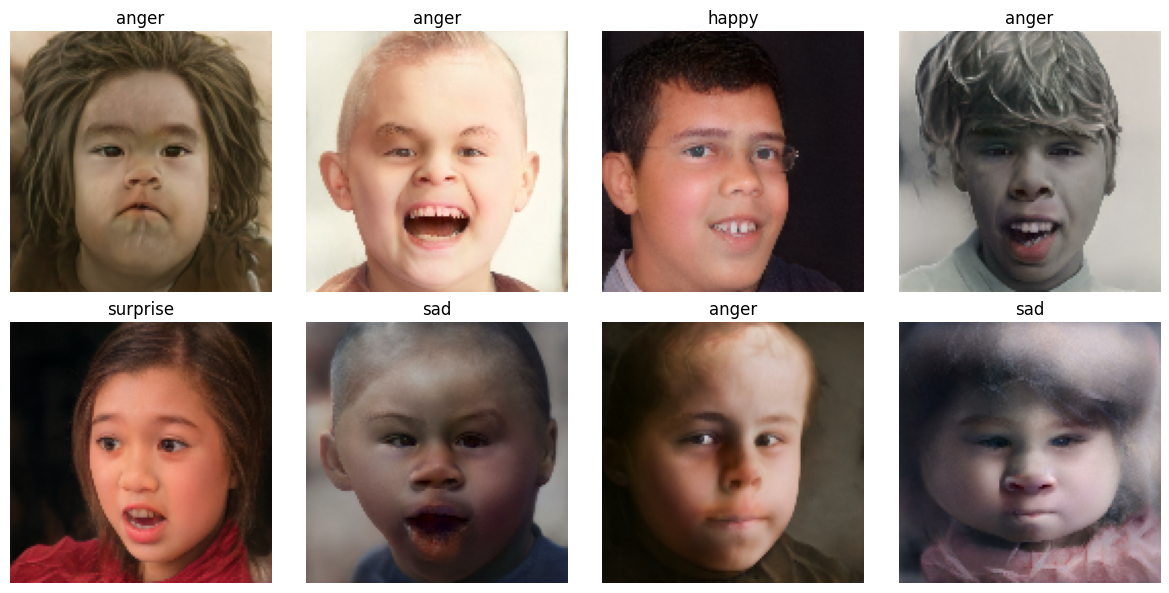



CNN RGB + Augmentation 구조


Model: "CNN_RGB_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_rgb_augmentation            │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,03

 Total params: 423,784 (1.62 MB)

 Trainable params: 422,824 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)


CNN RGB Parameters: 423,784

결과 저장 폴더:
/content/keras_cnn_rgb_augmentation_outputs


CNN RGB + Augmentation + Callback 수정 학습 시작
Epoch 1/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1605 - loss: 2.1045
Epoch 1: val_loss improved from None to 2.17569, saving model to /content/keras_cnn_rgb_augmentation_outputs/keras_cnn_rgb_best.keras

Epoch 1: finished saving model to /content/keras_cnn_rgb_augmentation_outputs/keras_cnn_rgb_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.1865 - loss: 2.0254 - val_accuracy: 0.1418 - val_loss: 2.1757 - learning_rate: 0.0010
Epoch 2/30
320/321 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2704 - loss: 1.8036
Epoch 2: val_loss improved from 2.17569 to 2.01636, saving model to /content/keras_cnn_rgb_augmentation_outputs/keras_cnn_rgb_best.keras

Epoch 2: finished saving model to /content/keras_cnn_rgb_augmentation_outputs/keras_cnn_rgb_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.2930 - loss: 1.745

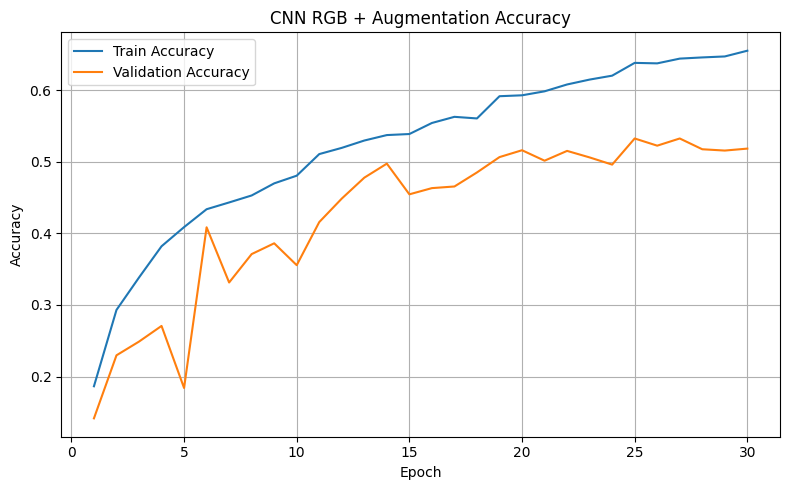

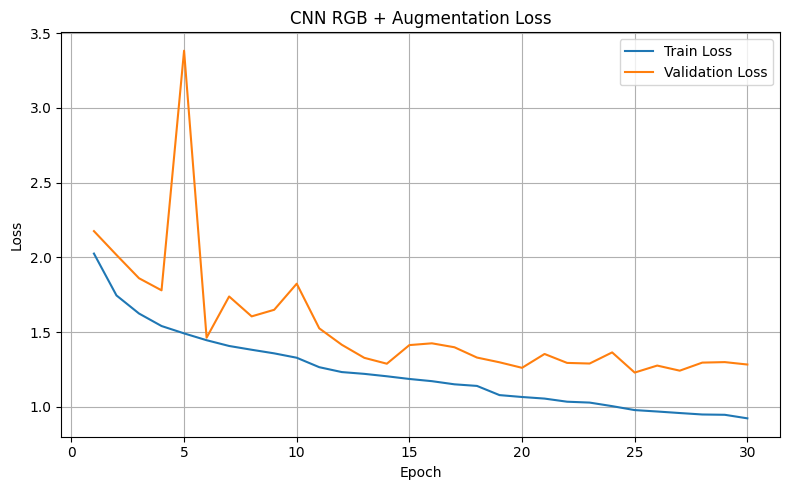

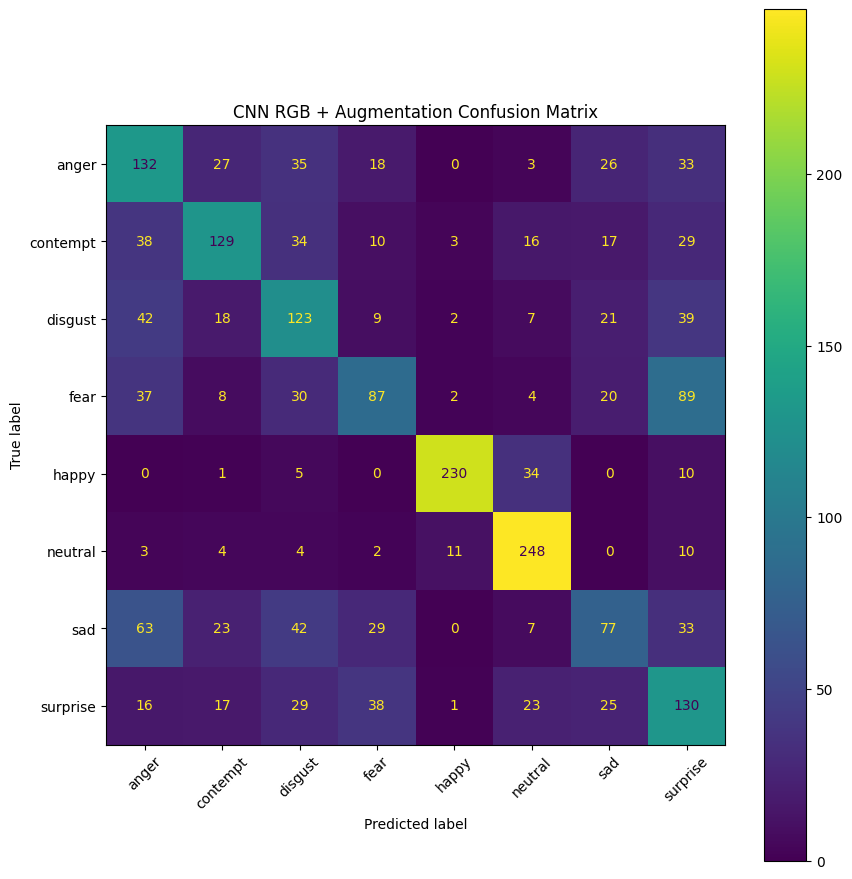



CNN RGB + Augmentation + Callback Adjusted 최종 결과
Framework                  Model Input Size Color Mode    Augmentation Dropout  Batch Size Optimizer  Initial LR  LR Patience  EarlyStopping Patience  Test Loss  Accuracy  Macro F1  Parameters  Best Epoch  Best Train Accuracy  Best Validation Accuracy  Train-Val Gap  Epochs Trained
    Keras CNN RGB + Augmentation  128x128x3        RGB Flip + Rotation    None          32      Adam       0.001            4                       7    1.26194  0.524739  0.519305      423784          25             0.637889                  0.532361       0.105528              30

최종 결과 CSV 저장 완료:
/content/keras_cnn_rgb_augmentation_outputs/keras_cnn_rgb_results.csv


Best RGB CNN Model 저장 위치
/content/keras_cnn_rgb_augmentation_outputs/keras_cnn_rgb_best.keras


CNN 실험 결과 비교

[1] CNN Baseline
Color        : Grayscale
Augmentation : X
Dropout      : X
Test Accuracy: 0.524739
Macro F1     : 0.520047

[2] CNN Grayscale + Augmentation + Callback
Color        :

In [ ]:
#CNN_base+augmentation+callback+RGB
# ============================================================
# 어린이 얼굴 표정 이미지 분류
# Keras CNN - RGB 실험
#
# CNN + RGB + Augmentation + Callback 수정
#
# ============================================================
#
# [이번 실험 목적]
#
# 직전 모델:
#
# Grayscale
# + Augmentation
# + Callback Adjusted
# + Dropout 없음
#
# Test Accuracy = 0.520200
# Macro F1      = 0.512076
#
#
# 이번 모델:
#
# RGB
# + Augmentation
# + Callback Adjusted
# + Dropout 없음
#
#
# 즉,
#
# Grayscale → RGB
#
# 하나만 변경하여
# 색상 정보가 CNN 성능에 미치는 영향을 확인
#
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    multilabel_confusion_matrix
)


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. 기본 설정
# ============================================================

# 모델에 들어가는 이미지 크기
IMG_SIZE = 128

# Batch 크기
BATCH_SIZE = 32

# 클래스 수
NUM_CLASSES = 8

# 최대 Epoch
EPOCHS = 30

# Adam 초기 Learning Rate
LEARNING_RATE = 0.001


# ============================================================
# Callback
#
# 이전 실험에서 수정한 값 그대로 유지
# ============================================================

# Validation Loss가 7번 연속
# 개선되지 않으면 학습 종료
EARLY_STOPPING_PATIENCE = 7


# Validation Loss가 4번 연속
# 개선되지 않으면 Learning Rate 감소
LR_PATIENCE = 4


# 너무 작은 val_loss 변화는
# 의미 있는 개선으로 판단하지 않음
MIN_DELTA = 1e-4


# ============================================================
# 4. 클래스
# ============================================================

CLASS_NAMES = [

    "anger",

    "contempt",

    "disgust",

    "fear",

    "happy",

    "neutral",

    "sad",

    "surprise"

]


# ============================================================
# 5. TensorFlow / GPU 확인
# ============================================================

print("=" * 70)
print("TensorFlow / GPU 확인")
print("=" * 70)


print(
    "TensorFlow Version:",
    tf.__version__
)


gpus = tf.config.list_physical_devices(
    "GPU"
)


if gpus:

    print("\nGPU 사용 가능:")

    for gpu in gpus:

        print(gpu)

else:

    print(
        "\nGPU가 감지되지 않았습니다."
    )


# ============================================================
# 6. Dataset 경로 확인
#
# 이전 공통 코드에서 아래 변수가
# 정의되어 있어야 함
#
# TRAIN_DIR
# VAL_DIR
# TEST_DIR
# ============================================================

print("\n")
print("=" * 70)
print("Dataset 경로 확인")
print("=" * 70)


print(
    "TRAIN_DIR :",
    TRAIN_DIR
)

print(
    "VAL_DIR   :",
    VAL_DIR
)

print(
    "TEST_DIR  :",
    TEST_DIR
)


for path_name, path in [

    (
        "TRAIN_DIR",
        TRAIN_DIR
    ),

    (
        "VAL_DIR",
        VAL_DIR
    ),

    (
        "TEST_DIR",
        TEST_DIR
    )

]:

    if not os.path.isdir(
        path
    ):

        raise FileNotFoundError(

            f"{path_name}를 찾을 수 없습니다.\n"
            f"경로: {path}"

        )


print(
    "\nDataset 경로 확인 완료"
)


# ============================================================
# 7. Train Dataset
#
# 원본 이미지
#
# 1024 × 1024 RGB
#
# ↓ Resize
#
# 128 × 128 RGB
#
# 최종 Shape
#
# 128 × 128 × 3
#
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    # 클래스 번호를 항상 동일하게 유지
    class_names=CLASS_NAMES,

    # 1024 × 1024
    #
    # ↓
    #
    # 128 × 128
    image_size=(

        IMG_SIZE,

        IMG_SIZE

    ),


    # ========================================================
    # ★ 이번 실험 핵심 변경점
    #
    # 기존:
    # color_mode="grayscale"
    #
    # 변경:
    # color_mode="rgb"
    #
    # Shape:
    #
    # 128 × 128 × 1
    #
    # ↓
    #
    # 128 × 128 × 3
    # ========================================================

    color_mode="rgb",


    batch_size=BATCH_SIZE,

    label_mode="int",

    # Train Dataset은 Shuffle
    shuffle=True,

    seed=SEED

)


# ============================================================
# 8. Validation Dataset
#
# Validation도 RGB로 동일하게 설정
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    class_names=CLASS_NAMES,

    image_size=(

        IMG_SIZE,

        IMG_SIZE

    ),

    # ★ RGB
    color_mode="rgb",

    batch_size=BATCH_SIZE,

    label_mode="int",

    # Validation은 Shuffle하지 않음
    shuffle=False

)


# ============================================================
# 9. Test Dataset
#
# Test도 RGB
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    class_names=CLASS_NAMES,

    image_size=(

        IMG_SIZE,

        IMG_SIZE

    ),

    # ★ RGB
    color_mode="rgb",

    batch_size=BATCH_SIZE,

    label_mode="int",

    shuffle=False

)


# ============================================================
# 10. Dataset 정보 확인
# ============================================================

class_names = train_ds.class_names


print("\n")
print("=" * 70)
print("RGB Dataset 정보")
print("=" * 70)


print(
    "Classes:"
)

print(
    class_names
)


print(
    "\nClass 개수:",
    len(class_names)
)


# ============================================================
# 실제 Batch Shape 확인
# ============================================================

for images, labels in train_ds.take(
    1
):

    print(
        "\nImage Batch Shape:"
    )

    print(
        images.shape
    )


    print(
        "\nLabel Batch Shape:"
    )

    print(
        labels.shape
    )


    print(
        "\nPixel MIN:"
    )

    print(
        tf.reduce_min(
            images
        ).numpy()
    )


    print(
        "\nPixel MAX:"
    )

    print(
        tf.reduce_max(
            images
        ).numpy()
    )


    print(
        "\nPixel MEAN:"
    )

    print(
        tf.reduce_mean(
            images
        ).numpy()
    )


# ============================================================
# 정상적인 결과
#
# Image Batch Shape:
#
# (32, 128, 128, 3)
#
# 반드시 마지막 값이 3인지 확인
# ============================================================


# ============================================================
# 11. RGB 이미지 확인
#
# 실제로 RGB로 불러와지는지 확인
# ============================================================

for images, labels in train_ds.take(
    1
):

    plt.figure(
        figsize=(12, 6)
    )


    # 처음 8개 이미지 확인
    for i in range(
        min(
            8,
            len(images)
        )
    ):

        plt.subplot(
            2,
            4,
            i + 1
        )

        # uint8로 변환해서 표시
        plt.imshow(
            images[i].numpy().astype(
                "uint8"
            )
        )

        plt.title(
            class_names[
                int(
                    labels[i].numpy()
                )
            ]
        )

        plt.axis(
            "off"
        )


    plt.tight_layout()

    plt.show()


# ============================================================
# 12. Dataset Prefetch
#
# GPU가 현재 Batch를 처리하는 동안
# CPU에서 다음 Batch 준비
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)


val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)


test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)


# ============================================================
# 13. Data Augmentation
#
# 직전 실험과 동일
#
# Horizontal Flip
# Rotation ±5°
#
#
# Validation / Test에서는
# 자동 비활성화
#
# ============================================================

def get_augmentation():

    return tf.keras.Sequential(

        [

            # =================================================
            # Horizontal Flip
            # =================================================

            layers.RandomFlip(
                "horizontal"
            ),


            # =================================================
            # 약 ±5도 Rotation
            #
            # 5 / 360 ≈ 0.014
            # =================================================

            layers.RandomRotation(
                0.014
            )

        ],

        name="cnn_rgb_augmentation"

    )


# ============================================================
# 14. CNN 구조
#
#
# INPUT
# 128 × 128 × 3
#
# ↓
#
# Augmentation
#
# ↓
#
# Rescaling
#
# ↓
#
# Conv 32
# BN
# ReLU
# MaxPool
#
# ↓
#
# 64 × 64 × 32
#
# ↓
#
# Conv 64
# BN
# ReLU
# MaxPool
#
# ↓
#
# 32 × 32 × 64
#
# ↓
#
# Conv 128
# BN
# ReLU
# MaxPool
#
# ↓
#
# 16 × 16 × 128
#
# ↓
#
# Conv 256
# BN
# ReLU
# MaxPool
#
# ↓
#
# 8 × 8 × 256
#
# ↓
#
# GlobalAveragePooling
#
# ↓
#
# Dense 128
#
# ↓
#
# ★ Dropout 없음
#
# ↓
#
# Dense 8 + Softmax
#
# ============================================================

def build_cnn_rgb():

    # ========================================================
    # Input
    #
    # ★ RGB이므로 마지막 Channel = 3
    # ========================================================

    inputs = layers.Input(

        shape=(

            IMG_SIZE,

            IMG_SIZE,

            3

        )

    )


    # ========================================================
    # Augmentation
    # ========================================================

    x = get_augmentation()(
        inputs
    )


    # ========================================================
    # Rescaling
    #
    # RGB 각 Channel
    #
    # 0 ~ 255
    #
    # ↓
    #
    # 0 ~ 1
    # ========================================================

    x = layers.Rescaling(

        1.0 / 255.0

    )(x)


    # ========================================================
    # Conv Block 1
    #
    # Input:
    #
    # 128 × 128 × 3
    #
    # ↓ Conv
    #
    # 128 × 128 × 32
    #
    # ↓ Pool
    #
    # 64 × 64 × 32
    # ========================================================

    x = layers.Conv2D(

        filters=32,

        kernel_size=3,

        padding="same",

        # Conv 뒤에서 BatchNormalization을 사용하므로
        # bias는 제거
        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 2
    #
    # 64 × 64 × 32
    #
    # ↓
    #
    # 32 × 32 × 64
    # ========================================================

    x = layers.Conv2D(

        filters=64,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 3
    #
    # 32 × 32 × 64
    #
    # ↓
    #
    # 16 × 16 × 128
    # ========================================================

    x = layers.Conv2D(

        filters=128,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Conv Block 4
    #
    # 16 × 16 × 128
    #
    # ↓
    #
    # 8 × 8 × 256
    # ========================================================

    x = layers.Conv2D(

        filters=256,

        kernel_size=3,

        padding="same",

        use_bias=False

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.ReLU()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # ========================================================
    # Global Average Pooling
    #
    # 8 × 8 × 256
    #
    # ↓
    #
    # 256
    # ========================================================

    x = layers.GlobalAveragePooling2D()(x)


    # ========================================================
    # Dense
    # ========================================================

    x = layers.Dense(

        units=128,

        activation="relu"

    )(x)


    # ========================================================
    # 중요
    #
    # Dropout 없음
    #
    # 이전 실험에서 Dropout(0.2)이
    # Underfitting을 유발했기 때문에 제외
    # ========================================================


    # ========================================================
    # Output
    #
    # 8개 클래스
    # ========================================================

    outputs = layers.Dense(

        units=NUM_CLASSES,

        activation="softmax"

    )(x)


    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="CNN_RGB_Augmentation"

    )


    return model


# ============================================================
# 15. 모델 생성
# ============================================================

cnn = build_cnn_rgb()


# ============================================================
# 16. Model Summary
# ============================================================

print("\n")
print("=" * 80)
print("CNN RGB + Augmentation 구조")
print("=" * 80)


cnn.summary()


print(
    "\nCNN RGB Parameters:",
    f"{cnn.count_params():,}"
)


# ============================================================
# Grayscale CNN과 비교
#
# 기존 Grayscale CNN:
# 약 423,208 Parameters
#
# RGB에서는 첫 Conv의 입력 Channel만
# 1 → 3으로 증가
#
# 전체 Parameter 증가는 매우 작음
# ============================================================


# ============================================================
# 17. 결과 저장 폴더
#
# 이전 실험 결과와 분리
# ============================================================

OUTPUT_DIR = (
    "/content/"
    "keras_cnn_rgb_augmentation_outputs"
)


os.makedirs(

    OUTPUT_DIR,

    exist_ok=True

)


print(
    "\n결과 저장 폴더:"
)

print(
    OUTPUT_DIR
)


# ============================================================
# 18. Compile
#
# 기존과 동일
# ============================================================

cnn.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss=(
        "sparse_categorical_crossentropy"
    ),

    metrics=[

        "accuracy"

    ]

)


# ============================================================
# 19. Callback
#
# 이전에 조정한 값 그대로 사용
#
# EarlyStopping = 7
#
# ReduceLROnPlateau = 4
# ============================================================

BEST_MODEL_PATH = os.path.join(

    OUTPUT_DIR,

    "keras_cnn_rgb_best.keras"

)


callbacks = [


    # ========================================================
    # EarlyStopping
    # ========================================================

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        mode="min",

        patience=EARLY_STOPPING_PATIENCE,

        min_delta=MIN_DELTA,

        restore_best_weights=True,

        verbose=1

    ),


    # ========================================================
    # ReduceLROnPlateau
    # ========================================================

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=LR_PATIENCE,

        min_delta=MIN_DELTA,

        min_lr=1e-6,

        verbose=1

    ),


    # ========================================================
    # Best Model 저장
    # ========================================================

    tf.keras.callbacks.ModelCheckpoint(

        filepath=BEST_MODEL_PATH,

        monitor="val_loss",

        mode="min",

        save_best_only=True,

        verbose=1

    )

]


# ============================================================
# 20. CNN RGB 학습
# ============================================================

print("\n")
print("=" * 85)
print("CNN RGB + Augmentation + Callback 수정 학습 시작")
print("=" * 85)


cnn_history = cnn.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1

)


# ============================================================
# 21. 실제 학습 Epoch
# ============================================================

epochs_trained = len(

    cnn_history.history[
        "loss"
    ]

)


print(
    "\n실제 학습 Epoch:",
    epochs_trained
)


# ============================================================
# 22. Best Epoch
#
# Validation Loss 기준
# ============================================================

best_epoch = (

    np.argmin(

        cnn_history.history[
            "val_loss"
        ]

    )

    + 1

)


best_val_loss = np.min(

    cnn_history.history[
        "val_loss"
    ]

)


best_val_accuracy = (

    cnn_history.history[
        "val_accuracy"
    ][
        best_epoch - 1
    ]

)


best_train_accuracy = (

    cnn_history.history[
        "accuracy"
    ][
        best_epoch - 1
    ]

)


# ============================================================
# Train - Validation Gap
# ============================================================

train_val_gap = (

    best_train_accuracy

    -

    best_val_accuracy

)


print("\n")
print("=" * 75)
print("Best Epoch 정보")
print("=" * 75)


print(
    "Best Epoch:",
    best_epoch
)


print(
    f"Best Train Accuracy      : "
    f"{best_train_accuracy:.6f}"
)


print(
    f"Best Validation Accuracy : "
    f"{best_val_accuracy:.6f}"
)


print(
    f"Train - Validation Gap   : "
    f"{train_val_gap:.6f}"
)


print(
    f"Best Validation Loss     : "
    f"{best_val_loss:.6f}"
)


# ============================================================
# 23. Test 평가 함수
# ============================================================

def evaluate_cnn(
    model
):

    # ========================================================
    # Test Loss
    # ========================================================

    test_loss, keras_test_accuracy = (
        model.evaluate(

            test_ds,

            verbose=0

        )
    )


    y_true = []

    y_pred = []


    # ========================================================
    # Test Dataset 전체 예측
    # ========================================================

    for images, labels in test_ds:

        predictions = model.predict(

            images,

            verbose=0

        )


        predicted_classes = np.argmax(

            predictions,

            axis=1

        )


        y_true.extend(

            labels.numpy()

        )


        y_pred.extend(

            predicted_classes

        )


    y_true = np.array(
        y_true
    )


    y_pred = np.array(
        y_pred
    )


    # ========================================================
    # Accuracy
    # ========================================================

    accuracy = accuracy_score(

        y_true,

        y_pred

    )


    # ========================================================
    # Macro F1
    # ========================================================

    macro_f1 = f1_score(

        y_true,

        y_pred,

        average="macro"

    )


    # ========================================================
    # 결과 출력
    # ========================================================

    print("\n")
    print("=" * 85)

    print(
        "CNN RGB + Augmentation Test 결과"
    )

    print("=" * 85)


    print(
        f"Test Loss : "
        f"{test_loss:.6f}"
    )


    print(
        f"Accuracy  : "
        f"{accuracy:.6f}"
    )


    print(
        f"Macro F1  : "
        f"{macro_f1:.6f}"
    )


    # ========================================================
    # Classification Report
    # ========================================================

    print(
        "\nClassification Report\n"
    )


    print(

        classification_report(

            y_true,

            y_pred,

            labels=list(
                range(
                    NUM_CLASSES
                )
            ),

            target_names=class_names,

            digits=4,

            zero_division=0

        )

    )


    # ========================================================
    # TP / FP / FN / TN
    # ========================================================

    matrices = multilabel_confusion_matrix(

        y_true,

        y_pred,

        labels=list(
            range(
                NUM_CLASSES
            )
        )

    )


    confusion_values = []


    print("\n")
    print("=" * 85)
    print("클래스별 TP / FP / FN / TN")
    print("=" * 85)


    for i, class_name in enumerate(
        class_names
    ):

        # Matrix:
        #
        # [[TN, FP],
        #  [FN, TP]]

        tn, fp, fn, tp = (
            matrices[i].ravel()
        )


        print(

            f"{class_name:10s} | "

            f"TP: {tp:4d} | "

            f"FP: {fp:4d} | "

            f"FN: {fn:4d} | "

            f"TN: {tn:4d}"

        )


        confusion_values.append(

            {

                "Class":
                    class_name,

                "TP":
                    int(tp),

                "FP":
                    int(fp),

                "FN":
                    int(fn),

                "TN":
                    int(tn)

            }

        )


    confusion_df = pd.DataFrame(
        confusion_values
    )


    # ========================================================
    # TP / FP / FN / TN CSV
    # ========================================================

    confusion_csv_path = os.path.join(

        OUTPUT_DIR,

        "cnn_rgb_tp_fp_fn_tn.csv"

    )


    confusion_df.to_csv(

        confusion_csv_path,

        index=False

    )


    print(
        "\nTP / FP / FN / TN CSV 저장:"
    )

    print(
        confusion_csv_path
    )


    return (

        test_loss,

        accuracy,

        macro_f1,

        y_true,

        y_pred,

        confusion_df

    )


# ============================================================
# 24. Test 평가 실행
# ============================================================

(

    cnn_test_loss,

    cnn_accuracy,

    cnn_macro_f1,

    cnn_true,

    cnn_pred,

    cnn_confusion

) = evaluate_cnn(
    cnn
)


# ============================================================
# 25. Accuracy Graph
# ============================================================

epochs_range = range(

    1,

    len(
        cnn_history.history[
            "accuracy"
        ]
    )

    + 1

)


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    cnn_history.history[
        "accuracy"
    ],

    label="Train Accuracy"

)


plt.plot(

    epochs_range,

    cnn_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"

)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "CNN RGB + Augmentation Accuracy"
)


plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


# ============================================================
# 26. Loss Graph
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epochs_range,

    cnn_history.history[
        "loss"
    ],

    label="Train Loss"

)


plt.plot(

    epochs_range,

    cnn_history.history[
        "val_loss"
    ],

    label="Validation Loss"

)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "CNN RGB + Augmentation Loss"
)


plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


# ============================================================
# 27. Confusion Matrix
# ============================================================

cm = confusion_matrix(

    cnn_true,

    cnn_pred,

    labels=list(
        range(
            NUM_CLASSES
        )
    )

)


fig, ax = plt.subplots(

    figsize=(9, 9)

)


display = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)


display.plot(

    ax=ax,

    xticks_rotation=45,

    values_format="d"

)


plt.title(
    "CNN RGB + Augmentation Confusion Matrix"
)


plt.tight_layout()

plt.show()


# ============================================================
# 28. 최종 결과 DataFrame
# ============================================================

cnn_result = pd.DataFrame({

    "Framework": [
        "Keras"
    ],

    "Model": [
        "CNN RGB + Augmentation"
    ],

    "Input Size": [
        "128x128x3"
    ],

    "Color Mode": [
        "RGB"
    ],

    "Augmentation": [
        "Flip + Rotation"
    ],

    "Dropout": [
        "None"
    ],

    "Batch Size": [
        BATCH_SIZE
    ],

    "Optimizer": [
        "Adam"
    ],

    "Initial LR": [
        LEARNING_RATE
    ],

    "LR Patience": [
        LR_PATIENCE
    ],

    "EarlyStopping Patience": [
        EARLY_STOPPING_PATIENCE
    ],

    "Test Loss": [
        cnn_test_loss
    ],

    "Accuracy": [
        cnn_accuracy
    ],

    "Macro F1": [
        cnn_macro_f1
    ],

    "Parameters": [
        cnn.count_params()
    ],

    "Best Epoch": [
        best_epoch
    ],

    "Best Train Accuracy": [
        best_train_accuracy
    ],

    "Best Validation Accuracy": [
        best_val_accuracy
    ],

    "Train-Val Gap": [
        train_val_gap
    ],

    "Epochs Trained": [
        epochs_trained
    ]

})


# ============================================================
# 29. 최종 결과 출력
# ============================================================

print("\n")
print("=" * 135)

print(
    "CNN RGB + Augmentation "
    "+ Callback Adjusted 최종 결과"
)

print("=" * 135)


print(

    cnn_result.to_string(

        index=False

    )

)


# ============================================================
# 30. CSV 저장
# ============================================================

RESULT_CSV = os.path.join(

    OUTPUT_DIR,

    "keras_cnn_rgb_results.csv"

)


cnn_result.to_csv(

    RESULT_CSV,

    index=False

)


print(
    "\n최종 결과 CSV 저장 완료:"
)

print(
    RESULT_CSV
)


# ============================================================
# 31. Best Model 저장 위치
# ============================================================

print("\n")
print("=" * 75)
print("Best RGB CNN Model 저장 위치")
print("=" * 75)


print(
    BEST_MODEL_PATH
)


# ============================================================
# 32. 이전 실험과 비교
# ============================================================

print("\n")
print("=" * 105)
print("CNN 실험 결과 비교")
print("=" * 105)


# ------------------------------------------------------------
# 1. 최초 CNN Baseline
# ------------------------------------------------------------

print(
    "\n[1] CNN Baseline"
)

print(
    "Color        : Grayscale"
)

print(
    "Augmentation : X"
)

print(
    "Dropout      : X"
)

print(
    "Test Accuracy: 0.524739"
)

print(
    "Macro F1     : 0.520047"
)


# ------------------------------------------------------------
# 2. Augmentation + Callback Adjusted
# ------------------------------------------------------------

print(
    "\n[2] CNN Grayscale + Augmentation + Callback"
)

print(
    "Color        : Grayscale"
)

print(
    "Augmentation : Flip + Rotation"
)

print(
    "Dropout      : X"
)

print(
    "LR Patience  : 4"
)

print(
    "EarlyStopping: 7"
)

print(
    "Test Accuracy: 0.520200"
)

print(
    "Macro F1     : 0.512076"
)


# ------------------------------------------------------------
# 3. Dropout 실험
# ------------------------------------------------------------

print(
    "\n[3] CNN + Augmentation + Dropout(0.2)"
)

print(
    "Color        : Grayscale"
)

print(
    "Dropout      : 0.2"
)

print(
    "Test Accuracy: 0.448479"
)

print(
    "Macro F1     : 0.431656"
)


# ------------------------------------------------------------
# 4. 이번 RGB 실험
# ------------------------------------------------------------

print(
    "\n[4] CNN RGB + Augmentation + Callback"
)

print(
    "Color        : RGB"
)

print(
    "Augmentation : Flip + Rotation"
)

print(
    "Dropout      : X"
)

print(
    "LR Patience  : 4"
)

print(
    "EarlyStopping: 7"
)

print(
    f"Best Train Acc : "
    f"{best_train_accuracy:.6f}"
)

print(
    f"Best Val Acc   : "
    f"{best_val_accuracy:.6f}"
)

print(
    f"Train-Val Gap  : "
    f"{train_val_gap:.6f}"
)

print(
    f"Test Accuracy  : "
    f"{cnn_accuracy:.6f}"
)

print(
    f"Macro F1       : "
    f"{cnn_macro_f1:.6f}"
)


# ============================================================
# 33. 이번 RGB 실험 판단 기준
# ============================================================

print("\n")
print("=" * 105)
print("RGB 실험 판단 기준")
print("=" * 105)


print(
    """
비교 대상:

Grayscale + Augmentation + Callback

Test Accuracy = 52.0200%
Macro F1      = 51.2076%


이번 RGB 실험에서 확인할 것:

1. Test Accuracy가 52.02%보다 상승하는가?

2. Macro F1이 51.21%보다 상승하는가?

3. Validation Accuracy가 상승하는가?

4. Train-Val Gap은 어느 정도인가?

5. 클래스별 F1-score가 균형 있게 좋아지는가?


예를 들어:

RGB
Train = 65%
Val   = 55%
Test  = 54%
F1    = 53%

→ RGB 정보가 도움이 됐다고 판단


반대로:

RGB
Train = 70%
Val   = 50%
Test  = 49%

→ RGB 정보를 이용해
   Train 데이터의 색상/배경/조명까지 외워
   과적합이 증가했다고 판단
"""
)